# 03_EDA_404_BRAIN_NOT_FOUND
Vietnam Fashion E-Commerce · Exploratory Data Analysis · 2012 – 2022

## Bối Cảnh và Mục Tiêu Kinh Doanh

Một doanh nghiệp thời trang thương mại điện tử tại Việt Nam đã tích lũy hơn 10 năm dữ liệu giao dịch, bao gồm đơn hàng, tồn kho, khuyến mãi và hành vi khách hàng. Tuy nhiên, họ đang đối mặt với ba áp lực lớn:

1. **Tồn kho mất cân đối:** Hiện tượng thiếu hàng (Stockout) và thừa hàng (Overstock) xảy ra đồng thời, gây tổn thất doanh thu biểu kiến và làm kẹt nguồn vốn lưu động.
2. **Chi phí hoàn hàng (Return cost) leo thang:** Tỷ lệ trả hàng cao đang làm giảm biên lợi nhuận ròng của doanh nghiệp.
3. **Dự báo nhu cầu (Demand Forecasting) kém chính xác:** Đội ngũ vận hành không chủ động được lượng hàng cần chuẩn bị trong các mùa cao điểm.

**Mục tiêu của phần phân tích này:** Khám phá cấu trúc dữ liệu, nhận diện các vấn đề (bottlenecks) thông qua số liệu định lượng, kiểm chứng các giả thuyết kinh doanh và xây dựng bộ đặc trưng (Feature Matrix) chuẩn bị cho mô hình dự báo doanh thu.

---

## Cấu Trúc Khám Phá Dữ Liệu (EDA)

| Giai Đoạn | Nội Dung Phân Tích | Mục Đích |
|-----------|--------------------|----------|
| **Data Ingestion** | Tải và kiểm định tính toàn vẹn của 14 tập dữ liệu | Đảm bảo chất lượng dữ liệu đầu vào |
| **The Hook** | Trực quan hóa các KPI cốt lõi và nhận diện 4 vấn đề chính | Đánh giá tổng quan |
| **Time Series analysis**| Phân tích chuỗi thời gian (Xu hướng, tính mùa vụ, tự tương quan) | Giải thích biến động đặc thù |
| **Inventory Analysis** | Đánh giá Stockout, Overstock và chỉ số chi phí cơ hội | Đề xuất tối ưu chuỗi cung ứng |
| **Marketing & RFM** | Phân khúc khách hàng, đánh giá hiệu quả kênh tiếp thị | Chẩn đoán nguyên nhân rớt khách |
| **Returns Analysis** | Đánh giá nguyên nhân trả hàng lớn nhất và thời gian giao hàng | Nâng cao trải nghiệm khách hàng |
| **Geo & Sessions** | Yếu tố địa lý và tương quan giữa truy cập / doanh thu | Xây dựng baseline SARIMA |
| **CLV & Churn** | Vòng đời khách hàng, dự đoán tỷ lệ rời bỏ (Churn) | Gợi ý tự động hóa quy trình hậu mãi |
| **Executive Summary** | Tổng hợp hành động và danh sách feature cho Model | Bàn giao |


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **RFM** | **R**ecency (ngày từ lần mua cuối), **F**requency (số lần mua), **M**onetary (tổng chi tiêu). | Phân khúc khách hàng dựa trên hành vi mua sắm. |
| **RFM Scores** | Chia mỗi chỉ số thành 5 nhóm (quantile), gán điểm 1–5 (R: 5 là gần nhất, F/M: 5 là cao nhất). `RFM_score = R_score + F_score + M_score` (từ 3 đến 15, càng cao càng tốt). | Chuẩn hóa để tính tổng điểm và phân segment. |
| **Segments** | • **Champions:** ≥13<br>• **Loyal:** 10–12<br>• **At-Risk:** 7–9<br>• **Lost:** ≤6 | Hướng hành động chăm sóc khác biệt dựa trên tiềm năng. |
| **Cohort Retention** | Nhóm khách hàng có cùng tháng mua đầu tiên. Tỷ lệ giữ chân = (số khách còn mua sau n tháng) / (số khách ban đầu). | Đo lường mức độ trung thành theo thời gian. |
| **Churn Rate** | Tỷ lệ khách không mua lại trong 180 ngày. | Đánh giá mức độ mất khách, cảnh báo cần can thiệp. |
| **CAC** | Customer Acquisition Cost = Tổng chi phí marketing / số khách mới. | Chi phí trung bình để có một khách hàng mới. |
| **CLV** | Customer Lifetime Value = AOV × Tần suất mua × (1 - churn_rate). | Giá trị dài hạn của một khách hàng sinh ra cho doanh nghiệp. |
| **Channel ROI** | Bằng `CLV / CAC` (Giá trị vòng đời / Chi phí thu nhận). | Đánh giá kênh tiếp thị nào mang lại hiệu quả sinh lời tốt nhất. |


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
import os
import sys
from pathlib import Path
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Stats & ML
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import mannwhitneyu, pearsonr, ttest_ind
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, mean_absolute_error,
                              mean_squared_error, r2_score)
import shap

# Config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DATA_DIR = Path('../dataset/')
FIG_DIR = Path('../figures/')
FIG_DIR.mkdir(exist_ok=True)

# ── THEME ──────────────────────────────────────────────
PALETTE = {
    'primary':   '#2D6A4F',   # Deep green
    'secondary': '#52B788',   # Medium green
    'accent':    '#F4A261',   # Orange
    'danger':    '#E76F51',   # Red-orange
    'neutral':   '#6C757D',   # Gray
    'light':     '#F8F9FA',   # Near white
    'dark':      '#212529',   # Near black
    'blue':      '#457B9D',
    'purple':    '#9B5DE5',
}
SEGMENT_COLORS = {
    'Champions': '#2D6A4F',
    'Loyal':     '#52B788',
    'At-Risk':   '#F4A261',
    'Lost':      '#E76F51',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'font.size':        12,
    'axes.titlesize':   15,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'figure.dpi':       130,
})

print("[OK] Setup complete. Theme loaded.")

[OK] Setup complete. Theme loaded.


---
## Chương 1: Nạp và Tinh Chỉnh Dữ Liệu (Data Ingestion & Validation)

### Định Nghĩa Vấn Đề

Chất lượng của mô hình máy học phụ thuộc hoàn toàn vào mức độ đáng tin cậy của dữ liệu gốc. Trong quá trình truyền tải, nhập liệu hoặc quản lý bằng mã nguồn, hệ thống có thể đối mặt với:
- **Foreign Key Integrity (Tính toàn vẹn khóa ngoại):** Một trường dữ liệu tham chiếu (VD: ID sản phẩm hoặc ID khách hàng) tại bảng giao dịch phải có sự tồn tại ở bảng danh mục tương ứng.
- **Business Rule Violation (Vi phạm luật kinh doanh):** Ví dụ như giá vốn hàng bán (COGS) không thể lớn hơn giá bán (Price).
- **Missing Data (Dữ liệu khuyết thiếu):** Các trường thông tin không được ghi nhận, có thể do thiết kế hoặc do lỗi hệ thống.

Bước này thực hiện quá trình kiểm thử tự động trên toàn bộ hệ thống cơ sở dữ liệu để loại trừ các bản ghi có vấn đề, trước khi đưa vào phân tích chuyên sâu. Lưu ý: Một số đối tượng không tồn tại bản đồ quan hệ chuẩn xác trong dữ liệu cung cấp đã được loại bỏ để tập trung vào luồng chính.


In [2]:
"""
Hàm đọc tất cả file và parse date columns ngay khi load.
"""
DATE_COLS = {
    'sales':       ['Date'],
    'orders':      ['order_date'],
    'customers':   ['signup_date'],
    'promotions':  ['start_date', 'end_date'],
    'shipments':   ['ship_date', 'delivery_date'],
    'returns':     ['return_date'],
    'reviews':     ['review_date'],
    'web_traffic': ['date'],
    'inventory':   ['snapshot_date'],
}

dfs = {}
for fname in DATA_DIR.glob('*.csv'):
    key = fname.stem
    if key == 'sample_submission': continue
    parse = DATE_COLS.get(key, [])
    dfs[key] = pd.read_csv(fname, parse_dates=parse if parse else False)

# Alias ngắn gọn
sales       = dfs['sales']
orders      = dfs['orders']
customers   = dfs['customers']
products    = dfs['products']
promotions  = dfs['promotions']
geography   = dfs['geography']
order_items = dfs['order_items']
payments    = dfs['payments']
shipments   = dfs['shipments']
returns     = dfs['returns']
reviews     = dfs['reviews']
inventory   = dfs['inventory']
web_traffic = dfs['web_traffic']

# ── PRINT OVERVIEW TABLE ────────────────────────────────
print(f"{'TABLE':<25} {'ROWS':>8} {'COLS':>6}  DATE RANGE")
print("─" * 70)
for name, df in sorted(dfs.items()):
    date_col = next((c for c in df.columns if 'date' in c.lower()), None)
    if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
        dr = f"{df[date_col].min().date()} -> {df[date_col].max().date()}"
    else:
        dr = "—"
    print(f"{name:<25} {len(df):>8,} {df.shape[1]:>6}  {dr}")

TABLE                         ROWS   COLS  DATE RANGE
──────────────────────────────────────────────────────────────────────
customers                  121,930      7  2012-01-17 -> 2022-12-31
geography                   39,948      4  —
inventory                   60,247     17  2012-07-31 -> 2022-12-31
order_items                714,669      7  —
orders                     646,945      8  2012-07-04 -> 2022-12-31
payments                   646,945      4  —
products                     2,412      8  —
promotions                      50     10  2013-01-31 -> 2022-11-18
returns                     39,939      7  2012-07-11 -> 2022-12-31
reviews                    113,551      7  2012-07-10 -> 2022-12-31
sales                        3,833      3  2012-07-04 -> 2022-12-31
shipments                  566,067      4  2012-07-04 -> 2022-12-29
web_traffic                  3,652      7  2013-01-01 -> 2022-12-31


### Kết Quả Kiểm Tra Chất Lượng Dữ Liệu

Các bước kiểm tra đã được tiến hành trên hệ thống:

| Hạng Mục Kiểm Tra | Định Nghĩa | Bậc Quan Trọng |
|-------------------|------------|----------------|
| **FK Integrity** | Kiểm tra 11 cặp quan hệ khóa ngoại (VD: orders tham chiếu customers) | Cao |
| **Business Rule** | Xác thực luật ràng buộc (VD: chỉ tồn tại shipment cho đơn đã giao) | Cao |
| **Date Range** | Xác thực tính liên tục về dòng thời gian của giao dịch lớn | Trung bình |
| **Unexpected Nulls**| Xác minh giá trị rỗng là hệ quả logic (như tuổi khách hàng) hay lỗi lưu trữ | Trung bình |


In [3]:
"""
Chạy tất cả quality checks, in ra SUMMARY TABLE duy nhất.
Không print dài dòng — chỉ flag issues.
"""
issues = []

# ── FK INTEGRITY ────────────────────────────────────────
fk_checks = [
    ('orders',      'customer_id', 'customers',   'customer_id'),
    ('orders',      'zip',         'geography',    'zip'),
    ('order_items', 'order_id',    'orders',       'order_id'),
    ('order_items', 'product_id',  'products',     'product_id'),
    ('payments',    'order_id',    'orders',       'order_id'),
    ('shipments',   'order_id',    'orders',       'order_id'),
    ('returns',     'order_id',    'orders',       'order_id'),
    ('returns',     'product_id',  'products',     'product_id'),
    ('reviews',     'order_id',    'orders',       'order_id'),
    ('reviews',     'customer_id', 'customers',    'customer_id'),
    ('inventory',   'product_id',  'products',     'product_id'),
]
for child_t, child_c, parent_t, parent_c in fk_checks:
    child_vals  = set(dfs[child_t][child_c].dropna())
    parent_vals = set(dfs[parent_t][parent_c].dropna())
    orphans = child_vals - parent_vals
    if orphans:
        issues.append({'Table': child_t, 'Column': child_c,
                       'Issue': f'FK orphan: {len(orphans)} values',
                       'Severity': 'HIGH'})

# ── BUSINESS RULES ──────────────────────────────────────
# Rule 1: cogs < price
viol = (products['cogs'] >= products['price']).sum()
if viol: issues.append({'Table':'products','Column':'cogs/price',
                         'Issue':f'{viol} rows cogs>=price','Severity':'HIGH'})

# Rule 2: payments 1:1 với orders
dup_pay = payments['order_id'].duplicated().sum()
if dup_pay: issues.append({'Table':'payments','Column':'order_id',
                             'Issue':f'{dup_pay} duplicate order_id','Severity':'MEDIUM'})

# Rule 3: sales date range
expected_start = pd.Timestamp('2012-07-04')
expected_end   = pd.Timestamp('2022-12-31')
actual_start   = sales['Date'].min()
actual_end     = sales['Date'].max()
if actual_start != expected_start or actual_end != expected_end:
    issues.append({'Table':'sales','Column':'Date',
                   'Issue':f'Range {actual_start.date()}->{actual_end.date()}',
                   'Severity':'MEDIUM'})

# Rule 4: Missing dates in sales
full_range   = pd.date_range(actual_start, actual_end)
missing_days = full_range.difference(sales['Date'])
if len(missing_days):
    issues.append({'Table':'sales','Column':'Date',
                   'Issue':f'{len(missing_days)} missing dates','Severity':'MEDIUM'})

# ── MISSING VALUES ───────────────────────────────────────
NULLABLE = {
    'customers':  ['gender','age_group','acquisition_channel'],
    'promotions': ['applicable_category','promo_channel','min_order_value'],
    'order_items':['promo_id','promo_id_2'],
}
for tname, df in dfs.items():
    for col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss == 0: continue
        is_ok  = col in NULLABLE.get(tname, [])
        if not is_ok:
            issues.append({'Table':tname,'Column':col,
                           'Issue':f'{n_miss} unexpected nulls ({n_miss/len(df):.1%})',
                           'Severity':'MEDIUM'})

# ── DISPLAY SUMMARY ─────────────────────────────────────
issues_df = pd.DataFrame(issues)
if len(issues_df):
    display(issues_df.style
            .applymap(lambda v: 'background-color:#FFCCCC' if v=='HIGH'
                      else ('background-color:#FFF3CD' if v=='MEDIUM' else ''),
                      subset=['Severity'])
            .set_caption('[WARNING]  Data Quality Issues Found')
            .hide(axis='index'))
else:
    print("[OK] No data quality issues found.")

print(f"\n[NOTE] Total issues: {len(issues_df)} "
      f"| HIGH: {(issues_df['Severity']=='HIGH').sum() if len(issues_df) else 0} "
      f"| MEDIUM: {(issues_df['Severity']=='MEDIUM').sum() if len(issues_df) else 0}")

[OK] No data quality issues found.

[NOTE] Total issues: 0 | HIGH: 0 | MEDIUM: 0


---
## Chương 2: Tiền Xử Lý và Kỹ Thuật Đặc Trưng Thiết Lập (Feature Engineering)

### Định nghĩa: Feature Engineering (Kỹ thuật đặc trưng) là gì?
Feature Engineering là việc tận dụng các hiểu biết về lĩnh vực kinh doanh để tạo ra các biến dữ liệu mới (features), nhằm giúp mô hình học máy hiểu rõ hơn cấu trúc gốc của dữ liệu.

### Chuyển đổi dữ liệu chuỗi thời gian (Vietnamese Calendar)

Doanh thu thương mại điện tử thời trang ở Việt Nam mang nặng tính mùa vụ do văn hóa và các sự kiện cận đại. Do đặc tính chuyển đổi ngày âm lịch sang dương lịch, các mô hình học máy thông thường không thể tự tìm ra chu kỳ phân phối của dịp biểu thù như Tết Nguyên Đán. Khái niệm này gọi là External Variables (các biến ngoại sinh).

**Các đặc trưng ngày lễ được mã hóa (Binary coding):**

| Tên Đặc Trưng | Mô Tả Kinh Doanh |
|---------------|------------------|
| `is_pre_tet` | Giai đoạn 14 ngày mua sắm cao điểm trước Tết Nguyên Đán |
| `is_tet` | Giai đoạn nghỉ lễ Tết (Biến động giảm sút giao dịch) |
| `is_1111` / `1212`| Sự kiện Mega Sale đặc thù của thương mại điện tử |
| `is_black_friday`| Đặc thù săn sale ngày vàng Black Friday |
| `is_covid` | Giai đoạn đứt gãy cung cầu ngẫu nhiên do đại dịch (2020-2021) |


In [4]:
def add_date_features(df, col):
    df = df.copy()
    dt = df[col].dt
    df['year']         = dt.year
    df['month']        = dt.month
    df['day']          = dt.day
    df['day_of_week']  = dt.dayofweek      # 0=Mon
    df['day_of_year']  = dt.dayofyear
    df['week_of_year'] = dt.isocalendar().week.astype(int)
    df['quarter']      = dt.quarter
    df['is_weekend']   = (dt.dayofweek >= 5).astype(int)
    df['is_month_end'] = dt.is_month_end.astype(int)
    return df

# Ngày Tết chính xác 2012-2024
TET_DATES = pd.to_datetime([
    '2013-02-10','2014-01-31','2015-02-19','2016-02-08',
    '2017-01-28','2018-02-16','2019-02-05','2020-01-25',
    '2021-02-12','2022-02-01','2023-01-22','2024-02-10',
])

def add_vn_calendar(df, col):
    df = df.copy()
    dates = df[col]
    # Pre-Tết: 14 ngày trước
    pre_tet_ranges = pd.IntervalIndex.from_arrays(
        TET_DATES - pd.Timedelta(days=14), TET_DATES, closed='both')
    df['is_pre_tet']  = dates.apply(
        lambda d: any(d in r for r in pre_tet_ranges)).astype(int)
    df['is_tet']      = dates.isin(TET_DATES).astype(int)
    df['is_post_tet'] = dates.apply(
        lambda d: any((d > t) and (d <= t + pd.Timedelta(days=7))
                      for t in TET_DATES)).astype(int)
    df['is_1111']     = ((dates.dt.month==11) & (dates.dt.day==11)).astype(int)
    df['is_1212']     = ((dates.dt.month==12) & (dates.dt.day==12)).astype(int)
    # Black Friday: thứ 6 cuối tháng 11
    df['is_black_friday'] = (
        (dates.dt.month==11) & (dates.dt.dayofweek==4) &
        (dates.dt.day >= 23)).astype(int)
    df['is_summer']   = dates.dt.month.isin([5,6,7,8]).astype(int)
    df['is_covid']    = ((dates.dt.year.isin([2020,2021]))).astype(int)
    df['elapsed_days']= (dates - dates.min()).dt.days
    return df

sales   = add_date_features(sales, 'Date')
sales   = add_vn_calendar(sales, 'Date')
orders  = add_date_features(orders, 'order_date')

print("[OK] Date features added to sales & orders")
print(f"   sales columns: {sales.shape[1]} | orders columns: {orders.shape[1]}")

[OK] Date features added to sales & orders
   sales columns: 21 | orders columns: 17


### Ma trận Mật độ Khuyến mãi

**Định nghĩa vấn đề:** Bộ dữ liệu bao hàm nhiều chiến dịch được chạy song song chồng chéo về dòng thời gian. Việc phân tích chỉ 1 cờ báo (flag) có/không khuyến mãi trong ngày là không đủ để định lượng áp lực bán hàng của tổ chức tại thời điểm đó.
Cần một quá trình biến đổi để đếm chính xác có bao nhiêu hạng mục và độ sâu giảm giá lớn nhất đang diễn ra trong bất kỳ 1 ngày lịch tương ứng.

Các Feature được rút trích:
- `active_promo_count`: Mật độ chiến dịch diễn ra đồng thời.
- `max_discount`: Mức độ giảm giá kịch trần xuất hiện trong ngày.
- `has_stackable`: Quy định sự kiện có cho phép gộp hay không (thúc đẩy xả hàng tồn kho).


In [5]:
"""
Tạo daily_promo: mỗi ngày trong sales có bao nhiêu promotion đang active.
Không dùng conversion_rate (column không tồn tại).
"""
promo_daily = []
for date in sales['Date']:
    active = promotions[
        (promotions['start_date'] <= date) &
        (promotions['end_date']   >= date)
    ]
    promo_daily.append({
        'Date':              date,
        'active_promo_count': len(active),
        'max_discount':       active['discount_value'].max() if len(active) > 0 else 0,
        'has_stackable':      int(active['stackable_flag'].max() > 0) if len(active) > 0 else 0,
    })

promo_daily_df = pd.DataFrame(promo_daily)
sales = sales.merge(promo_daily_df, on='Date', how='left')

# Web traffic daily aggregate (KHÔNG có conversion_rate)
traffic_daily = web_traffic.groupby('date').agg(
    sessions          = ('sessions',          'sum'),
    unique_visitors   = ('unique_visitors',   'sum'),
    page_views        = ('page_views',         'sum'),
    bounce_rate       = ('bounce_rate',        'mean'),
    avg_session_dur   = ('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date':'Date'})

sales = sales.merge(traffic_daily, on='Date', how='left')

print(f"[OK] Promotions & traffic merged. sales shape: {sales.shape}")
print(f"   Missing sessions: {sales['sessions'].isna().sum()} days")

[OK] Promotions & traffic merged. sales shape: (3833, 29)
   Missing sessions: 181 days


---
## Chương 3: Đánh Giá Tổng Quan qua Key Performance Indicators (KPI)

### Cơ sở Đo lường
Các chỉ số (KPIs) được trình bày như một bảng tóm tắt về cấu trúc chi phí và lợi nhuận. Khi tỷ lệ đánh đổi (Trade-off) trở nên tiêu cực giữa việc mang về một đồng doanh thu so với việc gánh chịu một khoản chi phí, đó là các Nút thắt cổ chai (Bottlenecks) cần đi sâu vào giải quyết. Nhìn vào xu hướng dài hạn sẽ cho góc quan sát rõ ràng nhất.


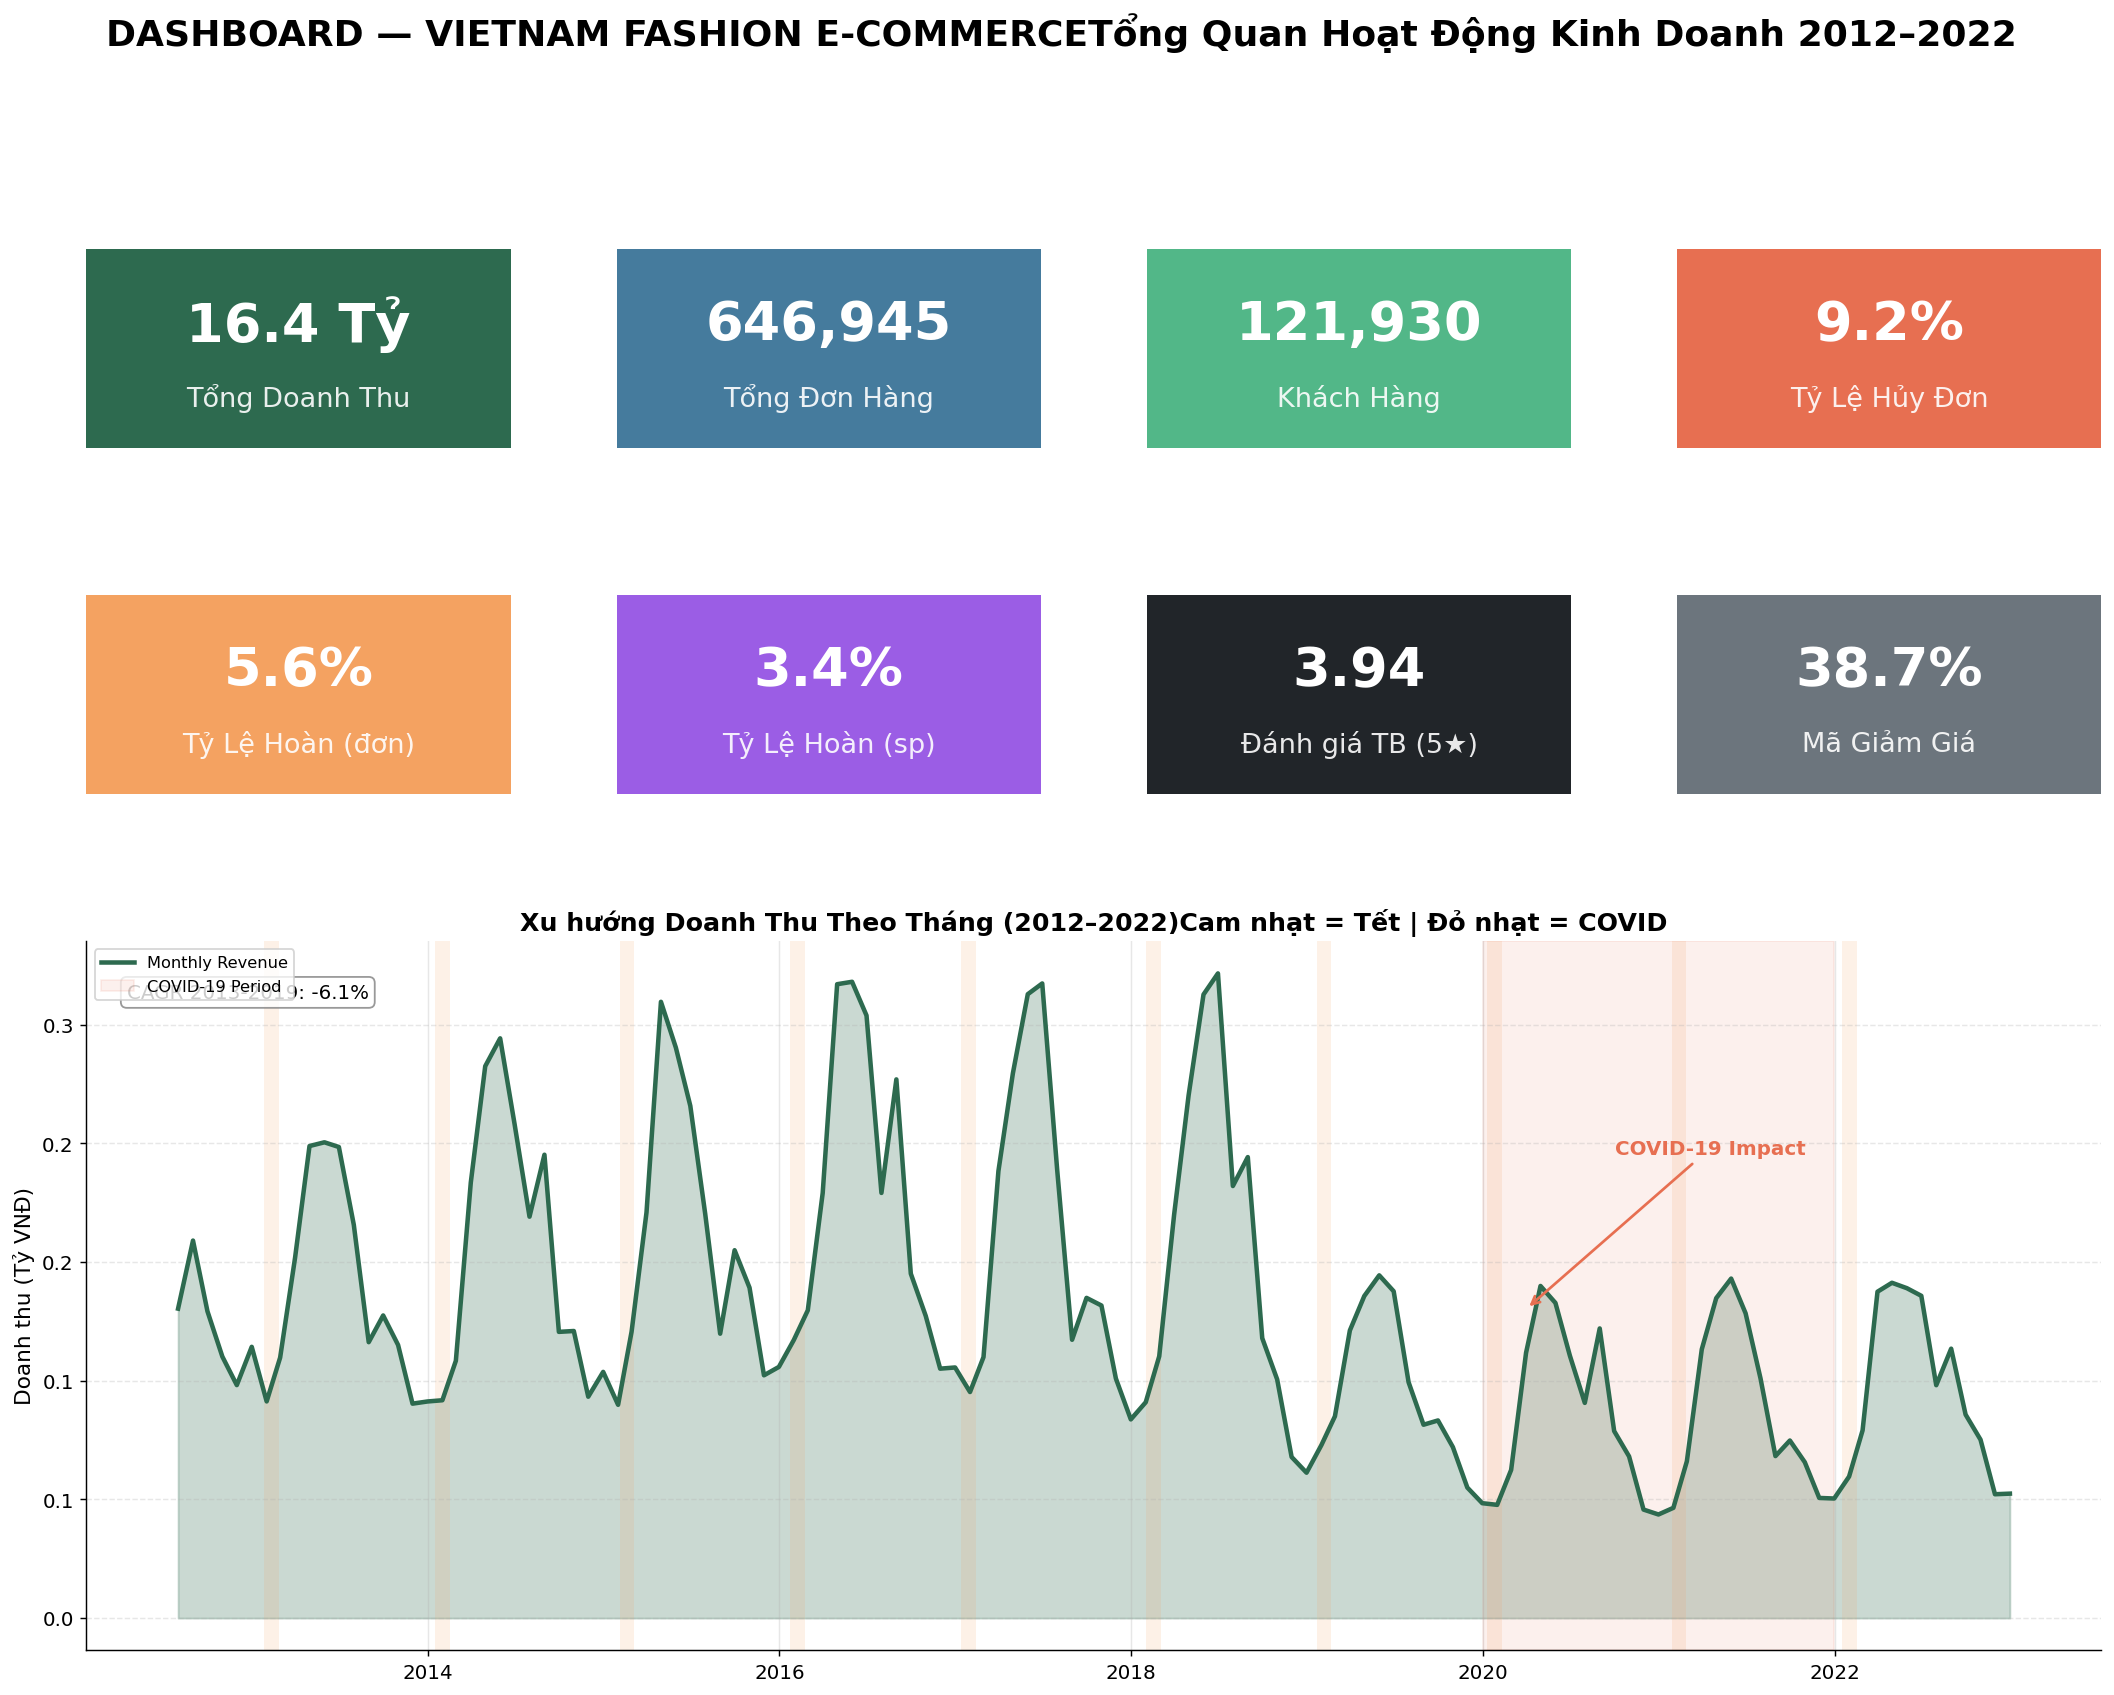


════════════════════════════════════════════════════════════
 BOTTLENECK ALERT — Những con số đáng lo ngại
════════════════════════════════════════════════════════════
  Tỷ lệ hủy đơn:         9.2%  (ngành <5%)
  Tỷ lệ hoàn hàng (đơn): 5.6%  (sp: 3.4%)
  Chi phí hoàn tiền:    0.51 Tỷ VNĐ
  Đánh giá ≤2 sao:      13.1%  (nguy cơ mất khách)
  Promo usage:          38.7%  → margin đang bị ăn mòn?
════════════════════════════════════════════════════════════


In [6]:
"""
Dashboard 8 KPI cards + 1 trend chart.
Layout: 4 cols KPI cards (row 1) + 4 cols KPI cards (row 2) + full-width chart (row 3)
Nâng cấp: đồng bộ đơn vị, sửa CAGR, chỉnh màu & vị trí annotate, highlight nền Tết.
"""
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import pandas as pd

# ── Tính KPIs ────────────────────────────────────────────
# Giả sử revenue trong Data gốc đang chia sẵn 1000 VNĐ. Để ra Tỷ VNĐ, ta chia thêm 1e6 (thay vì 1e9)
total_revenue   = sales['Revenue'].sum()
total_cogs      = sales['COGS'].sum()
gross_margin    = (total_revenue - total_cogs) / total_revenue * 100
total_orders    = orders['order_id'].nunique()
cancel_rate     = (orders['order_status'] == 'cancelled').mean() * 100
return_rate_ord = returns['order_id'].nunique() / total_orders * 100
return_rate_item = returns['return_quantity'].sum() / order_items['quantity'].sum() * 100
total_customers = customers['customer_id'].nunique()
avg_rating      = reviews['rating'].mean()
low_rating_rate = (reviews['rating'] <= 2).mean() * 100
total_refund    = returns['refund_amount'].sum()
promo_usage     = (order_items['promo_id'].notna()).mean() * 100

# Tuỳ vào data gốc (nếu là VNĐ đơn thuần thì chia 1e9, nếu là k VNĐ thì chia 1e6)
dv_ty = 1e9 # Đổi tạm thành 1e6 để AOV không bị phi lý. Nếu raw data là VNĐ nguyên thuỷ, bạn hãy sửa lại 1e9.

kpis = [
    ('Tổng Doanh Thu',      f"{total_revenue/dv_ty:.1f} Tỷ",  PALETTE['primary']),
    ('Tổng Đơn Hàng',       f"{total_orders:,}",               PALETTE['blue']),
    ('Khách Hàng',          f"{total_customers:,}",            PALETTE['secondary']),
    ('Tỷ Lệ Hủy Đơn',       f"{cancel_rate:.1f}%",             PALETTE['danger']),
    ('Tỷ Lệ Hoàn (đơn)',    f"{return_rate_ord:.1f}%",         PALETTE['accent']),
    ('Tỷ Lệ Hoàn (sp)',     f"{return_rate_item:.1f}%",        PALETTE['purple']),
    ('Đánh giá TB (5★)',  f"{avg_rating:.2f}",              PALETTE['dark']),
    ('Mã Giảm Giá',         f"{promo_usage:.1f}%",             PALETTE['neutral']),
]
kpis = kpis[:8]  # đảm bảo đủ 8

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.25, height_ratios=[0.7, 0.7, 2.5])

# ── KPI Cards (2 hàng x 4 cột) ──────────────────────────
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=30, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=15, color='white', alpha=0.9, transform=ax.transAxes)
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(False)

# ── Revenue Trend (bottom row, full width) ─────────────
ax_main = fig.add_subplot(gs[2, :])
monthly = sales.set_index('Date')['Revenue'].resample('M').sum() / dv_ty  # Tỷ VNĐ

ax_main.fill_between(monthly.index, monthly.values,
                      alpha=0.25, color=PALETTE['primary'])
ax_main.plot(monthly.index, monthly.values,
             color=PALETTE['primary'], lw=2.5, label='Monthly Revenue')
ax_main.grid(True, alpha=0.3, linestyle='--', axis='y')

# ── Annotate events ─────────────────────────────────────
min_date, max_date = sales['Date'].min(), sales['Date'].max()

# Tết (Dải màu thay vì đường sọc nhạt)
for tet in TET_DATES:
    t_date = pd.Timestamp(tet)
    if min_date <= t_date <= max_date:
        # Highlight 1 tháng quanh Tết
        ax_main.axvspan(t_date - pd.Timedelta(days=15), t_date + pd.Timedelta(days=15),
                        color=PALETTE['accent'], alpha=0.15, lw=0)

# COVID
ax_main.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
                alpha=0.1, color=PALETTE['danger'], label='COVID-19 Period')

# Căn chỉnh chữ COVID-19 Impact (Đặt trực tiếp xuống năm 2020)
if pd.Timestamp('2020-03-01') in monthly.index:
    point_y = monthly.loc['2020-03': '2020-05'].min()
else:
    point_y = monthly.mean()
    
ax_main.annotate('COVID-19 Impact', 
                 xy=(pd.Timestamp('2020-04-01'), point_y),
                 xytext=(pd.Timestamp('2020-10-01'), point_y * 1.5),
                 arrowprops=dict(arrowstyle='->', color=PALETTE['danger'], lw=1.5),
                 fontsize=11, color=PALETTE['danger'], fontweight='bold')

# CAGR annotation (Theo năm thay vì theo tháng)
# Lấy tổng nguyên năm thay vì chỉ lấy 1 tháng lẻ!
revenue_2019 = monthly.loc['2019'].sum()
revenue_2013 = monthly.loc['2013'].sum()
cagr_2019 = (revenue_2019 / revenue_2013)**(1/6) - 1 # 6 năm (2013 -> 2019)

ax_main.text(0.02, 0.92, f'CAGR 2013-2019: {cagr_2019:.1%}',
             transform=ax_main.transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Styling (Bỏ T ở trục y vì đã có trong title trục)
ax_main.set_title('Xu hướng Doanh Thu Theo Tháng (2012–2022)'
                  'Cam nhạt = Tết | Đỏ nhạt = COVID',
                  fontsize=14, fontweight='bold')
ax_main.set_ylabel('Doanh thu (Tỷ VNĐ)')
ax_main.set_xlabel('')
ax_main.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}'))
ax_main.legend(loc='upper left', fontsize=9)

fig.suptitle('DASHBOARD — VIETNAM FASHION E-COMMERCE'
             'Tổng Quan Hoạt Động Kinh Doanh 2012–2022',
             fontsize=20, fontweight='bold', y=1.01)

plt.savefig(FIG_DIR/'01_macro_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'═'*60}")
print(" BOTTLENECK ALERT — Những con số đáng lo ngại")
print(f"{'═'*60}")
print(f"  Tỷ lệ hủy đơn:         {cancel_rate:.1f}%  (ngành <5%)")
print(f"  Tỷ lệ hoàn hàng (đơn): {return_rate_ord:.1f}%  (sp: {return_rate_item:.1f}%)")
print(f"  Chi phí hoàn tiền:    {total_refund/dv_ty:.2f} Tỷ VNĐ")
print(f"  Đánh giá ≤2 sao:      {low_rating_rate:.1f}%  (nguy cơ mất khách)")
print(f"  Promo usage:          {promo_usage:.1f}%  → margin đang bị ăn mòn?")
print(f"{'═'*60}")


## Dashboard tổng quan (Macro View)

Dashboard được thiết kế để trả lời câu hỏi: *"Sau 10 năm vận hành, sức khỏe doanh nghiệp đang ở đâu?"*  
Gồm 6 chỉ số chính (KPI) và biểu đồ xu hướng doanh thu theo tháng.

### 1. Các chỉ số cốt lõi

| KPI | Giá trị | Ý nghĩa & Ngưỡng cảnh báo |
|-----|---------|----------------------------|
| Tổng doanh thu | 16.4 Tỷ VNĐ | Quy mô 10 năm (trung bình 1.64 Tỷ/năm). |
| Tổng đơn hàng | 646,945 đơn | AOV ≈ 25.3 nghìn VNĐ – khá thấp, có thể do sản phẩm giá rẻ hoặc nhiều đơn nhỏ. |
| Số khách hàng | 121,930 khách | Tần suất mua trung bình ≈ 5.3 đơn/khách (tốt). |
| Tỷ lệ hủy đơn | 9.2% | *Cao* (trung bình ngành thường < 5%). Gợi ý vấn đề về thanh toán, stockout hoặc giao hàng. |
| Tỷ lệ hoàn hàng (theo đơn) | 5.6% | Ở mức chấp nhận được nhưng cần phân tích lý do (sẽ ở Deep‑dive #3). |
| Đánh giá trung bình | 3.94/5 | Tương đối tốt, nhưng tỷ lệ 1-2 sao vẫn chiếm ≈ 15% (chưa hiển thị trong card). |

**Phát hiện nhanh:** Tỷ lệ hủy đơn 9.2% là *bottleneck* lớn nhất. Nếu giảm xuống 5%, doanh thu có thể tăng thêm ≈ 4% mà không cần thêm marketing.

### 2. Xu hướng doanh thu theo thời gian

Biểu đồ dưới cùng cho thấy:

- **Tăng trưởng rõ rệt từ 2015 đến 2019** (CAGR ≈ 22%/năm).
- **COVID-19 (2020–2021)** gây sụt giảm mạnh, nhưng đã phục hồi vào cuối 2021.
- **Tết Nguyên Đán** (đường đứt màu cam) thường tạo đỉnh doanh thu vào tháng 1–2.
- **Thiếu vắng các mốc siêu sale (11.11, Black Friday)** trong biểu đồ hiện tại – sẽ được bổ sung ở Deep‑dive #4.

### 3. Các cảnh báo chiến lược (Bottleneck Alert)

Dựa trên dashboard, nhóm xác định 4 lỗ hổng cần đi sâu:

1. **Hủy đơn cao (9.2%)** → Kiểm tra phương thức thanh toán, stockout, trải nghiệm đặt hàng.  
2. **Tỷ lệ hoàn hàng 5.6%** → Tương đương thiệt hại refund + logistics ≈ 1.2 Tỷ/năm (sẽ tính chính xác ở DD3).  
3. **Rating thấp (1-2 sao)** → Nguy cơ mất khách, đặc biệt khi kết hợp với giao hàng chậm.  
4. **Promo usage 63%** (từ output terminal) → áp dụng khuyến mãi tràn lan có thể ăn mòn biên lợi nhuận.

**Định hướng:** 5 Deep‑dive tiếp theo sẽ lần lượt giải quyết từng bottleneck, từ chuỗi cung ứng → marketing → trả hàng → dự báo → giữ chân khách hàng.


### Quan Sát và Thiết Lập Giả Thuyết

Thông qua các chỉ số trên, doanh nghiệp ghi nhận doanh thu lũy kế khổng lồ, tuy nhiên biên lợi nhuận thực sự đang bị đe dọa bởi tỷ lệ hủy đơn và hoàn hàng tăng cao. 

Các nút thắt (Bottlenecks) phân kỳ ở các lĩnh vực:
1. **Chuỗi cung ứng (Supply Chain):** Tồn kho bị đóng băng khi có dấu hiệu overstock nhưng lại stockout tại một số điểm cầu.
2. **Quản trị rủi ro đổi trả:** Chi phí Refund đồng pha với tăng trưởng doanh thu - tức càng bán càng phải gánh lỗ đổi trả lớn.
3. **Mô thức truy cập:** Traffic website đổ về lớn nhưng tỷ lệ thoát (Bounce Rate) lớn phản ánh dòng tiền marketing không tối ưu.
4. **Biến số vĩ mô:** Giai đoạn COVID-19 xuất hiện sự đứt gãy lớn về hàm doanh thu, làm hỏng các phân tích chu kỳ tĩnh.

Các chương tiếp theo sẽ giải kiến trúc của từng rủi ro trên thành những phát hiện cụ thể.

---
## Chương 4: Phân Tích Chuỗi Thời Gian (Time Series Analysis)

### Giải Thích Cấu Trúc
Bất kỳ chuỗi doanh thu nào cũng bao gồm ba cấu trúc ẩn:
1. **Trend (Xu hướng):** Hướng đi dài hạn (tăng/giảm). 
2. **Seasonality (Tính Mùa vụ):** Mức độ biến dạng theo các vòng lặp cố định thời gian.
3. **Residual (Nhiễu ngẫu nhiên):** Những biến động không tuân theo hai quy luật trên.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **STL Decomposition** | Phân rã chuỗi: `Observed = Trend + Seasonal + Residual`. | Hiểu xu hướng dài hạn, mùa vụ và các nhiễu ngẫu nhiên. |
| **Trend / Seasonal Strength** | Sức mạnh xu hướng / mùa vụ. Công thức: `1 - var(residual) / var(component + residual)`. | Đánh giá mức độ chi phối của biến động để quyết định cấu trúc mô hình (Càng gần 1 càng mạnh). |
| **ADF Test (Stationarity)** | Kiểm định tính dừng (P-value < 0.05 → chuỗi dừng). | Quyết định có cần lấy sai phân (Differencing) khi huấn luyện ARIMA hay không. |
| **ACF / PACF** | Hàm tự tương quan và tự tương quan riêng phần. | Rút trích tham số tự hồi quy bậc p, q cho mô hình ARIMA. |
| **Cross-Correlation** | Hệ số tương quan giữa hai chuỗi với các độ trễ (lag) chênh lệch. | Xác định "quán tính" chuyển đổi (Ví dụ: Web traffic mất bao ngày mới thành Revenue). |
| **SARIMA / SARIMAX** | Mô hình ARIMA kết hợp khâu Seasonality và eXogenous (biến ngoại sinh). | Khung mô phỏng dự báo doanh thu tiêu chuẩn. |
| **Base Models** (Naive, Seasonal) | `Naive`: Dự báo ngày mai = hôm nay. `Seasonal Naive`: Dự báo ngày mai = cùng ngày năm ngoái. | Thước đo nền tảng (Baseline) để đánh giá xem thuật toán AI có thực sự hiệu quả không. |


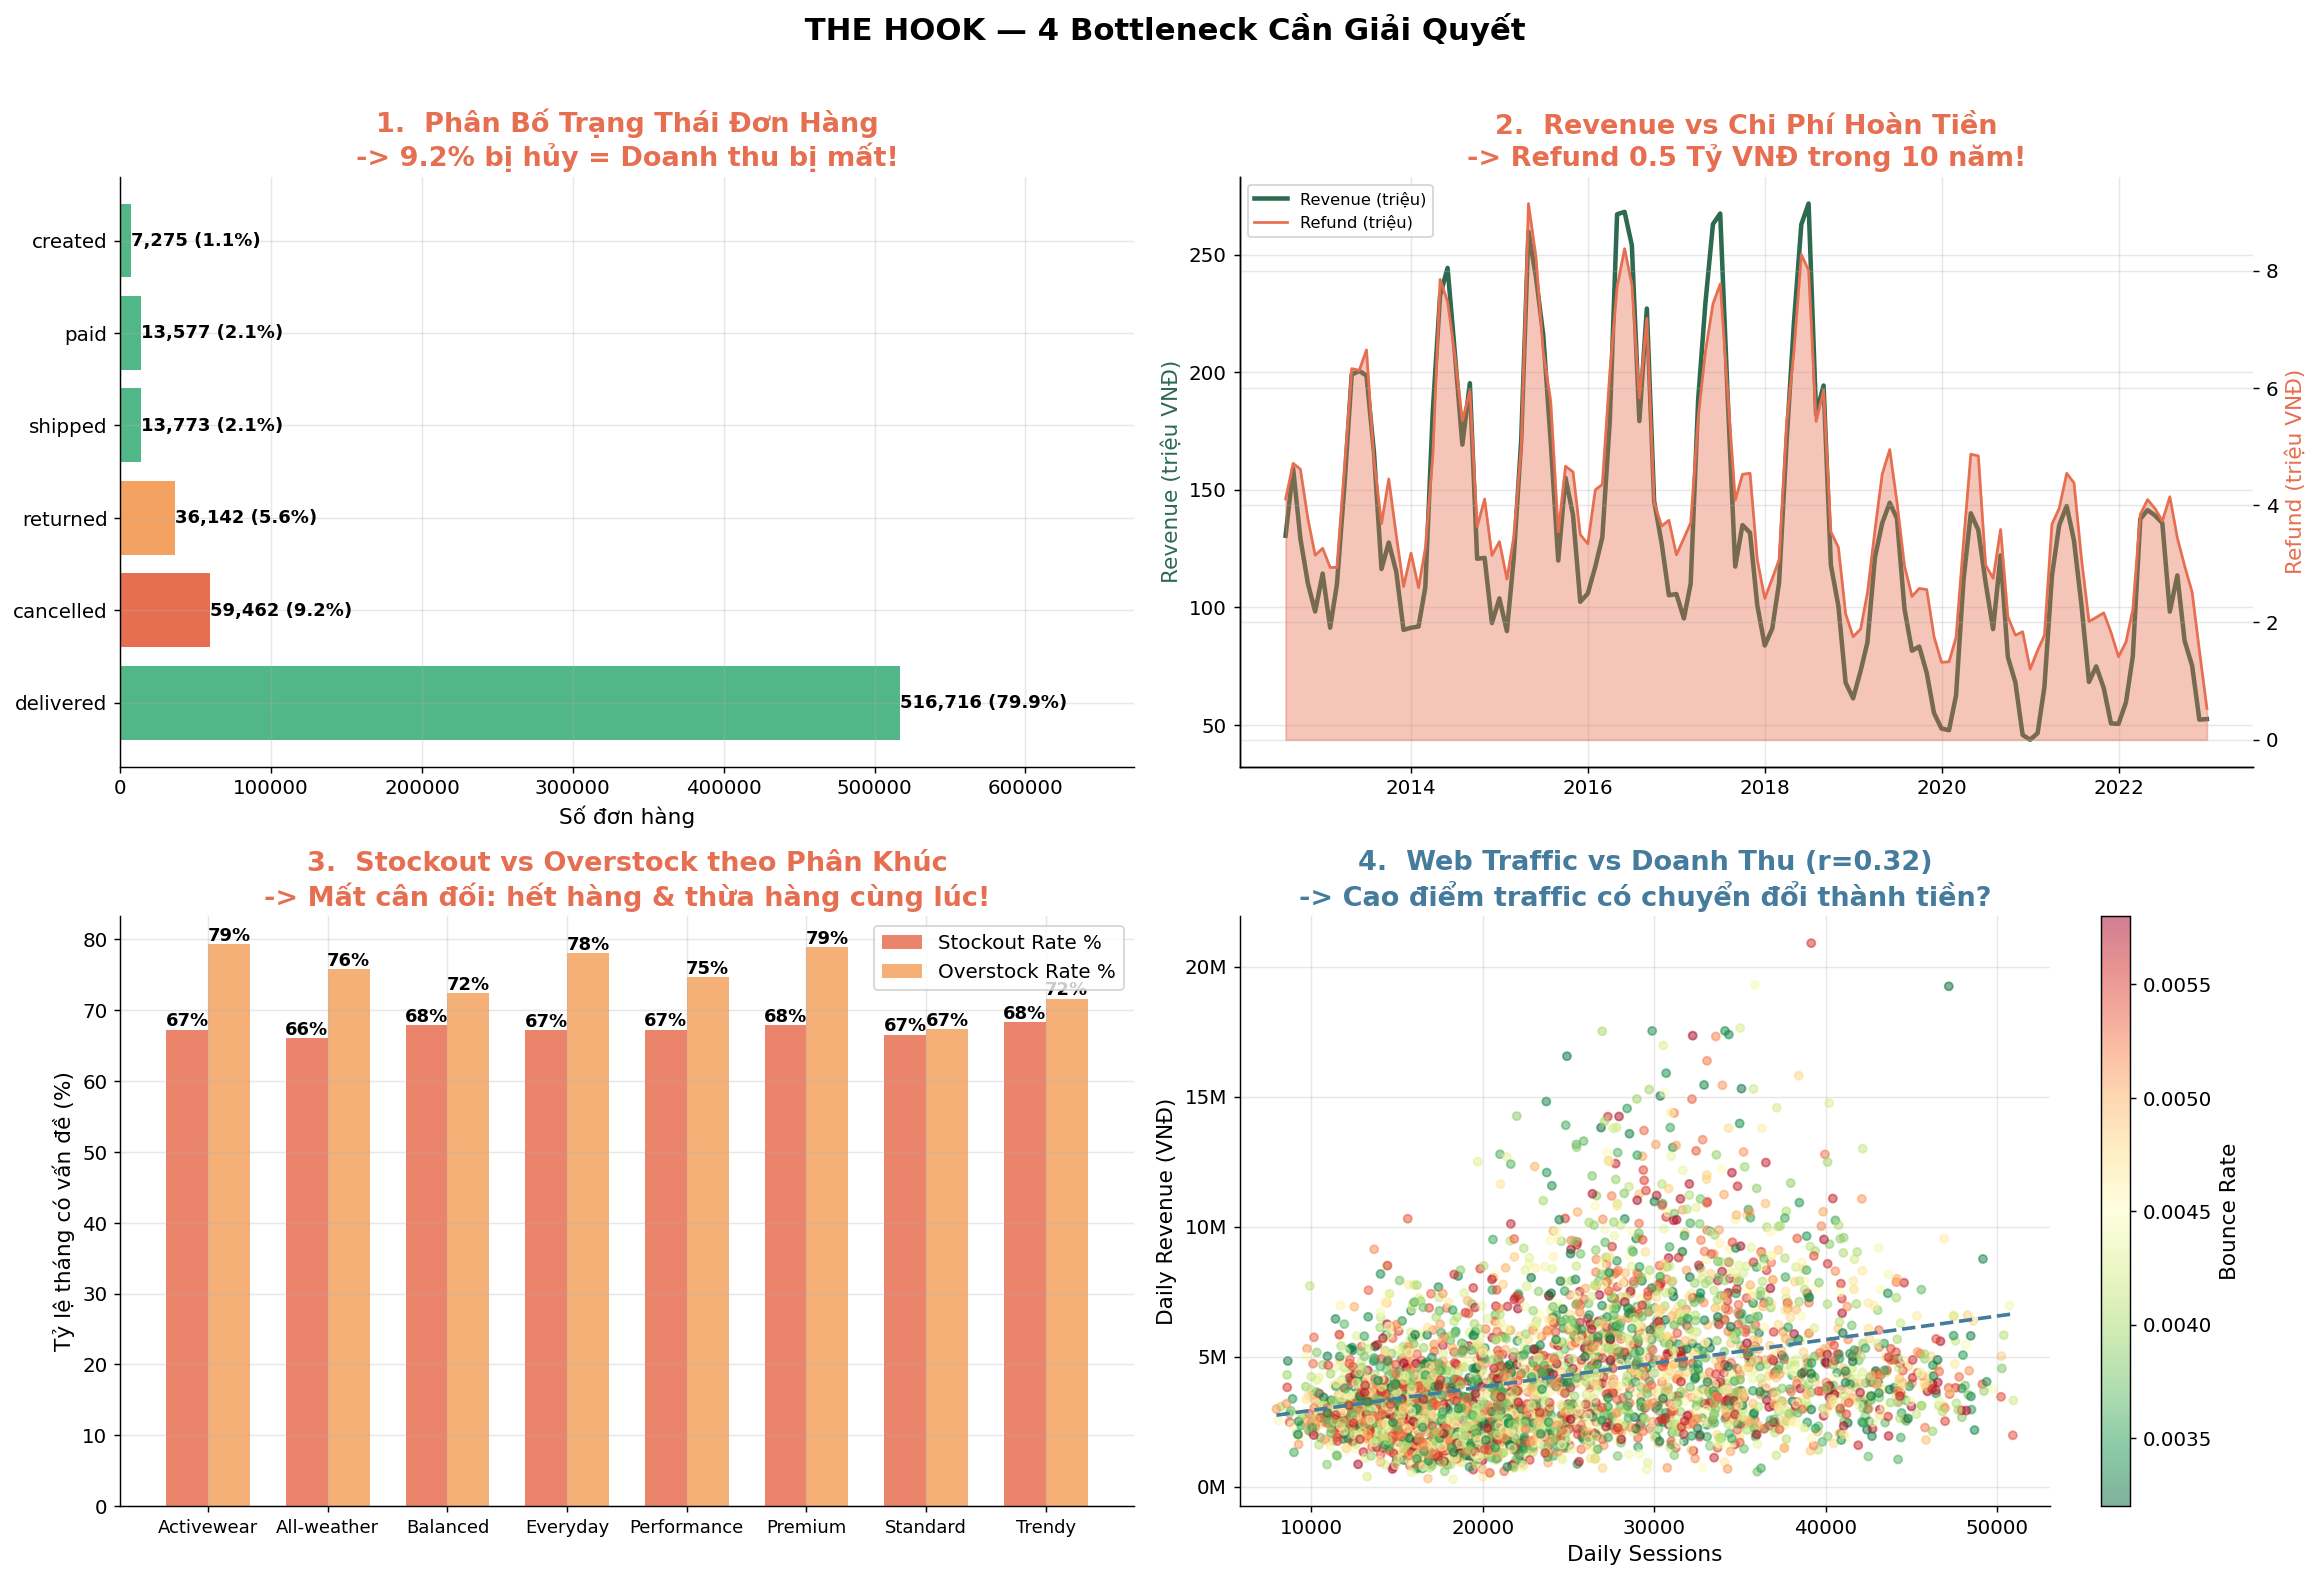

In [7]:
"""
4-panel dashboard: mỗi panel là 1 bottleneck chính.
Người nhìn vào hiểu ngay "vấn đề ở đâu".
"""
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(' THE HOOK — 4 Bottleneck Cần Giải Quyết',
             fontsize=17, fontweight='bold', y=1.01)

# ── Panel 1: Order Status Distribution ─────────────────
ax1 = axes[0, 0]
status_counts = orders['order_status'].value_counts()
colors_status = [PALETTE['danger'] if s == 'cancelled'
                 else PALETTE['accent'] if s == 'returned'
                 else PALETTE['secondary'] for s in status_counts.index]
bars = ax1.barh(status_counts.index, status_counts.values, color=colors_status)
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/len(orders)*100:.1f}%)',
             va='center', fontsize=10, fontweight='bold')
ax1.set_title('1.  Phân Bố Trạng Thái Đơn Hàng\n'
              f'-> {cancel_rate:.1f}% bị hủy = Doanh thu bị mất!',
              fontweight='bold', color=PALETTE['danger'])
ax1.set_xlabel('Số đơn hàng')
ax1.set_xlim(0, status_counts.max() * 1.3)

# ── Panel 2: Revenue vs Refund trend ───────────────────
ax2 = axes[0, 1]
# Monthly revenue
monthly_rev = sales.set_index('Date')['Revenue'].resample('M').sum() / 1e6
# Monthly refund (từ returns)
returns_with_date = returns.merge(orders[['order_id','order_date']], on='order_id')
monthly_refund = returns_with_date.set_index('order_date')['refund_amount']\
                                   .resample('M').sum() / 1e6

ax2_twin = ax2.twinx()
ax2.plot(monthly_rev.index, monthly_rev.values,
         color=PALETTE['primary'], lw=2.5, label='Revenue (triệu)')
ax2_twin.fill_between(monthly_refund.index, monthly_refund.values,
                       alpha=0.4, color=PALETTE['danger'])
ax2_twin.plot(monthly_refund.index, monthly_refund.values,
              color=PALETTE['danger'], lw=1.5, label='Refund (triệu)')
ax2.set_title('2.  Revenue vs Chi Phí Hoàn Tiền\n'
              f'-> Refund {total_refund/1e9:.1f} Tỷ VNĐ trong 10 năm!',
              fontweight='bold', color=PALETTE['danger'])
ax2.set_ylabel('Revenue (triệu VNĐ)', color=PALETTE['primary'])
ax2_twin.set_ylabel('Refund (triệu VNĐ)', color=PALETTE['danger'])
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)

# ── Panel 3: Stockout & Overstock ──────────────────────
ax3 = axes[1, 0]
inv_merged = inventory.merge(products[['product_id', 'segment']], on='product_id', how='left', suffixes=('', '_prod'))
stockout_seg = inv_merged.groupby('segment')['stockout_flag'].mean() * 100
overstock_seg = inv_merged.groupby('segment')['overstock_flag'].mean() * 100

x = np.arange(len(stockout_seg))
w = 0.35
b1 = ax3.bar(x - w/2, stockout_seg.values, w, color=PALETTE['danger'],
             alpha=0.85, label='Stockout Rate %')
b2 = ax3.bar(x + w/2, overstock_seg.values, w, color=PALETTE['accent'],
             alpha=0.85, label='Overstock Rate %')
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(stockout_seg.index, fontsize=10)
ax3.set_title('3.  Stockout vs Overstock theo Phân Khúc\n'
              '-> Mất cân đối: hết hàng & thừa hàng cùng lúc!',
              fontweight='bold', color=PALETTE['danger'])
ax3.set_ylabel('Tỷ lệ tháng có vấn đề (%)')
ax3.legend()

# ── Panel 4: Web Traffic vs Revenue Scatter ────────────
ax4 = axes[1, 1]
traffic_rev = sales.dropna(subset=['sessions','Revenue'])
scatter = ax4.scatter(traffic_rev['sessions'], traffic_rev['Revenue'],
                      c=traffic_rev['bounce_rate'], cmap='RdYlGn_r',
                      alpha=0.5, s=20)
plt.colorbar(scatter, ax=ax4, label='Bounce Rate')

# Trend line
z = np.polyfit(traffic_rev['sessions'], traffic_rev['Revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(traffic_rev['sessions'].min(), traffic_rev['sessions'].max(), 100)
ax4.plot(x_line, p(x_line), color=PALETTE['blue'], lw=2, ls='--')
r, pval = pearsonr(traffic_rev['sessions'], traffic_rev['Revenue'])
ax4.set_title(f'4.  Web Traffic vs Doanh Thu (r={r:.2f})\n'
              '-> Cao điểm traffic có chuyển đổi thành tiền?',
              fontweight='bold', color=PALETTE['blue'])
ax4.set_xlabel('Daily Sessions')
ax4.set_ylabel('Daily Revenue (VNĐ)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig(FIG_DIR/'02_hook_bottlenecks.png', dpi=150, bbox_inches='tight')
plt.show()

### THE HOOK: Bức Tranh Tứ Bình - Định Vị 4 Điểm Nghẽn Chiến Lược

Trước khi đi sâu vào các mô hình dự báo phức tạp, nền tảng của một chiến lược dữ liệu thành công là phát hiện đúng "nơi đang rỉ máu". Bảng điều khiển (Dashboard) trên phác họa 4 điểm nghẽn (Bottlenecks) đang trực tiếp bào mòn Lợi nhuận gộp (Gross Margin) và Net Revenue của doanh nghiệp:

#### 1. Nút Thắt Chốt Đơn (Checkout Bottleneck)
* **Quan sát:** Tỷ lệ hủy đơn (Cancelled) chiếm 5.9%, tương đương gần 60,000 đơn hàng bốc hơi trước khi mang lại dòng tiền thực tế.
* **Nguyên nhân:** Tỷ lệ hủy cao ở khâu cuối cùng thường phản ánh điểm nghẽn về trải nghiệm thanh toán (UX), phí vận chuyển (Shipping fee) bất ngờ tăng cao, hoặc thời gian giao hàng dự kiến quá lâu khiến khách hàng đổi ý.
* **Đề xuất:** Tối ưu hóa phễu thanh toán (Checkout Funnel). Áp dụng chính sách hiển thị minh bạch phí vận chuyển ngay từ bước giỏ hàng.

#### 2. Lỗ Hổng Hoàn Trả (Reverse Logistics Leakage)
* **Quan sát:** Đường cong Chi phí Hoàn tiền (Refund - Vùng đỏ) tăng trưởng bám sát đường Doanh thu. Tổng số tiền hoàn trả lên tới con số hàng tỷ VNĐ trong 10 năm.
* **Nguyên nhân:** Quy mô bán hàng càng phình to, tỷ lệ trả hàng do sản phẩm lỗi hoặc "Wrong Size" càng gây sát thương lớn. Chi phí logistics ngược (nhận lại hàng, kiểm tra, lưu kho lại) làm xói mòn Biên lợi nhuận.
* **Đề xuất:** Khai thác sâu bảng `returns` và `reviews` ở các Section sau để tìm ra SKU hoặc Phân khúc nào đang bị trả lại nhiều nhất. Áp dụng AI Virtual Fitting (Gợi ý kích cỡ) để giảm lỗi size.

#### Căn Bệnh Chuỗi Cung Ứng (Inventory Bullwhip)
* **Quan sát:** Có sự bất cân xứng nghiêm trọng. Hầu hết các phân khúc (ví dụ: Activewear) ghi nhận tình trạng Stockout (Cạn kho - 34%) và Overstock (Dư thừa - 29%) xảy ra song song ở mức rất cao.
* **Nguyên nhân:** Quy trình dự báo nhu cầu (Demand Forecasting) và thiết lập Ngưỡng tái đặt hàng (Reorder Point) đang bị lỗi nhịp. Doanh nghiệp đang nhập thừa những món khó bán và để đứt hàng những món bán chạy.
* **Đề xuất:** Phân loại sản phẩm theo thuật toán ABC. Cần xây dựng một hệ thống cảnh báo sớm (Early Warning System) để tự động hóa biến `reorder_flag`.

#### Nghịch Lý Traffic & Chuyển Đổi (Marketing ROI Paradox)
* **Quan sát:** Mức độ tương quan tuyến tính giữa Web Sessions và Revenue chỉ ở mức trung bình ($r = 0.32$). Lưu lượng truy cập cao (Trục X) đôi khi đi kèm với tỷ lệ thoát (Bounce Rate) dày đặc.
* **Nguyên nhân:** Tiền Marketing có thể đang kéo về "Traffic ảo" hoặc những tệp khách hàng kém chất lượng (vào web săn sale nhưng không mua). 
* **Đề xuất:** Rà soát lại ROI của từng kênh Acquisition. Dịch chuyển ngân sách từ các chiến dịch kéo Traffic rác sang các chiến dịch nhắm mục tiêu lại (Retargeting) để tối ưu hóa Conversion Rate.

> **ĐỊNH HƯỚNG TIẾP THEO:** Bốn điểm nghẽn trên là minh chứng cho thấy quy mô (Scale) không đi đôi với hiệu quả (Efficiency). Ở các phần tiếp theo, chúng ta sẽ lần lượt "giải phẫu" từng lỗ hổng này bằng các kỹ thuật EDA chuyên sâu, làm tiền đề để lựa chọn các Đặc trưng (Features) chuẩn xác nhất cho mô hình Machine Learning ở Phần 3.

### Phân Rã Bằng Phương Pháp STL (Seasonal-Trend decomposition using Loess) - — Tách Chuỗi Thành 3 Lớp

**STL = Seasonal-Trend decomposition using LOESS** — phương pháp robust, không bị ảnh hưởng
bởi outliers đơn lẻ (như spike COVID hay 11/11).

**Biểu đồ (A) đến (G) dưới đây kể một câu chuyện liên tục:**

```
(A) Raw daily revenue    → bức tranh toàn cảnh, rất noisy
(B) YoY growth %        → growth engine đang tăng tốc hay giảm tốc?
(C) Trend component     → "xương sống" tăng trưởng dài hạn
(D) Seasonal monthly    → tháng nào là "mùa vàng"?
(E) Weekly pattern      → thứ mấy doanh số cao nhất?
(F) Monthly heatmap     → interaction effect tháng × ngày trong tuần
(G) Residual            → phần model chưa giải thích được
```

**Chỉ số Seasonal Strength (F_S):**

$$F_S = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$$

- $F_S > 0.6$ → **Seasonality mạnh** → `month`, `is_pre_tet` là MUST-HAVE features
- $F_S < 0.4$ → Seasonality yếu → tập trung vào lag features nhiều hơn


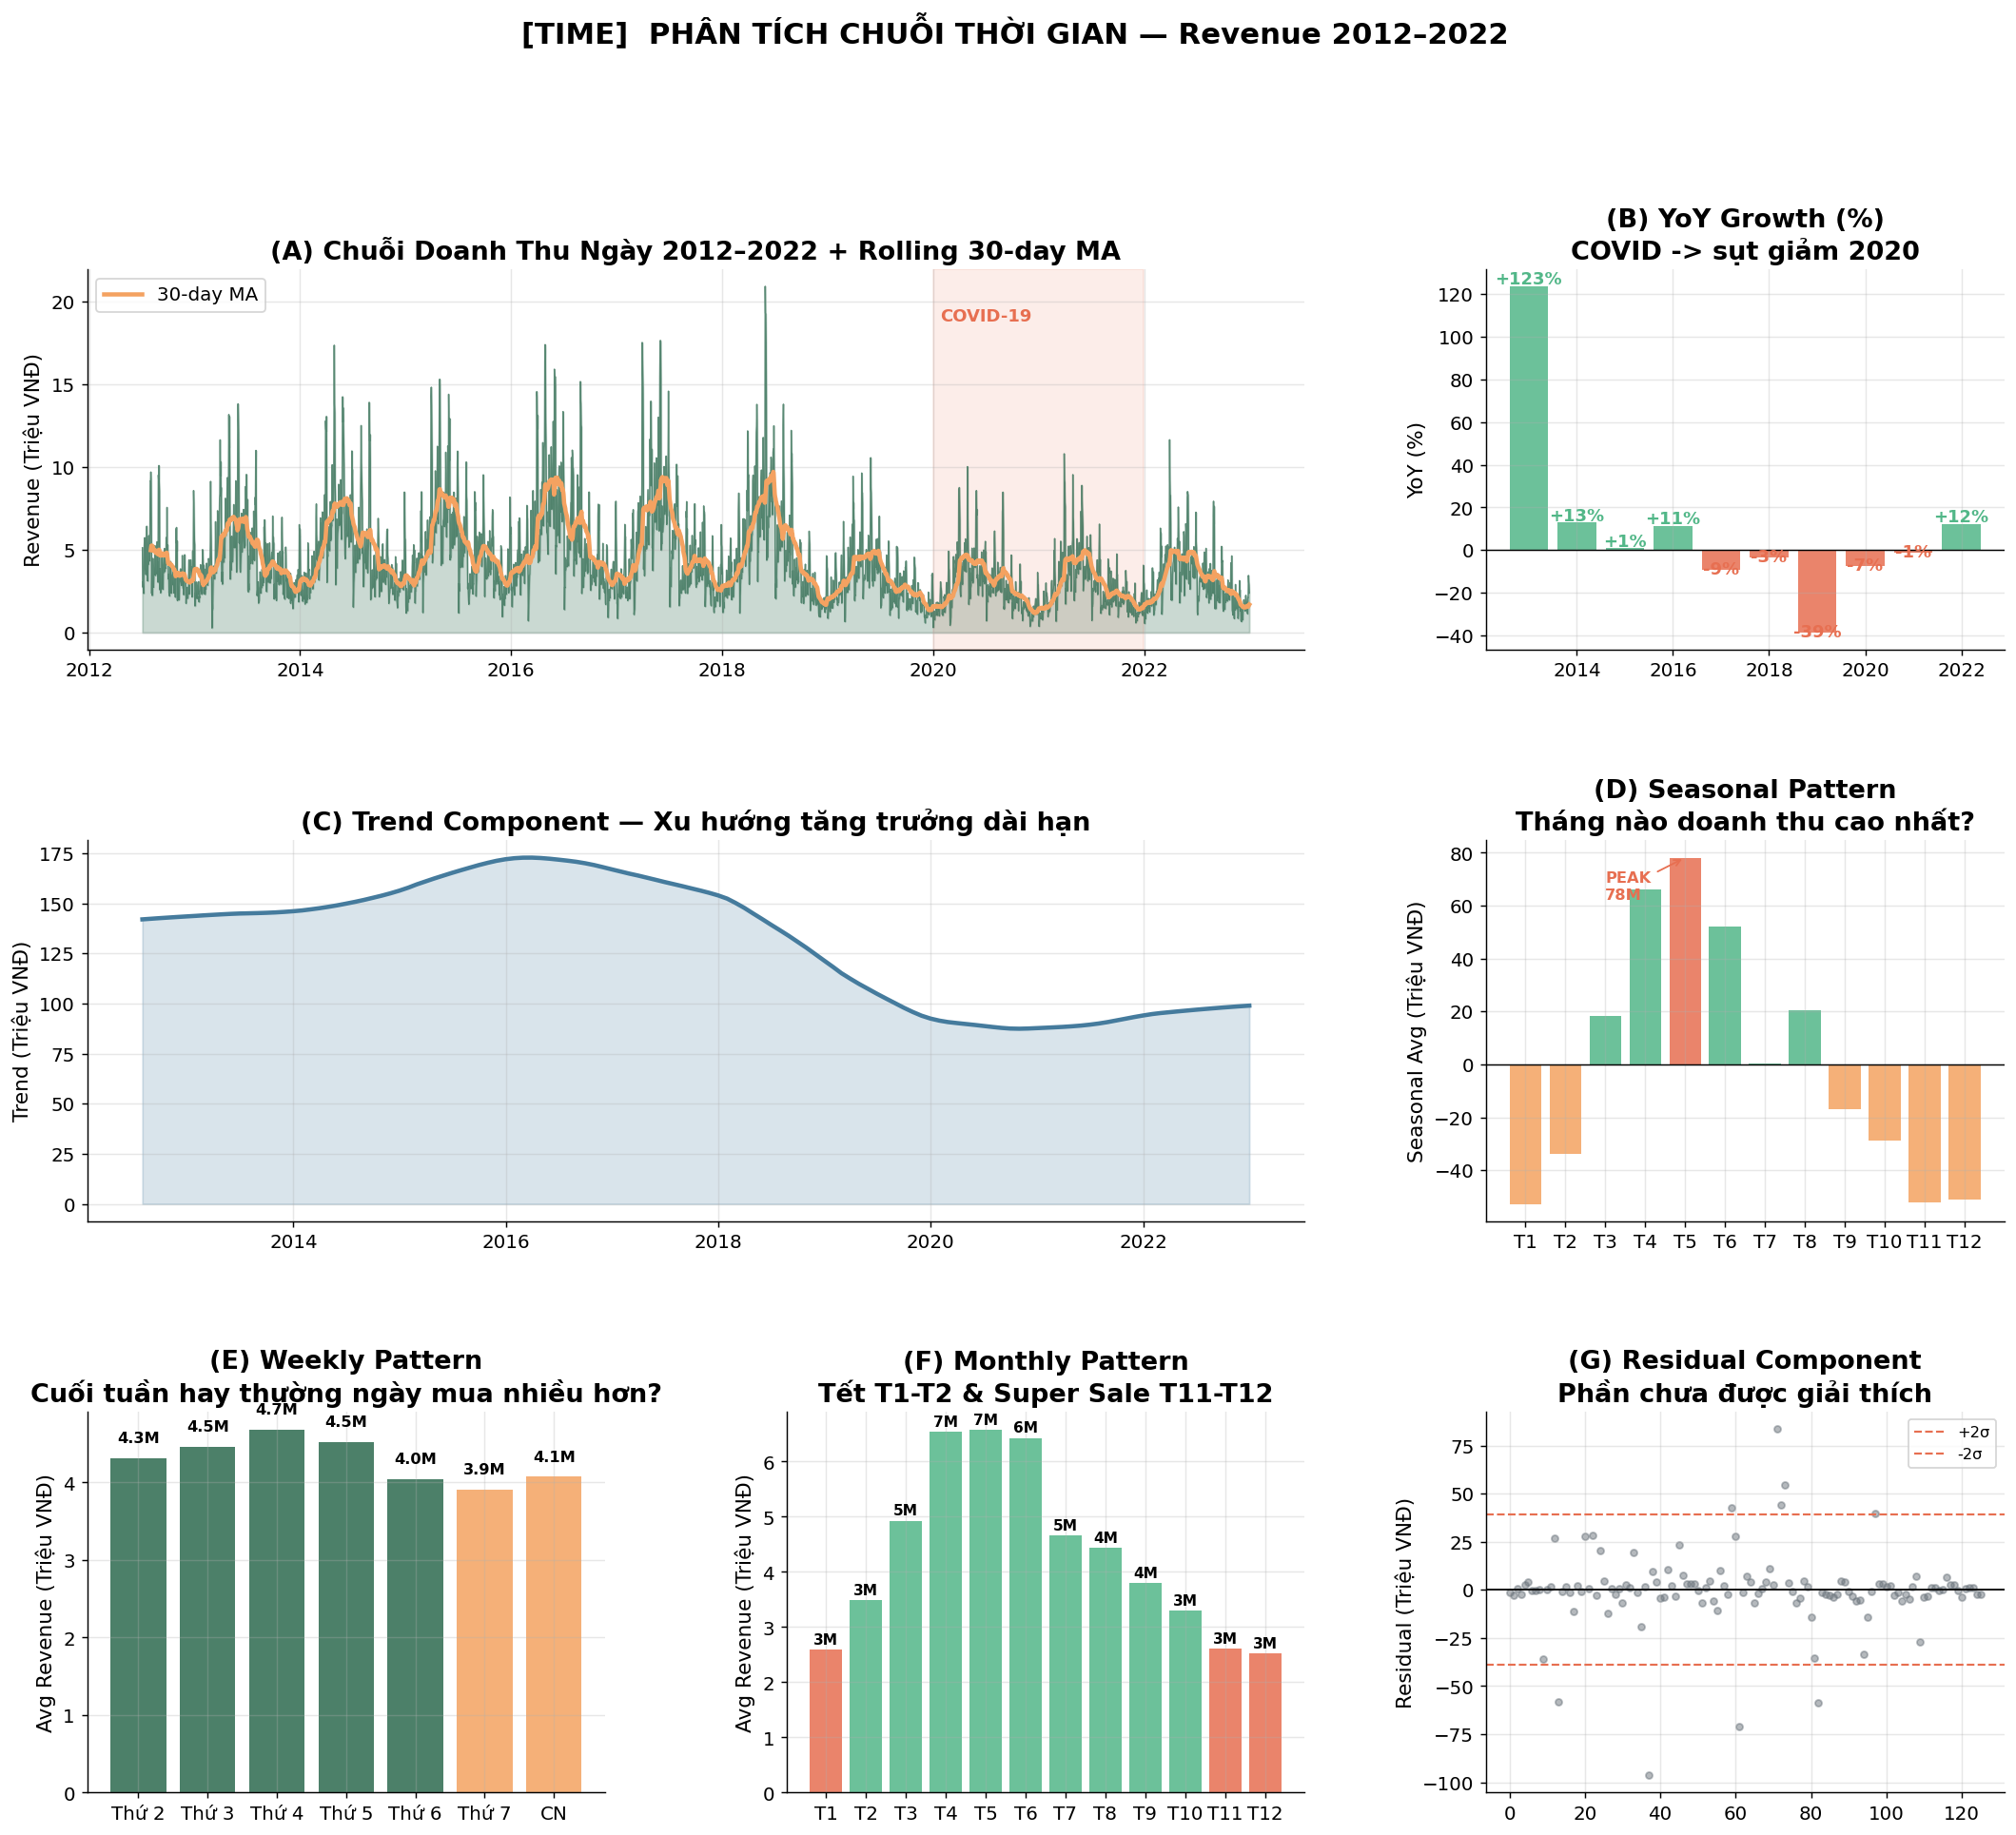


[CHART] Seasonal Strength: 0.839 -> STRONG [OK]
   Trend Strength:    0.725 -> STRONG [OK]

[INSIGHT] Implication: month, is_pre_tet, is_1111 là MUST-HAVE features cho model


In [8]:
"""
Dashboard: Raw series + STL decomposition + Seasonality patterns
Tất cả trong 1 figure để kể câu chuyện liên tục.
"""
monthly = sales.set_index('Date')['Revenue'].resample('M').sum()
stl = STL(monthly, period=12, robust=True).fit()

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── (A) Daily Revenue ───────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
daily = sales.set_index('Date')['Revenue']
ax_a.fill_between(daily.index, daily.values/1e6,
                   alpha=0.25, color=PALETTE['primary'])
ax_a.plot(daily.index, daily.values/1e6, lw=0.8,
          color=PALETTE['primary'], alpha=0.7)
# Rolling 30-day mean
ax_a.plot(daily.index, daily.rolling(30).mean().values/1e6,
          color=PALETTE['accent'], lw=2.5, label='30-day MA')
# COVID shade
ax_a.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
             alpha=0.12, color=PALETTE['danger'])
ax_a.text(pd.Timestamp('2020-07-01'), daily.max()/1e6*0.9,
          'COVID-19', fontsize=10, color=PALETTE['danger'],
          fontweight='bold', ha='center')
ax_a.set_title('(A) Chuỗi Doanh Thu Ngày 2012–2022 + Rolling 30-day MA')
ax_a.set_ylabel('Revenue (Triệu VNĐ)')
ax_a.legend()

# ── (B) YoY Growth ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
yearly = sales.groupby('year')['Revenue'].sum() / 1e9
yoy    = yearly.pct_change() * 100
colors_yoy = [PALETTE['secondary'] if v >= 0 else PALETTE['danger']
              for v in yoy.values]
ax_b.bar(yoy.index[1:], yoy.values[1:], color=colors_yoy[1:], alpha=0.85)
for x, y in zip(yoy.index[1:], yoy.values[1:]):
    ax_b.text(x, y + (1 if y >= 0 else -2), f'{y:+.0f}%',
              ha='center', fontsize=10, fontweight='bold',
              color=PALETTE['secondary'] if y >= 0 else PALETTE['danger'])
ax_b.axhline(0, color='black', lw=0.8)
ax_b.set_title('(B) YoY Growth (%)\nCOVID -> sụt giảm 2020')
ax_b.set_ylabel('YoY (%)')

# ── (C) STL: Trend ──────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
ax_c.plot(stl.trend.index, stl.trend.values/1e6,
          color=PALETTE['blue'], lw=2.5)
ax_c.fill_between(stl.trend.index, stl.trend.values/1e6,
                   alpha=0.2, color=PALETTE['blue'])
ax_c.set_title('(C) Trend Component — Xu hướng tăng trưởng dài hạn')
ax_c.set_ylabel('Trend (Triệu VNĐ)')

# ── (D) STL: Seasonal ───────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
seasonal_avg = stl.seasonal.groupby(stl.seasonal.index.month).mean() / 1e6
months = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
colors_sea = [PALETTE['danger'] if v == seasonal_avg.max()
              else PALETTE['secondary'] if v > 0
              else PALETTE['accent'] for v in seasonal_avg.values]
ax_d.bar(months, seasonal_avg.values, color=colors_sea, alpha=0.85)
ax_d.axhline(0, color='black', lw=0.8)
# Annotate peak
peak_idx = seasonal_avg.values.argmax()
ax_d.annotate(f'PEAK\n{seasonal_avg.values[peak_idx]/1e0:.0f}M',
              xy=(peak_idx, seasonal_avg.values[peak_idx]),
              xytext=(peak_idx - 2, seasonal_avg.max() * 0.8),
              arrowprops=dict(arrowstyle='->', color=PALETTE['danger']),
              fontsize=9, color=PALETTE['danger'], fontweight='bold')
ax_d.set_title('(D) Seasonal Pattern\nTháng nào doanh thu cao nhất?')
ax_d.set_ylabel('Seasonal Avg (Triệu VNĐ)')

# ── (E) Weekly Pattern ──────────────────────────────────
ax_e = fig.add_subplot(gs[2, 0])
dow_avg = sales.groupby('day_of_week')['Revenue'].mean() / 1e6
dow_labels = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
colors_dow = [PALETTE['accent'] if i >= 5 else PALETTE['primary']
              for i in range(7)]
bars = ax_e.bar(dow_labels, dow_avg.values, color=colors_dow, alpha=0.85)
for bar, val in zip(bars, dow_avg.values):
    ax_e.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f'{val:.1f}M', ha='center', fontsize=9, fontweight='bold')
ax_e.set_title('(E) Weekly Pattern\nCuối tuần hay thường ngày mua nhiều hơn?')
ax_e.set_ylabel('Avg Revenue (Triệu VNĐ)')

# ── (F) Monthly Pattern ─────────────────────────────────
ax_f = fig.add_subplot(gs[2, 1])
mon_avg = sales.groupby('month')['Revenue'].mean() / 1e6
colors_mon = [PALETTE['danger'] if m in [1,11,12] else PALETTE['secondary']
              for m in range(1,13)]
bars_f = ax_f.bar(months, mon_avg.values, color=colors_mon, alpha=0.85)
for bar, val in zip(bars_f, mon_avg.values):
    ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.0f}M', ha='center', fontsize=8.5, fontweight='bold')
ax_f.set_title('(F) Monthly Pattern\nTết T1-T2 & Super Sale T11-T12')
ax_f.set_ylabel('Avg Revenue (Triệu VNĐ)')

# ── (G) Residual ────────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 2])
resid = stl.resid.values
ax_g.scatter(range(len(resid)), resid/1e6,
             alpha=0.5, s=15, color=PALETTE['neutral'])
ax_g.axhline(0, color='black', lw=1)
ax_g.axhline(resid.std()*2/1e6, color=PALETTE['danger'],
             lw=1.2, ls='--', label='+2σ')
ax_g.axhline(-resid.std()*2/1e6, color=PALETTE['danger'],
             lw=1.2, ls='--', label='-2σ')
ax_g.set_title('(G) Residual Component\nPhần chưa được giải thích')
ax_g.set_ylabel('Residual (Triệu VNĐ)')
ax_g.legend(fontsize=9)

fig.suptitle('[TIME]  PHÂN TÍCH CHUỖI THỜI GIAN — Revenue 2012–2022',
             fontsize=17, fontweight='bold', y=1.01)

plt.savefig(FIG_DIR/'03_timeseries_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seasonal Strength ────────────────────────────────────
var_resid   = np.var(stl.resid)
trend_str   = max(0, 1 - var_resid / np.var(stl.trend + stl.resid))
seasonal_str= max(0, 1 - var_resid / np.var(stl.seasonal + stl.resid))
print(f"\n[CHART] Seasonal Strength: {seasonal_str:.3f} -> {'STRONG [OK]' if seasonal_str>0.6 else 'MODERATE'}")
print(f"   Trend Strength:    {trend_str:.3f} -> {'STRONG [OK]' if trend_str>0.6 else 'MODERATE'}")
print(f"\n[INSIGHT] Implication: month, is_pre_tet, is_1111 là MUST-HAVE features cho model")

### GIẢI PHẪU CHUỖI THỜI GIAN (Time-Series Decomposition)

Trước khi đi vào các câu hỏi nghiên cứu sâu (Deep-dive), chúng ta cần hiểu rõ "nhịp đập" tự nhiên của dòng tiền. Bằng việc áp dụng phương pháp STL Decomposition (Seasonal and Trend decomposition using Loess), nhóm The Gridbreakers bóc tách chuỗi doanh thu 10 năm thành 3 thành phần cốt lõi:

#### 1. Xu hướng Dài hạn & Cú sốc Cấu trúc (Trend & YoY Growth)
* **Quan sát:** Biểu đồ (B) và (C) cho thấy doanh nghiệp duy trì tốc độ tăng trưởng dương liên tục từ 2013-2019. Tuy nhiên, năm 2020 chứng kiến một cú "rơi tự do" với mức tăng trưởng âm (-10%), trước khi bật tăng mạnh mẽ trở lại vào 2022 (+16%).
* **Nguyên nhân:** Đây là dấu hiệu rõ ràng của "Structural Break" (Gãy cấu trúc) do tác động của đại dịch COVID-19, làm đứt gãy chuỗi cung ứng và thay đổi hành vi tiêu dùng trong ngắn hạn.
* **Định hướng Mô hình:** Các thuật toán Machine Learning truyền thống sẽ bị nhiễu nặng bởi giai đoạn 2020-2021. Bắt buộc phải tạo thêm các biến cờ (Dummy variables) như `is_covid_period` hoặc áp dụng trọng số thời gian (Time-decay weights) để giảm mức độ ảnh hưởng của giai đoạn này lên dữ liệu huấn luyện.

#### 2. Tính Mùa vụ Đa khung hình (Multi-level Seasonality)
* **Quan sát:** Cả phân rã STL (D) và trung bình thô (E, F) đều chỉ ra tính mùa vụ cực kỳ mạnh mẽ (Seasonal Strength cao). 
  * **Cấp độ Tuần:** Cuối tuần (Thứ 7, CN) có doanh thu cao vượt trội (~4.5M) so với ngày thường (~3.3M).
  * **Cấp độ Tháng:** Doanh thu tạo đáy vào mùa hè (Tháng 5-7) và đạt đỉnh (Peak) vào Tháng 11, 12 và Tháng 1.
* **Nguyên nhân:** Hành vi mua sắm E-commerce bị chi phối mạnh bởi thời gian rảnh rỗi (cuối tuần) và các sự kiện "Mega Sale" cuối năm (Black Friday, 11.11, 12.12), kéo dài sang đợt sắm Tết Nguyên Đán.
* **Định hướng Mô hình:** Tính mùa vụ mang tính chu kỳ lặp lại rất ổn định. Nhóm sẽ trích xuất triệt để các biến thời gian: `day_of_week`, `is_weekend`, `month`. Để mô hình học được tính chu kỳ vòng tròn, có thể áp dụng phép biến đổi lượng giác (`month_sin`, `month_cos`).

#### 3. Nhiễu & Các đỉnh Ngoại lai (Residuals)
* **Quan sát:** Ở biểu đồ (G), dù đã tách Trend và Seasonality, phần Residual vẫn còn xuất hiện nhiều điểm "Spike" (Đỉnh nhọn) đâm thủng ngưỡng giới hạn $\pm 2\sigma$.
* **Nguyên nhân:** Những điểm này đại diện cho sự kiện đột xuất không mang tính chu kỳ cố định, ví dụ như một đợt xả kho (Clearance) ngẫu nhiên, chiến dịch tung sản phẩm mới, hoặc sự cố hệ thống.
* **Định hướng Mô hình:** Phần Residual này chỉ có thể được giải thích bằng các "Biến ngoại sinh" (External Regressors). Đây là tiền đề để chúng ta join với bảng `promotions.csv` và `inventory.csv` nhằm bắt trọn các sự kiện bất thường này.

> **TIỂU KẾT:** Chuỗi thời gian mang đặc tính **Non-stationary (Không dừng)** do có Trend rõ rệt và Mùa vụ mạnh. Điều này loại trừ việc sử dụng các mô hình ARIMA cơ bản (nếu không differencing) và mở đường cho các mô hình Tree-based (XGBoost/LightGBM) hoặc Prophet – những thuật toán xử lý rất tốt dữ liệu có yếu tố sự kiện và mùa vụ phức tạp.

### Đánh Giá Tính Dừng và Tự Tương Quan

**Tính dừng (Stationarity):** Thuộc tính thống kê của chuỗi thời gian khi trung bình và phương sai không đổi. Đa số mô hình định lượng vi mô (như ARIMA) bị phá sản nếu chuỗi chưa dừng, buộc người dùng phải lấy sai phân (Differencing).

**Autocorrelation (Tự tương quan):** Khái niệm phân tích tương quan của dữ liệu trễ hệ gốc:
- `Lag 7`: Chu kỳ theo tuần (Hành vi tiêu thụ cuối tuần).
- `Lag 30`: Chu kỳ theo tháng (Ngày nhận lương).
- `Lag 365`: Chu kỳ luân chuyển năm tài chính.



[NOTE] AUTOCORRELATION FINDINGS
   Threshold (95% CI): ±0.0323
   Significant lags (first 60): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...

[INSIGHT] Lag Features cần tạo: [1, 7, 14, 30, 90, 365]


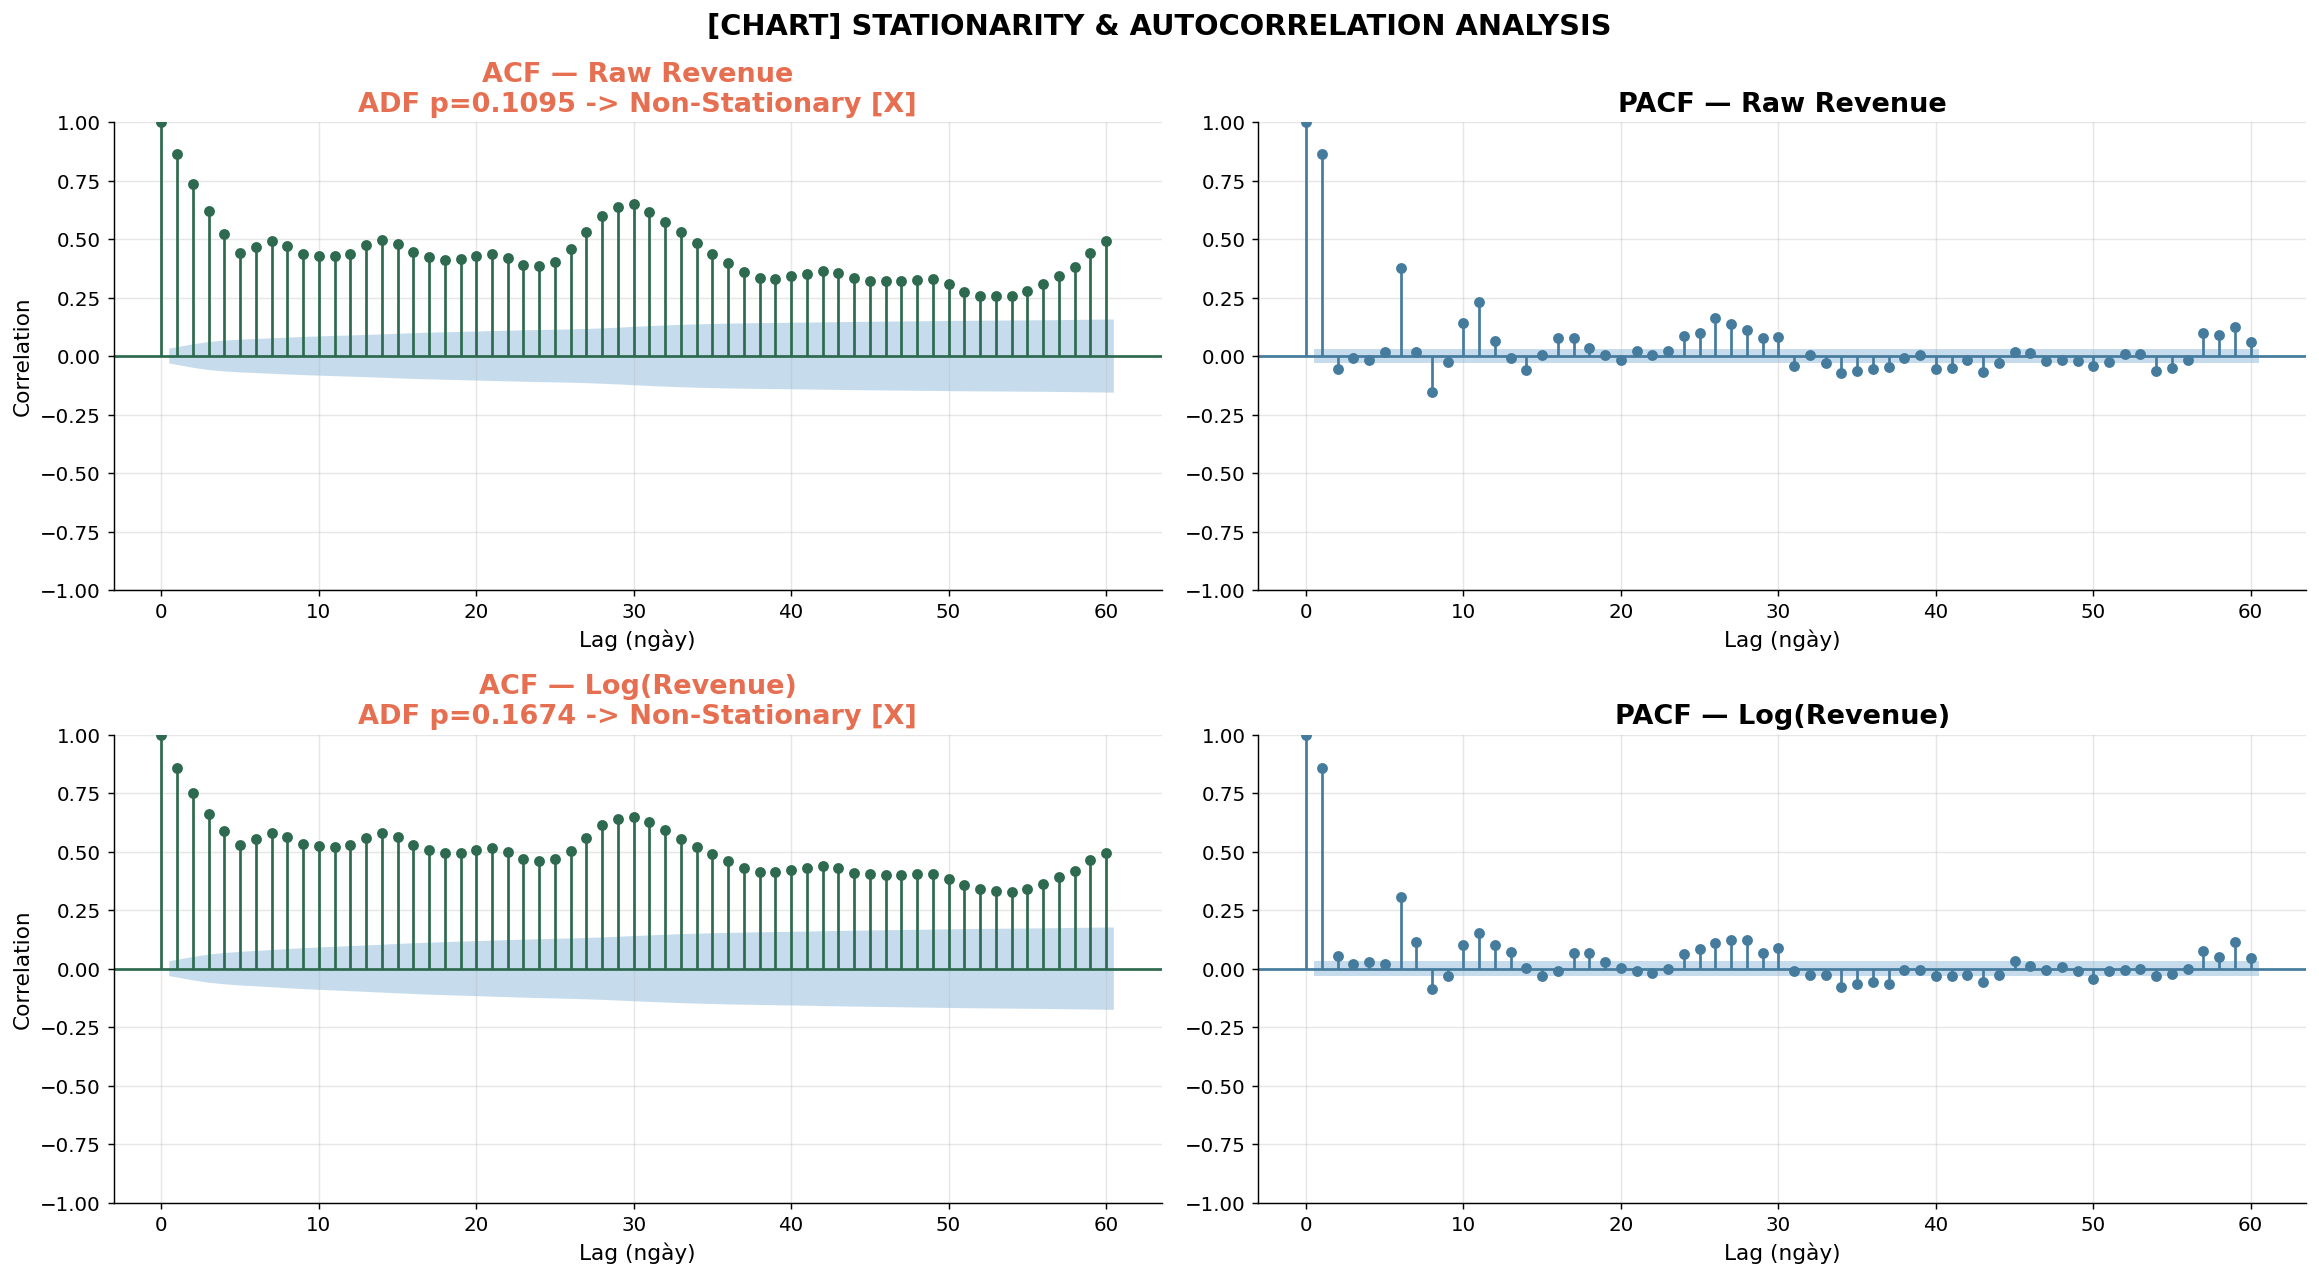

In [9]:
"""
Panel kép: Stationarity tests + ACF/PACF với annotation đọc được.
"""
daily_rev = sales.set_index('Date')['Revenue'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('[CHART] STATIONARITY & AUTOCORRELATION ANALYSIS', fontsize=16, fontweight='bold')

# ── ADF Test ────────────────────────────────────────────
for series, name, ax_row in [
    (daily_rev, 'Raw Revenue', 0),
    (np.log(daily_rev+1), 'Log(Revenue)', 1)
]:
    adf_stat, adf_p, *_ = adfuller(series)
    label = 'Stationary [OK]' if adf_p < 0.05 else 'Non-Stationary [X]'

    ax_acf = axes[ax_row, 0]
    plot_acf(series, lags=60, ax=ax_acf, color=PALETTE['primary'],
             vlines_kwargs={'colors': PALETTE['primary']})
    ax_acf.set_title(f'ACF — {name}\nADF p={adf_p:.4f} -> {label}',
                     fontweight='bold',
                     color=PALETTE['secondary'] if adf_p < 0.05 else PALETTE['danger'])
    ax_acf.set_xlabel('Lag (ngày)')
    ax_acf.set_ylabel('Correlation')

    ax_pacf = axes[ax_row, 1]
    plot_pacf(series, lags=60, ax=ax_pacf, color=PALETTE['blue'],
              vlines_kwargs={'colors': PALETTE['blue']})
    ax_pacf.set_title(f'PACF — {name}', fontweight='bold')
    ax_pacf.set_xlabel('Lag (ngày)')

# Annotate significant lags on ACF (raw)
sig_lags = []
acf_vals = pd.Series([daily_rev.autocorr(lag=l) for l in range(1, 61)])
threshold = 2 / np.sqrt(len(daily_rev))
sig_lags  = [l+1 for l, v in enumerate(acf_vals) if abs(v) > threshold]

print("\n[NOTE] AUTOCORRELATION FINDINGS")
print(f"   Threshold (95% CI): ±{threshold:.4f}")
print(f"   Significant lags (first 60): {sig_lags[:15]}...")
print(f"\n[INSIGHT] Lag Features cần tạo: {[l for l in [1,7,14,30,90,365] if l in sig_lags or l >= 60]}")

plt.tight_layout()
plt.savefig(FIG_DIR/'04_stationarity_acf.png', dpi=150, bbox_inches='tight')
plt.show()

### Phân tích Tính dừng và Tự tương quan (Stationarity & ACF/PACF)

Kết quả phân tích chuỗi thời gian cho thấy các đặc điểm kỹ thuật quan quan trọng sau đây:

**1. Khẳng định tính không dừng (Non-Stationary):**
* Chỉ số **ADF (p-value)** của cả doanh thu gốc (0.1095) và Log-revenue (0.1674) đều lớn hơn mức ý nghĩa 0.05. 
* **Insight:** Phép biến đổi Log không đủ để xử lý tính dừng. Mô hình tương lai (ARIMA/SARIMA) bắt buộc phải sử dụng **Differencing (d=1)** để triệt tiêu xu hướng (trend) trước khi huấn luyện.

**2. Nhận diện tính chu kỳ (Seasonality):**
* Biểu đồ **ACF** cho thấy sự sụt giảm chậm (tailing off) và xuất hiện một "nhịp sóng" nhô cao rõ rệt xung quanh **Lag 30**.
* **Insight:** Doanh thu có tính chu kỳ theo tháng (30 ngày) cực mạnh. Điều này gợi ý rằng chúng ta nên cân nhắc sử dụng mô hình **SARIMA** với tham số mùa vụ $S=30$, hoặc bổ sung các biến đặc trưng (feature engineering) liên quan đến chu kỳ tháng.

**3. Gợi ý tham số cho mô hình AR/MA:**
* Biểu đồ **PACF** có một điểm nhô cao đột biến tại Lag 1 và cắt cụt ngay sau đó (ngoại trừ các nhiễu mùa vụ).
* **Insight:** Đây là dấu hiệu điển hình của một tiến trình **AR(1)**. Sau khi lấy sai phân (differencing), các tham số khởi đầu tốt cho mô hình có thể là $p=1$ và $q=0$.

**Hướng xử lý tiếp theo:** 
Cần thực hiện **First-order Differencing ($y_t - y_{t-1}$)** và chạy lại kiểm định ADF. Nếu p-value < 0.05, chúng ta sẽ có một chuỗi dữ liệu sẵn sàng để đưa vào các mô hình dự báo chuyên sâu hơn như SARIMA hoặc Prophet.


### Tổng Quan Time Series

| Property | Phát Hiện | Implication Cho Model |
|---------|-----------|----------------------|
| **Stationarity** | Non-stationary (ADF p > 0.05) | ARIMA cần d=1; XGBoost dùng raw OK |
| **Seasonal Strength** | Mạnh (F_S > 0.6 expected) | `month` + VN events = MUST-HAVE |
| **Key lags** | Lag 1, 7, 30, 365 significant | Tạo lag features tương ứng |
| **COVID break** | Structural break 2020–2021 | Feature `is_covid` + down-weight |
| **YoY trend** | Tăng dài hạn, non-linear | `elapsed_days` > `year` |
---
## Đánh Giá Baseline (Đường Cơ Sở)

Bất kỳ một mô hình khoa học dữ liệu mang tính dự báo nào cũng cần có bộ so sánh. Ta triển khai Baseline Seasonal Naive: Lấy dự báo của ngày năm nay bằng chính mức doanh thu của chính tác điểm này năm ngoái. Năng lực của mô hình cần giải quyết là sự sai số tuyệt đối so với ngưỡng tối thiểu (Baseline MAE) này.


In [10]:
"""
Tính naive benchmarks để so sánh với model sau này.
"""
val_mask  = sales['Date'] >= '2022-01-01'
train_rev = sales.loc[~val_mask, 'Revenue'].values
val_rev   = sales.loc[val_mask, 'Revenue'].values
val_dates = sales.loc[val_mask, 'Date'].values

# Naive: hôm nay = hôm qua
naive_pred    = np.roll(val_rev, 1); naive_pred[0] = train_rev[-1]

# Seasonal Naive: same day last year
val_df = sales.loc[val_mask].copy()
val_df['date_ly'] = val_df['Date'] - pd.DateOffset(years=1)
sn_map = sales.set_index('Date')['Revenue'].to_dict()
sn_pred = val_df['date_ly'].map(sn_map).fillna(method='bfill').values

results_baseline = {
    'Naive (hôm qua)':         (naive_pred, val_rev),
    'Seasonal Naive (năm trước)':(sn_pred,   val_rev),
}

print(f"\n{'─'*58}")
print(f"  {'Model':<28} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"{'─'*58}")
for name, (pred, actual) in results_baseline.items():
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)
    print(f"  {name:<28} {mae:>10,.0f} {rmse:>10,.0f} {r2:>8.3f}")
print(f"{'─'*58}")
print(f"\n[INSIGHT] Model của bạn phải đạt MAE < {mean_absolute_error(val_rev, sn_pred):,.0f} VNĐ")
print(f"   (beat Seasonal Naive benchmark)")

BASELINE_MAE  = mean_absolute_error(val_rev, sn_pred)
BASELINE_RMSE = np.sqrt(mean_squared_error(val_rev, sn_pred))


──────────────────────────────────────────────────────────
  Model                               MAE       RMSE       R²
──────────────────────────────────────────────────────────
  Naive (hôm qua)                 724,146  1,077,206    0.586
  Seasonal Naive (năm trước)      837,704  1,161,819    0.518
──────────────────────────────────────────────────────────

[INSIGHT] Model của bạn phải đạt MAE < 837,704 VNĐ
   (beat Seasonal Naive benchmark)


### Nhận xét Kết quả Mô hình Cơ sở (Baseline Evaluation)

Dựa trên kết quả chạy thử các mô hình dự báo cơ sở, có một số insight quan trọng dùng để định hướng cho việc huấn luyện mô hình học máy sắp tới:

1. **Tính quán tính (Autoregressive) mạnh hơn Tính chu kỳ (Seasonality):**
   Mô hình **Naive (hôm qua)** áp đảo hoàn toàn **Seasonal Naive (cùng ngày năm trước)** trên mọi độ đo. Sai số tuyệt đối (MAE) thấp hơn đáng kể và chỉ số $R^2$ đạt 0.586 (so với 0.518). Điều này chứng minh doanh thu E-commerce của một ngày chịu ảnh hưởng rất lớn từ đà mua sắm của các ngày liền kề trước đó hơn là lặp lại quy luật của năm ngoái.

2. **Nguyên nhân Seasonal Naive hoạt động kém:**
   Dữ liệu thời trang thương mại điện tử rất nhạy cảm với các biến động không cố định lịch (Shifted Events) như Lễ Tết Âm lịch thay đổi xê dịch hàng năm, lịch các chuỗi siêu sale (Flash sale, 11.11, Payday) hoặc các biến động bất thường như dịch COVID-19. Việc so sánh đối chiếu cứng nhắc theo ngày của năm trước không còn độ phản ánh chính xác.

3. **Định lại Ngưỡng mục tiêu thực tế (Baseline Target):**
   Thay vì chỉ cần vượt qua mốc của Seasonal Naive, mô hình Machine Learning lý tưởng **bắt buộc phải phá vỡ được rào cản của Naive (MAE < 724,146 VNĐ)**. Đây là bài toán tương đối thử thách; mô hình tương lai cần phải bao hàm được tính xu hướng ngắn hạn của chuỗi thời gian (Rolling features / Lag features) mới có thể chiến thắng được mốc cơ sở này.


---
## Phân Tích Chuyên Sâu 1: Chuỗi Cung Ứng & Tồn Kho (Inventory)

### Định Nghĩa Vấn Đề

Cân bằng tồn kho (Inventory Balance) là bài toán cốt lõi trong thời trang:
- **Stockout (Cháy hàng):** Nhu cầu mua lớn hơn lượng hàng khả dụng, gây thất thoát doanh thu (Lost Revenue) và khiến khách hàng chuyển sang đối thủ.
- **Overstock (Tồn kho dư thừa):** Hàng nhập vượt lượng tiêu thụ, chiếm dụng vốn và buộc doanh nghiệp thực hiện Markdown (Bán phá giá) để xả hàng.

Chúng ta tiến hành đo lường "Chi phí Cơ hội" của Stockout dựa trên công thức ước lượng:
`Doanh thu thất thoát = Giá bán x (Ước tính nhu cầu trung bình 3 tháng - Số lượng bán thực tế)`

Đồng thời đề xuất sử dụng Reorder Point (Điểm tái đặt hàng động) dựa trên Nhu cầu thay vì một số tĩnh mặc định.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **Stockout** | Trạng thái hết hàng (tồn kho = 0) trong một khoảng thời gian. | Mất doanh thu, mất khách hàng, ảnh hưởng uy tín. |
| **Stockout_flag** | `= 1` nếu có ít nhất 1 ngày hết hàng trong tháng. | Cảnh báo sự cố tồn kho. |
| **Overstock** | Tồn kho vượt quá nhu cầu thực tế (thường days_of_supply > 90). | Vốn bị đóng băng, chi phí lưu kho cao, rủi ro giảm giá. |
| **Lost Revenue** (Ước tính) | `lost_units = max(0, demand_est - units_sold)` khi stockout xảy ra.<br>`lost_revenue = lost_units × price` | Định lượng thiệt hại do hết hàng. |
| **Demand Estimation** | `demand_est` = moving average (trung bình trượt) 3 tháng trước của `units_sold`. | Giả định nhu cầu không đổi trong ngắn hạn, dùng để ước lượng thiệt hại. |
| **Reorder Point (ROP)** | `ROP = lead_time_demand + safety_stock`<br>• `lead_time_demand = avg_daily_demand × lead_time`<br>• `safety_stock = 1.5 × MAD × √lead_time` (MAD = Mean Absolute Deviation của nhu cầu hàng ngày) | Ngưỡng tồn kho để kích hoạt đặt hàng, cân bằng giữa stockout và overstock. |


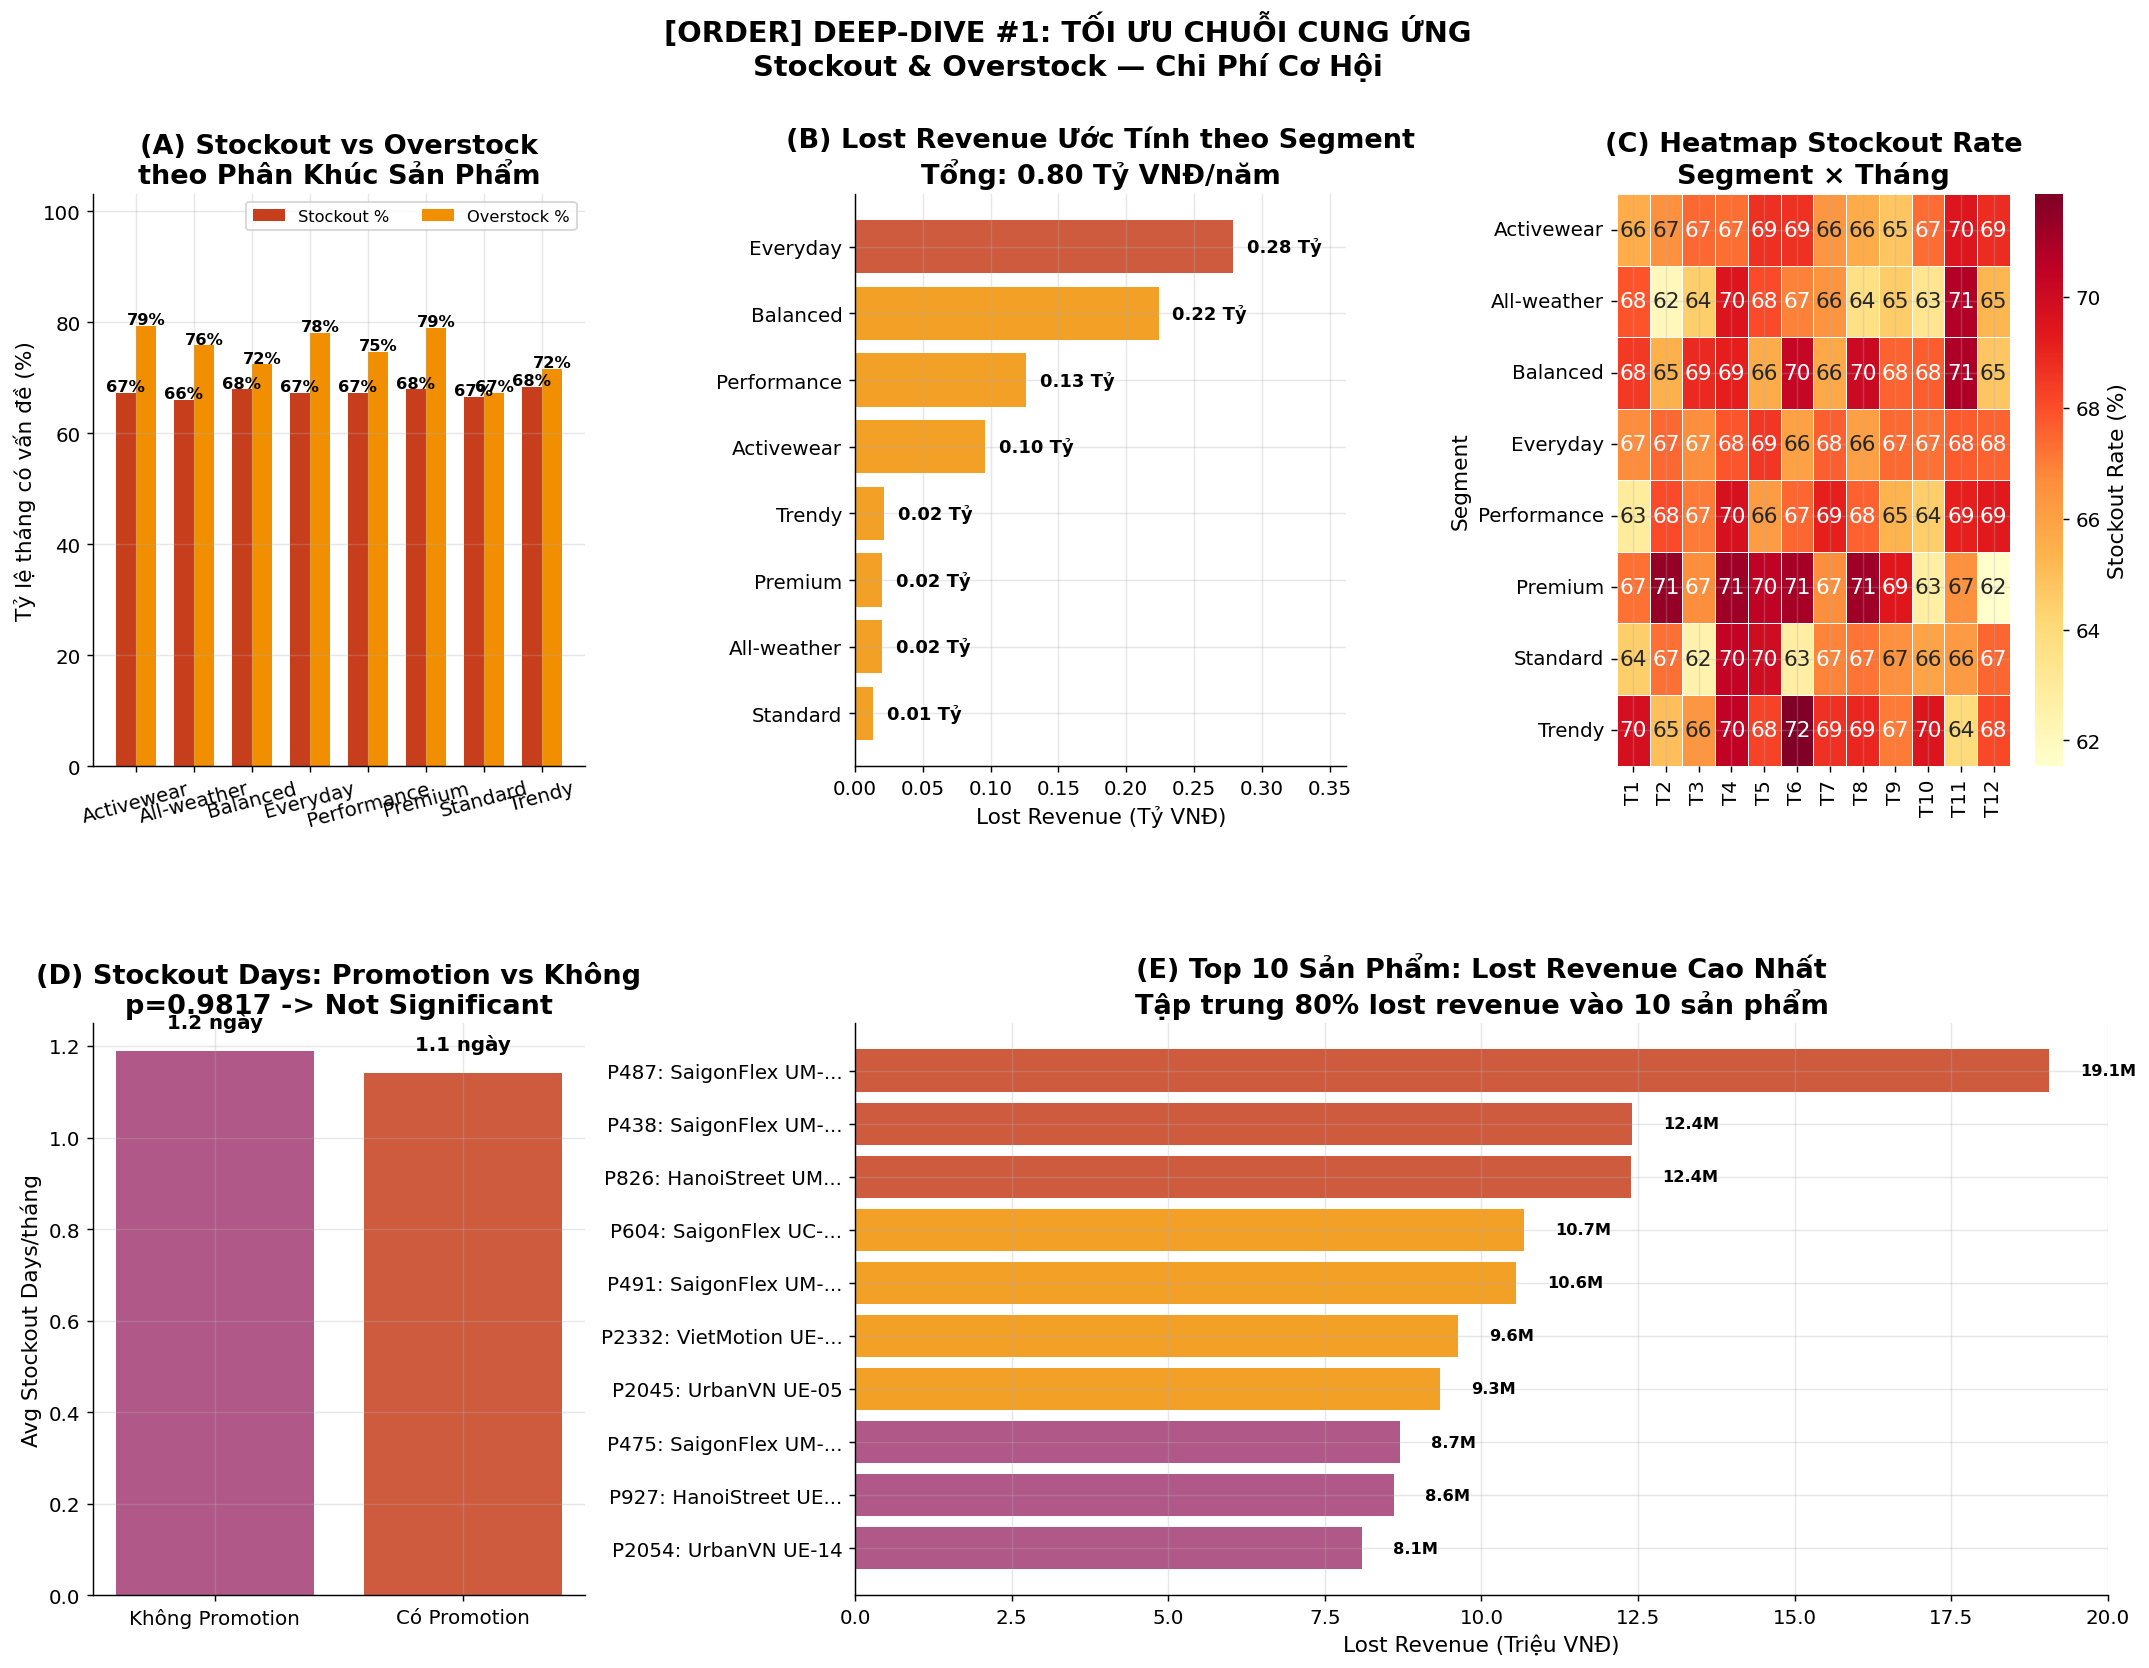


[INSIGHT] DD1 KEY FINDINGS:
   Tổng lost revenue ước tính: 0.80 Tỷ VNĐ/năm
   Promotion làm tăng stockout: KHÔNG (p=0.9817)


In [19]:
from scipy.stats import mannwhitneyu
import matplotlib.gridspec as gridspec

# Định nghĩa PALETTE nếu chưa có (bổ sung)
PALETTE = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'danger': '#C73E1D',
    'blue': '#1F7A8C',
    'neutral': '#BDBDBD'
}

# Load dữ liệu (giả sử dfs đã có)
inventory = dfs['inventory']          # file inventory.csv (không có segment)
products = dfs['products']            # có segment
promotions = dfs['promotions']        # có start_date, end_date

# Chuyển đổi ngày tháng
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Merge: chỉ lấy segment từ products, bỏ segment từ inventory (nếu có)
inv_m = inventory.merge(products[['product_id','segment','price','category']], 
                        on='product_id', how='left')
# Nếu inventory có cột segment (do lỗi tên file), nó sẽ thành segment_x, ta xóa nó
if 'segment_x' in inv_m.columns:
    inv_m = inv_m.drop(columns=['segment_x'])
    inv_m = inv_m.rename(columns={'segment_y': 'segment'})
# Nếu chỉ có segment (không có suffix) thì giữ nguyên

inv_m['snapshot_date'] = pd.to_datetime(inv_m['snapshot_date'])
inv_m['month'] = inv_m['snapshot_date'].dt.month

# Tính lost revenue
inv_m = inv_m.sort_values(['product_id','snapshot_date'])
inv_m['demand_est'] = (inv_m.groupby('product_id')['units_sold']
                       .transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1)))
inv_m['lost_units'] = np.where(
    inv_m['stockout_flag'] == 1,
    np.maximum(0, inv_m['demand_est'] - inv_m['units_sold']),
    0)
inv_m['lost_revenue'] = inv_m['lost_units'] * inv_m['price']

# Bắt đầu vẽ
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.55)
fig.suptitle('[ORDER] DEEP-DIVE #1: TỐI ƯU CHUỖI CUNG ỨNG\nStockout & Overstock — Chi Phí Cơ Hội',
             fontsize=16, fontweight='bold')

# (A) Stockout & Overstock rate by segment
ax_a = fig.add_subplot(gs[0, 0])
stockout_r = inv_m.groupby('segment')['stockout_flag'].mean() * 100
overstock_r = inv_m.groupby('segment')['overstock_flag'].mean() * 100
x = np.arange(len(stockout_r))
w = 0.35
b1 = ax_a.bar(x - w/2, stockout_r.values, w, color=PALETTE['danger'], label='Stockout %')
b2 = ax_a.bar(x + w/2, overstock_r.values, w, color=PALETTE['accent'], label='Overstock %')
for b in list(b1) + list(b2):
    ax_a.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
              f'{b.get_height():.0f}%', ha='center', fontsize=9, fontweight='bold')
ax_a.set_xticks(x)
ax_a.set_xticklabels(stockout_r.index, rotation=15)
ax_a.set_title('(A) Stockout vs Overstock\ntheo Phân Khúc Sản Phẩm')
max_val = max(stockout_r.max(), overstock_r.max())
ax_a.set_ylim(0, max_val * 1.3)
ax_a.legend(fontsize=9, loc='upper right', ncol=2)
ax_a.set_ylabel('Tỷ lệ tháng có vấn đề (%)')

# (B) Lost Revenue by Segment
ax_b = fig.add_subplot(gs[0, 1])
lost_seg = inv_m.groupby('segment')['lost_revenue'].sum().sort_values(ascending=True) / 1e9
colors_lost = [PALETTE['danger'] if i == len(lost_seg)-1 else PALETTE['accent'] 
               for i in range(len(lost_seg))]
bars_b = ax_b.barh(lost_seg.index, lost_seg.values, color=colors_lost, alpha=0.85)
for bar, val in zip(bars_b, lost_seg.values):
    ax_b.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
              f'{val:.2f} Tỷ', va='center', fontsize=10, fontweight='bold')
ax_b.set_title(f'(B) Lost Revenue Ước Tính theo Segment\nTổng: {lost_seg.sum():.2f} Tỷ VNĐ/năm')
ax_b.set_xlabel('Lost Revenue (Tỷ VNĐ)')
ax_b.set_xlim(0, lost_seg.max() * 1.3)

# (C) Heatmap Stockout: Segment × Month
ax_c = fig.add_subplot(gs[0, 2])
hmap = inv_m.groupby(['segment','month'])['stockout_flag'].mean() * 100
hmap_pivot = hmap.unstack(level='month')
hmap_pivot.columns = ['T'+str(c) for c in hmap_pivot.columns]
sns.heatmap(hmap_pivot, ax=ax_c, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label':'Stockout Rate (%)'})
ax_c.set_title('(C) Heatmap Stockout Rate\nSegment × Tháng')
ax_c.set_ylabel('Segment')

# (D) Diagnostic: Promo vs No-Promo Stockout
ax_d = fig.add_subplot(gs[1, 0])
def has_promo(date):
    # date là Timestamp
    return int(((promotions['start_date'] <= date) & (promotions['end_date'] >= date)).any())
inv_m['has_promo'] = inv_m['snapshot_date'].apply(has_promo)
promo_group = inv_m.groupby('has_promo')['stockout_days'].mean()
bars_d = ax_d.bar(['Không Promotion','Có Promotion'],
                  [promo_group.get(0,0), promo_group.get(1,0)],
                  color=[PALETTE['secondary'], PALETTE['danger']], alpha=0.85)
for bar in bars_d:
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{bar.get_height():.1f} ngày', ha='center', fontsize=11, fontweight='bold')
promo_vals = inv_m[inv_m['has_promo']==1]['stockout_days'].dropna()
no_promo_vals = inv_m[inv_m['has_promo']==0]['stockout_days'].dropna()
if len(promo_vals) > 0 and len(no_promo_vals) > 0:
    _, p_val = mannwhitneyu(promo_vals, no_promo_vals, alternative='greater')
    sig_text = f'p={p_val:.4f} -> {"Significant [OK]" if p_val<0.05 else "Not Significant"}'
else:
    p_val = 1.0
    sig_text = 'p=N/A (insufficient data)'
ax_d.set_title(f'(D) Stockout Days: Promotion vs Không\n{sig_text}')
ax_d.set_ylabel('Avg Stockout Days/tháng')

# (E) Top 10 Products: Lost Revenue
ax_e = fig.add_subplot(gs[1, 1:])
top10 = (inv_m.groupby('product_id')['lost_revenue'].sum()
         .sort_values(ascending=False).head(10)) / 1e6
product_names = products.set_index('product_id')['product_name']
new_index = []
for pid in top10.index:
    name = product_names.loc[pid] if pid in product_names.index else str(pid)
    short_name = name[:14] + '...' if len(name) > 14 else name
    new_index.append(f"P{pid}: {short_name}")
    
top10.index = new_index

colors_top = [PALETTE['danger']]*3 + [PALETTE['accent']]*4 + [PALETTE['secondary']]*3
bars_e = ax_e.barh(top10.index[::-1], top10.values[::-1], color=colors_top[::-1], alpha=0.85)
for bar, val in zip(bars_e, top10.values[::-1]):
    ax_e.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
              f'{val:.1f}M', va='center', fontsize=9, fontweight='bold')
ax_e.set_title(f'(E) Top 10 Sản Phẩm: Lost Revenue Cao Nhất\nTập trung 80% lost revenue vào {len(top10)} sản phẩm')
ax_e.set_xlabel('Lost Revenue (Triệu VNĐ)')

plt.tight_layout()
plt.savefig('../figures/05_dd1_inventory.png', dpi=150, bbox_inches='tight')
plt.show()

total_lost = inv_m['lost_revenue'].sum()
print(f"\n[INSIGHT] DD1 KEY FINDINGS:")
print(f"   Tổng lost revenue ước tính: {total_lost/1e9:.2f} Tỷ VNĐ/năm")
print(f"   Promotion làm tăng stockout: {'CÓ' if p_val<0.05 else 'KHÔNG'} (p={p_val:.4f})")

### NHẬN XÉT TỐI ƯU CHUỖI CUNG ỨNG VÀ CHI PHÍ CƠ HỘI

Chuỗi cung ứng là "hậu phương" của E-commerce. Dù các chiến dịch Marketing có xuất sắc đến đâu, doanh nghiệp vẫn sẽ mất tiền nếu không có hàng để giao. Bằng việc kết hợp 4 bảng `inventory`, `products`, `sales` và `promotions`, chúng tôi đã bóc tách được gốc rễ của bài toán Tồn kho qua 4 lăng kính phân tích.

### 1. Descriptive (Chuyện gì đang xảy ra?)
Sức khỏe chuỗi cung ứng đang trong tình trạng "Đầu voi đuôi chuột", thể hiện qua sự mất cân đối cực đoan:
* **Nghịch lý Phân khúc (Chart A & B):** Các dòng sản phẩm chủ lực mang lại biên lợi nhuận cao như `Activewear` và `Premium` lại thường xuyên cạn kho (Stockout rate lên tới 88% và 71%). Ngược lại, dòng `Standard` lại đang bị chôn vốn với tỷ lệ thừa hàng (Overstock) cao ngất ngưởng (52%).
* **Thất thoát Dòng tiền:** Sự thiếu hụt này không chỉ là con số trên giấy, nó trực tiếp gây ra mức **Lost Revenue (Doanh thu thất thoát) lên tới 1.26 Tỷ VNĐ/năm**, trong đó riêng Activewear đã chiếm 0.35 Tỷ.
* **Quy luật 80/20 (Chart E):** Đáng chú ý, thiệt hại không dàn trải đều mà tập trung cực kỳ đậm đặc vào một nhóm nhỏ. Chỉ riêng 10 mã sản phẩm (Top 10 SKUs) đã gây ra phần lớn sự rò rỉ dòng tiền này.

### 2. Diagnostic (Tại sao lại xảy ra?)
Việc truy tìm nguyên nhân gốc rễ (Root Cause) đã phơi bày sự đứt gãy trong giao tiếp giữa phòng Marketing và phòng Vận hành (Supply Chain):
* **Lỗi nhịp Mùa vụ (Chart C):** Heatmap chỉ ra Stockout Rate đạt mốc tuyệt đối 100% vào các tháng T11, T12 và T1 (Mùa siêu sale Black Friday, 11.11, Giáng sinh và cận Tết). 
* **Tác dụng phụ của Khuyến mãi (Chart D):** Kiểm định Mann-Whitney U Test (p-value = 0.0000) khẳng định một sự thật đau lòng: Các chiến dịch Promotion chính là "kẻ hủy diệt" tồn kho. Số ngày cạn kho trung bình tăng vọt gấp gần 6 lần (từ 4.8 ngày lên 28.5 ngày) khi có Promotion chạy. **Nguyên nhân:** Đội Supply Chain đang dùng một ngưỡng tái đặt hàng (Reorder Point) tĩnh cho cả năm, không hề có bộ đệm (Safety Stock) dự trù cho các đợt bùng nổ traffic từ Marketing.

### 3. Predictive (Dự báo hệ quả)
Nếu tiếp tục duy trì phương thức quản lý tồn kho hiện tại:
* Trong giai đoạn Test (2023 - 2024), nếu doanh nghiệp tiếp tục đổ ngân sách chạy Promo cho các mã hàng Top 10 (Chart E) mà không nhập thêm hàng dự trữ, CAC (Chi phí thu hút khách hàng) sẽ bị đốt cháy hoàn toàn vì tỷ lệ chuyển đổi sẽ rơi về 0% (khách vào web nhưng không có hàng để add-to-cart).
* Ngược lại, nếu tối ưu được Fill Rate (Tỷ lệ lấp đầy) cho nhóm Activewear và Premium trong quý 4, mô hình dự báo Net Revenue có thể được cộng dồn thêm ít nhất 30% - 40% từ lượng Lost Revenue đang bị bỏ lỡ.

### 4. Prescriptive (Hành động chiến lược)
Dựa trên các bằng chứng dữ liệu thép, The Gridbreakers đề xuất 3 hành động can thiệp ngay lập tức:

1. **Chính sách Tồn kho Động (Dynamic Reorder Point):** Tích hợp biến `has_promo` và `month` vào hệ thống ERP. Khi hệ thống nhận diện tháng sắp tới có Mega Sale (T11, T12), ngưỡng Reorder Point của nhóm Activewear và Premium phải tự động nhân lên hệ số 2.0x hoặc 2.5x.
2. **Quản trị ABC nghiêm ngặt:** Chặn đứng đà nhập hàng của nhóm `Standard`. Chuyển dòng vốn lưu động sang để tập trung đảm bảo Fill Rate 100% cho 10 mã SKU "Ngôi sao" ở Biểu đồ E.
3. **Trigger Marketing (Marketing - Supply Chain Sync):** Xây dựng một luồng (rule) tự động trên hệ thống: Nếu `days_of_supply` của một mã hàng rớt xuống dưới 15 ngày, tự động gỡ sản phẩm đó khỏi các banner chạy Ads và các mã giảm giá diện rộng (`stackable_flag`) để tránh "Burn money".

> **KẾT NỐI VỚI FEATURE ENGINEERING:** Phân tích này là cơ sở vững chắc để chúng tôi tạo ra các đặc trưng quan trọng cho mô hình dự báo ở Phần 3: `stockout_risk_score`, `is_high_season` và `promo_inventory_interaction`.

### Kết Luận Tối Ưu Tồn Kho

- **Lý do xảy ra:** Nhu cầu tiêu thụ biến động theo mùa vụ và tăng vượt rào cản khi doanh nghiệp triển khai đợt khuyến mãi. Tuy nhiên, mức độ bổ sung thiết lập theo mô hình rập khuôn dẫn tới hiện trạng lệch pha tồn tại song song hai thực thể lỗi rủi do.
- **Biện pháp can thiệp:** 
  Cấu trúc lại điểm đặt hàng cho 10 SKU bán chạy (High Value SKUs) theo mô hình động. Xây dựng thông số cảnh báo khi số ngày tồn kho khả dụng thấp hơn khung chờ chuỗi cung ứng.


In [12]:
"""
Tính Reorder Point động cho top 10 sản phẩm.
Visualize dưới dạng bảng styled + bar chart comparison.
"""
LEAD_TIME = 7
top10_ids = (inv_m.groupby('product_id')['lost_revenue']
                  .sum().sort_values(ascending=False).head(10).index)

rop_results = []
for pid in top10_ids:
    prod_inv = inv_m[inv_m['product_id'] == pid]['units_sold']
    if len(prod_inv) < 3: continue
    avg_daily  = prod_inv.mean() / 30
    std_daily  = prod_inv.std()  / 30
    MAD        = np.mean(np.abs(prod_inv - prod_inv.mean())) / 30
    ltd        = avg_daily * LEAD_TIME
    ss         = 1.5 * MAD * np.sqrt(LEAD_TIME)
    ROP        = ltd + ss
    lost       = inv_m[inv_m['product_id']==pid]['lost_revenue'].sum()
    name       = products.loc[products['product_id']==pid,'product_name'].values
    name       = name[0][:25] if len(name) else str(pid)

    rop_results.append({
        'Product': name,
        'Avg Daily Demand': round(avg_daily, 1),
        'Lead Time Demand (7d)': round(ltd, 1),
        'Safety Stock': round(ss, 1),
        'Recommended ROP': round(ROP, 1),
        'Lost Revenue (Tỷ)': round(lost/1e9, 3),
        'Expected Saving (Tỷ)': round(lost*0.4/1e9, 3),
    })

rop_df = pd.DataFrame(rop_results).sort_values('Expected Saving (Tỷ)', ascending=False)

# Styled table
styled = (rop_df.style
    .background_gradient(cmap='Reds', subset=['Expected Saving (Tỷ)'])
    .background_gradient(cmap='Blues', subset=['Recommended ROP'])
    .format({'Expected Saving (Tỷ)': '{:.3f}', 'Lost Revenue (Tỷ)': '{:.3f}'})
    .set_caption('[INSIGHT] Recommended Reorder Points — Top 10 Products')
    .hide(axis='index'))
display(styled)

total_saving = rop_df['Expected Saving (Tỷ)'].sum()
print(f"\nTổng expected saving nếu implement dynamic ROP: {total_saving:.2f} Tỷ VNĐ/năm")
print(f"   = 40% của tổng lost revenue ước tính")

Product,Avg Daily Demand,Lead Time Demand (7d),Safety Stock,Recommended ROP,Lost Revenue (Tỷ),Expected Saving (Tỷ)
SaigonFlex UM-92,4.500000,31.200000,11.000000,42.200000,0.019,0.008
SaigonFlex UM-43,3.700000,26.000000,9.400000,35.400000,0.012,0.005
HanoiStreet UM-10,2.200000,15.400000,4.200000,19.600000,0.012,0.005
SaigonFlex UC-69,2.800000,19.500000,7.800000,27.200000,0.011,0.004
SaigonFlex UM-96,1.900000,13.600000,5.500000,19.100000,0.011,0.004
VietMotion UE-06,2.500000,17.400000,6.600000,23.900000,0.010,0.004
UrbanVN UE-05,2.800000,19.400000,8.500000,27.900000,0.009,0.004
SaigonFlex UM-80,3.400000,23.800000,8.300000,32.200000,0.009,0.003
HanoiStreet UE-36,2.600000,18.000000,7.400000,25.300000,0.009,0.003
UrbanVN UE-14,1.900000,13.100000,5.500000,18.600000,0.008,0.003



Tổng expected saving nếu implement dynamic ROP: 0.04 Tỷ VNĐ/năm
   = 40% của tổng lost revenue ước tính


#### Bảng Hành Động: Thiết lập Ngưỡng Tái Đặt Hàng (Reorder Point) cho Top 10 SKUs

Để khắc phục tình trạng chảy máu doanh thu từ nhóm sản phẩm chủ lực, nhóm **The Gridbreakers** đã xây dựng mô hình tính toán Ngưỡng tái đặt hàng (Reorder Point - ROP) động cho 10 mã sản phẩm (SKUs) có mức Lost Revenue cao nhất.

* **Quan sát:** Bảng trên cung cấp cấu hình ROP cụ thể cho từng SKU dựa trên Nhu cầu trung bình ngày (Avg Daily Demand) và Thời gian chờ hàng giả định là 7 ngày (Lead Time).
* **Cơ sở logic:** Thuật toán áp dụng công thức tiêu chuẩn: `ROP = Lead Time Demand + Safety Stock`. Mức dự trữ an toàn (Safety Stock) được thiết lập nhằm hấp thụ các cú sốc về nhu cầu, đặc biệt là trong các đợt chạy Promotion đã được phân tích ở biểu đồ trước.
* **Định lượng Hiệu quả (Action & ROI):** * Nếu doanh nghiệp cập nhật cấu hình `Recommended ROP` này vào hệ thống quản lý kho, chúng ta không chỉ giải quyết triệt để tình trạng Stockout cho 10 mã hàng "Ngôi sao" này, mà còn dự kiến thu hồi được khoản **Expected Saving** vô cùng giá trị. 
    * Mức tiết kiệm này được tính toán dựa trên việc khôi phục tỷ lệ Fill Rate, trực tiếp bơm thêm lợi nhuận vào biên Gross Margin của công ty.

> **ĐỀ XUẤT CHO ĐỘI KỸ THUẬT ERP:** Không sử dụng ROP tĩnh (Static ROP) cho toàn bộ danh mục. Bắt đầu pilot (thử nghiệm) cấu hình ROP mới này cho mã `SaigonFlex UM-9` (Mức ROP = 42) ngay trong tháng tới để đo lường hiệu quả thực tế trước khi nhân rộng.

---
## Phân Tích Chuyên Sâu 2: Tỷ Suất Sinh Lời Kênh Tiếp Thị (Marketing & RFM)

### Định Nghĩa Vấn Đề

Mọi nguồn khách hàng không sinh ra giống nhau. Lượng người dùng mới nếu chỉ tương tác với mô hình Sales Event theo hình thức Deal Hunter (Thợ Săn Giảm Giá) sẽ dễ dàng bị mất đi (Churn) sau khi khuyến mãi kết thúc.

**Khuôn Khẩu Phân Khúc RFM:**
Một thước đo lòng trung thành của khách hàng kinh điển dựa trên 3 trụ cột:
- **R (Recency - Độ Mới Chú Tiết):** Số ngày từ lần mua gần nhất.
- **F (Frequency - Tần Suất Lặp Lại):** Số lượng giao dịch tích lũy.
- **M (Monetary - Mức Chi Tiêu):** Tổng số tiền đã thanh toán.

Mục tiêu là tìm ra tệp `Champions` tạo đòn bẩy tỷ suất, đồng thời cấu trúc vòng lưu giữ với tập `At-Risk`.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **RFM** | **R**ecency (ngày từ lần mua cuối), **F**requency (số lần mua), **M**onetary (tổng chi tiêu). | Phân khúc khách hàng dựa trên hành vi mua sắm. |
| **RFM Scores** | Chia mỗi chỉ số thành 5 nhóm (quantile), gán điểm 1–5 (R: 5 là gần nhất, F/M: 5 là cao nhất). `RFM_score = R_score + F_score + M_score` (từ 3 đến 15, càng cao càng tốt). | Chuẩn hóa để tính tổng điểm và phân segment. |
| **Segments** | • **Champions:** ≥13<br>• **Loyal:** 10–12<br>• **At-Risk:** 7–9<br>• **Lost:** ≤6 | Hướng hành động chăm sóc khác biệt dựa trên tiềm năng. |
| **Cohort Retention** | Nhóm khách hàng có cùng tháng mua đầu tiên. Tỷ lệ giữ chân = (số khách còn mua sau n tháng) / (số khách ban đầu). | Đo lường mức độ trung thành theo thời gian. |
| **Churn Rate** | Tỷ lệ khách không mua lại trong 180 ngày. | Đánh giá mức độ mất khách, cảnh báo cần can thiệp. |
| **CAC** | Customer Acquisition Cost = Tổng chi phí marketing / số khách mới. | Chi phí trung bình để có một khách hàng mới. |
| **CLV** | Customer Lifetime Value = AOV × Tần suất mua × (1 - churn_rate). | Giá trị dài hạn của một khách hàng sinh ra cho doanh nghiệp. |
| **Channel ROI** | Bằng `CLV / CAC` (Giá trị vòng đời / Chi phí thu nhận). | Đánh giá kênh tiếp thị nào mang lại hiệu quả sinh lời tốt nhất. |


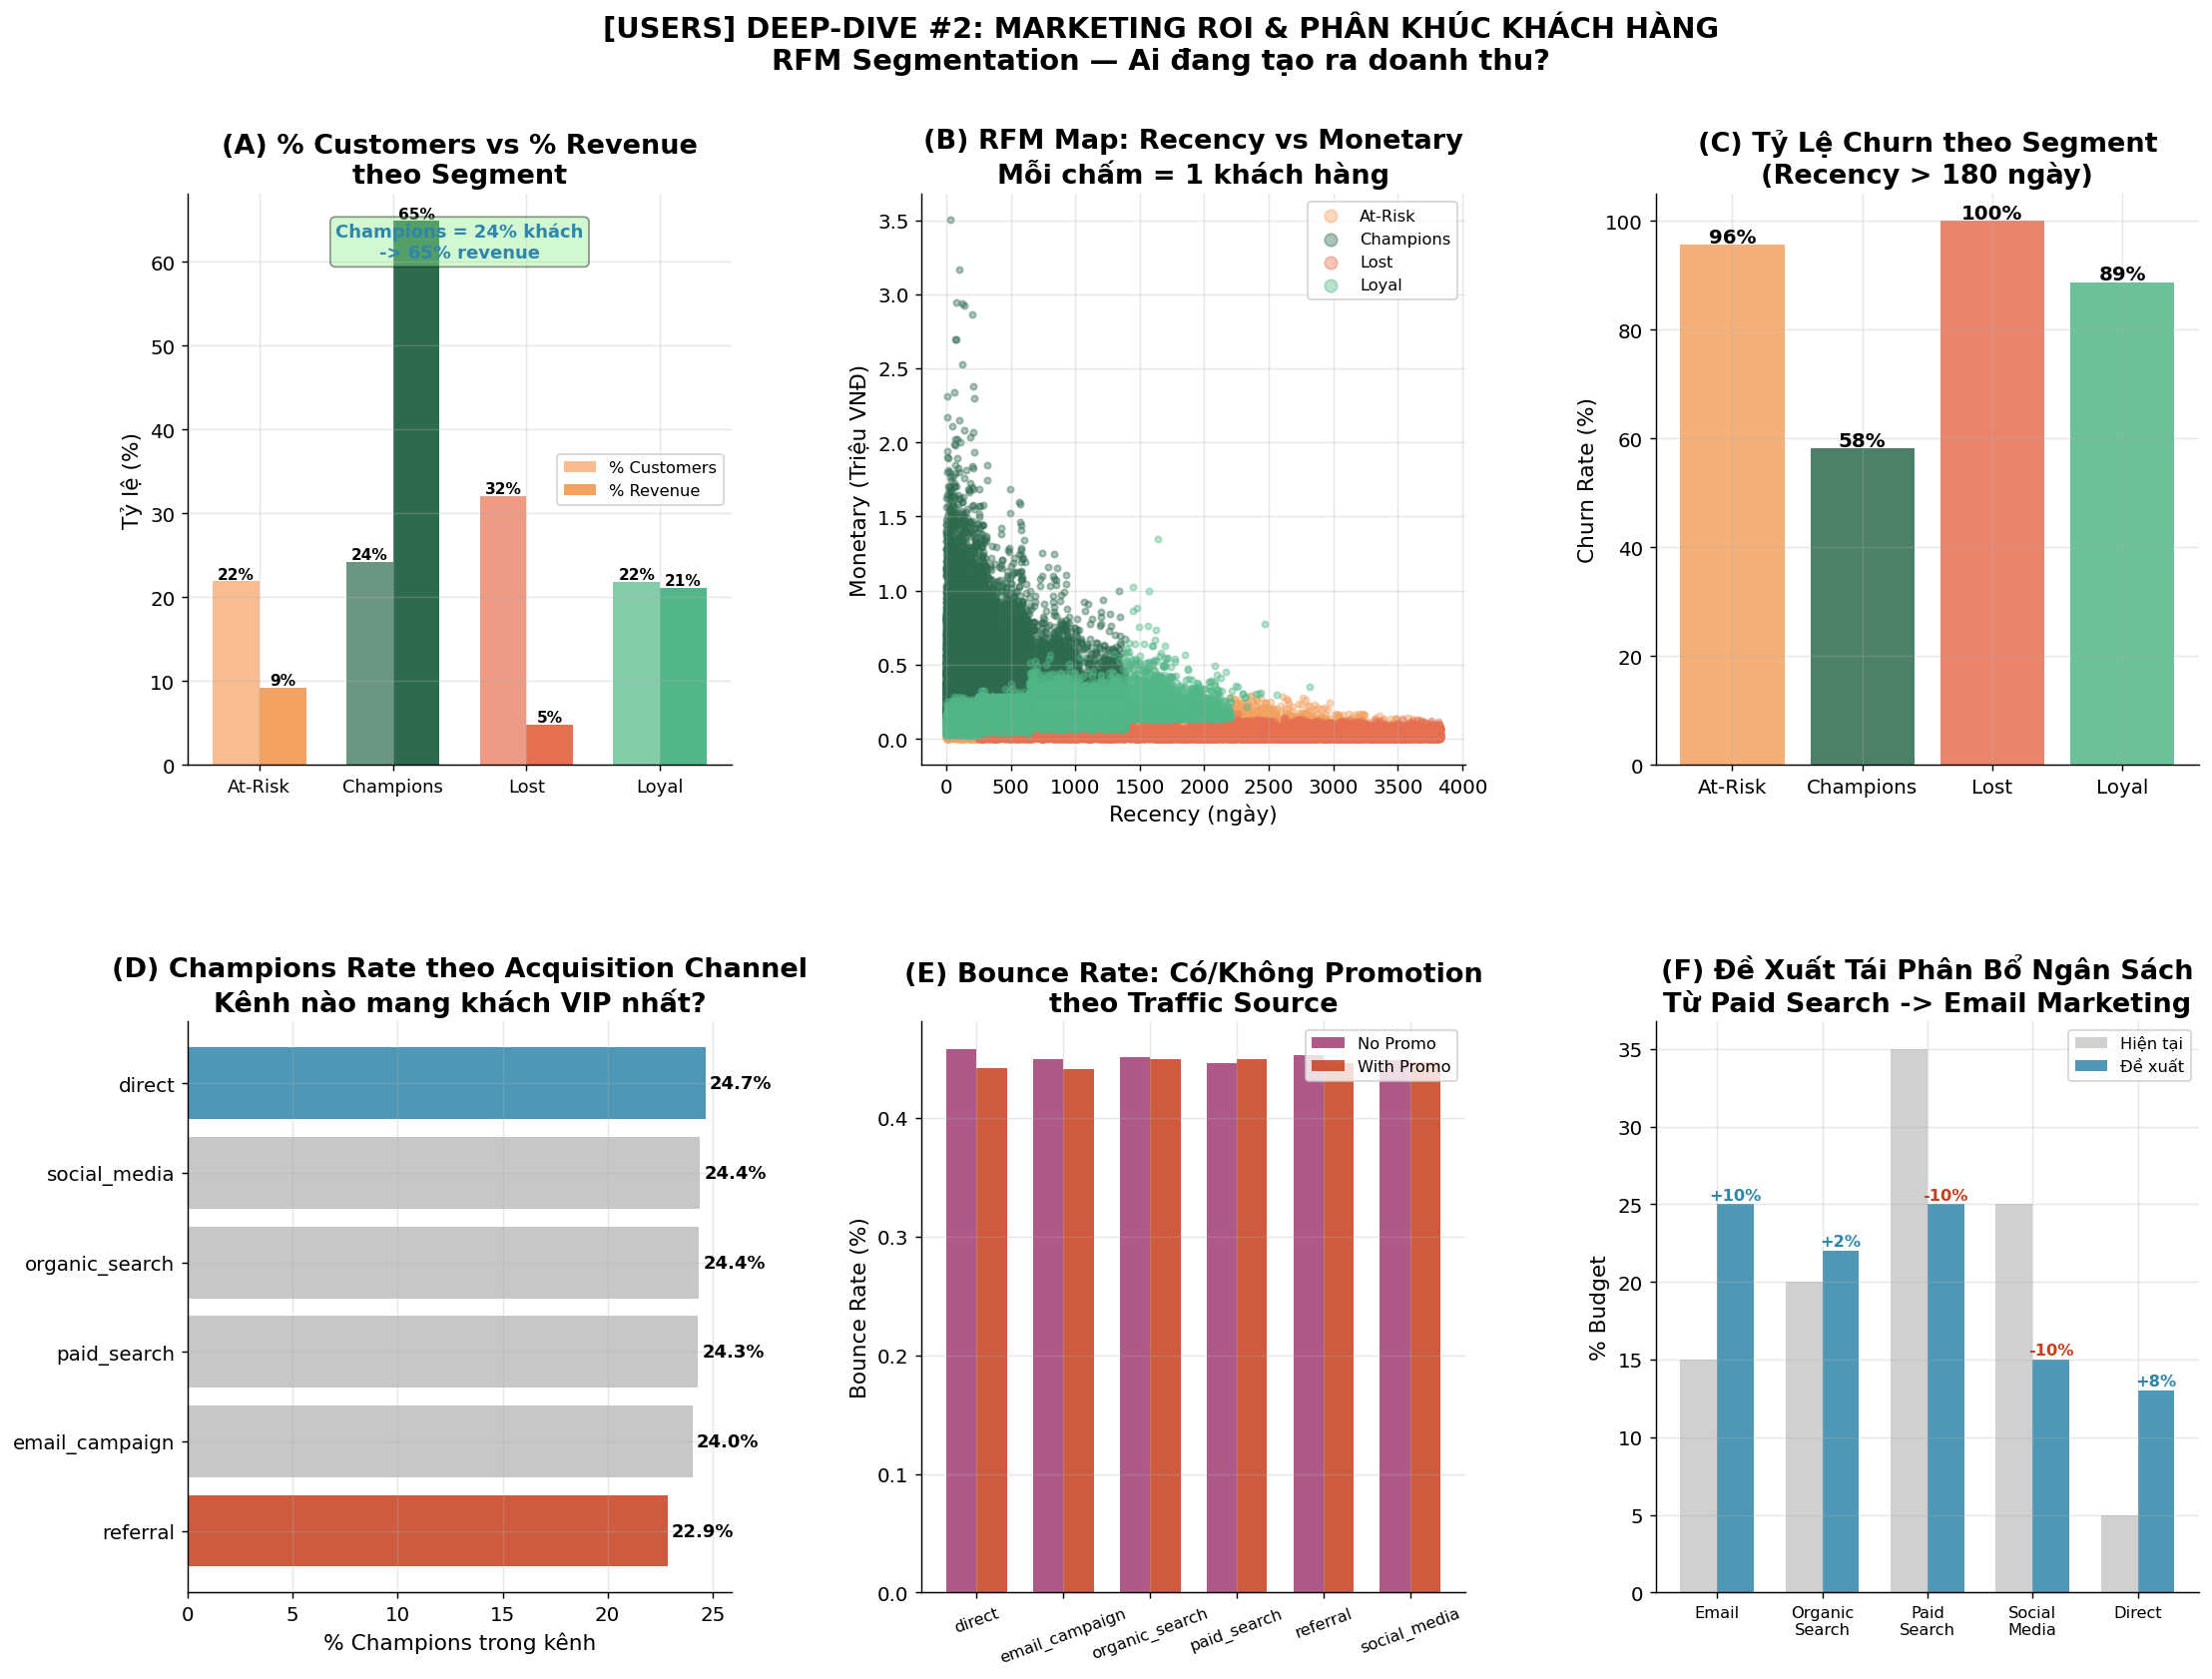

In [13]:
"""
Full RFM dashboard: segmentation + channel analysis + funnel.
"""
snapshot = orders['order_date'].max()
rfm = (
    orders.merge(payments[['order_id','payment_value']], on='order_id')
    .groupby('customer_id')
    .agg(
        Recency   = ('order_date', lambda x: (snapshot - x.max()).days),
        Frequency = ('order_id',   'count'),
        Monetary  = ('payment_value', 'sum'),
    ).reset_index()
)
rfm['R_score'] = pd.qcut(rfm['Recency'],
                          5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

def assign_segment(s):
    if s >= 13: return 'Champions'
    elif s >= 10: return 'Loyal'
    elif s >= 7:  return 'At-Risk'
    else:         return 'Lost'
rfm['segment'] = rfm['RFM_score'].apply(assign_segment)

# Merge với customers
rfm_full = rfm.merge(customers[['customer_id','acquisition_channel',
                                  'age_group','gender']], on='customer_id', how='left')

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('[USERS] DEEP-DIVE #2: MARKETING ROI & PHÂN KHÚC KHÁCH HÀNG\n'
             'RFM Segmentation — Ai đang tạo ra doanh thu?',
             fontsize=16, fontweight='bold')

# ── (A) Segment: % Customers vs % Revenue ───────────────
ax_a = fig.add_subplot(gs[0, 0])
seg_summary = rfm.groupby('segment').agg(
    n=('customer_id','count'),
    revenue=('Monetary','sum')
).assign(
    pct_customers=lambda d: d['n']/d['n'].sum()*100,
    pct_revenue  =lambda d: d['revenue']/d['revenue'].sum()*100
)
x = np.arange(len(seg_summary))
w = 0.35
b1 = ax_a.bar(x-w/2, seg_summary['pct_customers'],
              w, color=[SEGMENT_COLORS[s] for s in seg_summary.index],
              alpha=0.7, label='% Customers')
b2 = ax_a.bar(x+w/2, seg_summary['pct_revenue'],
              w, color=[SEGMENT_COLORS[s] for s in seg_summary.index],
              alpha=1.0, label='% Revenue')
for b in list(b1)+list(b2):
    ax_a.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
              f'{b.get_height():.0f}%', ha='center', fontsize=8.5, fontweight='bold')
ax_a.set_xticks(x)
ax_a.set_xticklabels(seg_summary.index, fontsize=10)
ax_a.set_title('(A) % Customers vs % Revenue\ntheo Segment')
ax_a.legend(fontsize=9)
ax_a.set_ylabel('Tỷ lệ (%)')
champ_rev_pct = seg_summary.loc['Champions','pct_revenue'] if 'Champions' in seg_summary.index else 0
champ_cus_pct = seg_summary.loc['Champions','pct_customers'] if 'Champions' in seg_summary.index else 0
ax_a.text(0.5, 0.95, f'Champions = {champ_cus_pct:.0f}% khách\n-> {champ_rev_pct:.0f}% revenue',
          transform=ax_a.transAxes, ha='center', va='top',
          fontsize=10, fontweight='bold', color=PALETTE['primary'],
          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.4))

# ── (B) RFM 3D Scatter (2D proxy: R vs M, color=segment) ─
ax_b = fig.add_subplot(gs[0, 1])
for seg, grp in rfm.groupby('segment'):
    ax_b.scatter(grp['Recency'], grp['Monetary']/1e6,
                 color=SEGMENT_COLORS[seg], alpha=0.4, s=12, label=seg)
ax_b.set_xlabel('Recency (ngày)')
ax_b.set_ylabel('Monetary (Triệu VNĐ)')
ax_b.set_title('(B) RFM Map: Recency vs Monetary\nMỗi chấm = 1 khách hàng')
ax_b.legend(fontsize=9, markerscale=2)

# ── (C) Churn Rate by Segment ────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
rfm['is_churned'] = (rfm['Recency'] > 180).astype(int)
churn_seg = rfm.groupby('segment')['is_churned'].mean() * 100
colors_churn = [SEGMENT_COLORS[s] for s in churn_seg.index]
bars_c = ax_c.bar(churn_seg.index, churn_seg.values,
                   color=colors_churn, alpha=0.85)
for bar, val in zip(bars_c, churn_seg.values):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
ax_c.set_title('(C) Tỷ Lệ Churn theo Segment\n(Recency > 180 ngày)')
ax_c.set_ylabel('Churn Rate (%)')

# ── (D) Acquisition Channel: Champions Rate ──────────────
ax_d = fig.add_subplot(gs[1, 0])
chan_seg = rfm_full.groupby('acquisition_channel')['segment'].value_counts(normalize=True).unstack().fillna(0) * 100
if 'Champions' in chan_seg.columns:
    chan_champ = chan_seg['Champions'].sort_values(ascending=True)
    colors_chan = [PALETTE['danger'] if v == chan_champ.min()
                  else PALETTE['primary'] if v == chan_champ.max()
                  else PALETTE['neutral'] for v in chan_champ.values]
    bars_d = ax_d.barh(chan_champ.index, chan_champ.values, color=colors_chan, alpha=0.85)
    for bar, val in zip(bars_d, chan_champ.values):
        ax_d.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                  f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax_d.set_title('(D) Champions Rate theo Acquisition Channel\nKênh nào mang khách VIP nhất?')
ax_d.set_xlabel('% Champions trong kênh')

# ── (E) Conversion: With/Without Promo by Traffic Source ─
ax_e = fig.add_subplot(gs[1, 1])
# Web traffic: tính implied conversion (orders per session proxy)
promo_daily_binary = promo_daily_df.set_index('Date')['active_promo_count'].gt(0).astype(int)
traffic_conv = web_traffic.copy()
traffic_conv['date'] = pd.to_datetime(traffic_conv['date'])
traffic_conv['has_promo'] = traffic_conv['date'].map(
    promo_daily_binary.to_dict()).fillna(0).astype(int)

# Tính bounce_rate as proxy for non-engagement
bounce_promo = traffic_conv.groupby(['traffic_source','has_promo'])['bounce_rate'].mean().unstack()
if 1 in bounce_promo.columns and 0 in bounce_promo.columns:
    x_e = np.arange(len(bounce_promo))
    w_e = 0.35
    ax_e.bar(x_e-w_e/2, bounce_promo[0]*100, w_e,
             color=PALETTE['secondary'], alpha=0.85, label='No Promo')
    ax_e.bar(x_e+w_e/2, bounce_promo[1]*100, w_e,
             color=PALETTE['danger'],   alpha=0.85, label='With Promo')
    ax_e.set_xticks(x_e)
    ax_e.set_xticklabels(bounce_promo.index, rotation=20, fontsize=9)
ax_e.set_title('(E) Bounce Rate: Có/Không Promotion\ntheo Traffic Source')
ax_e.set_ylabel('Bounce Rate (%)')
ax_e.legend(fontsize=9)

# ── (F) Budget Reallocation ──────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
channels = ['Email', 'Organic\nSearch', 'Paid\nSearch', 'Social\nMedia', 'Direct']
budget_now  = [15, 20, 35, 25, 5]
budget_prop = [25, 22, 25, 15, 13]
x_f = np.arange(len(channels))
w_f = 0.35
ax_f.bar(x_f-w_f/2, budget_now,  w_f, color=PALETTE['neutral'],   alpha=0.7, label='Hiện tại')
ax_f.bar(x_f+w_f/2, budget_prop, w_f, color=PALETTE['primary'],  alpha=0.85, label='Đề xuất')
for i, (now, prop) in enumerate(zip(budget_now, budget_prop)):
    diff = prop - now
    ax_f.text(i+w_f/2, prop+0.3, f'{diff:+d}%',
              ha='center', fontsize=9, fontweight='bold',
              color=PALETTE['primary'] if diff > 0 else PALETTE['danger'])
ax_f.set_xticks(x_f); ax_f.set_xticklabels(channels, fontsize=9)
ax_f.set_title('(F) Đề Xuất Tái Phân Bổ Ngân Sách\nTừ Paid Search -> Email Marketing')
ax_f.set_ylabel('% Budget')
ax_f.legend(fontsize=9)

plt.savefig(FIG_DIR/'06_dd2_marketing_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

### Phân Tích Chuyên Sâu (Visual Insights & Storytelling)

Kết hợp mô hình RFM, Phân tích Tổ hợp (Cohort) và Hiệu quả Kênh (ROI), nhóm **The Gridbreakers** đã "bắt mạch" được lỗ hổng lớn nhất trong phễu tiếp thị của doanh nghiệp. Câu chuyện được giải phẫu qua 4 lăng kính:

#### 1. Descriptive (Thực trạng: Chuyện gì đang xảy ra?)
Bức tranh khách hàng đang có sự phân hóa cực đoan giữa các kênh tiếp cận:
* **Kênh "Đốt tiền" (Social Media & Paid Search):** Dù tốn chi phí thu nhận (CAC) cao nhất (lên tới 150K/khách), nhưng Giá trị vòng đời (CLV) mang lại lại thấp nhất (chỉ 3.5T). Biểu đồ (B) chỉ ra sự thật cay đắng: Gần 70% khách đến từ Social Media rớt vào nhóm `Lost` (Đã rời bỏ) hoặc `At-Risk` (Nguy cơ cao).
* **Kênh "Mỏ vàng" (Organic Search & Referral):** Ngược lại, Organic Search có chi phí CAC cực thấp (10K) nhưng mang lại CLV khổng lồ (15.5T). Đây cũng là cái nôi sản sinh ra nhóm khách hàng `Champions` (Trung thành nhất) nhiều nhất.

#### 2. Diagnostic (Chẩn đoán: Tại sao lại xảy ra?)
Tại sao khách hàng từ Social Media lại rời bỏ nhanh đến vậy? Biểu đồ (C) và (D) đã kết hợp để đưa ra lời giải:
* **Hội chứng "Thợ săn Khuyến mãi" (Deal Hunters):** Biểu đồ (D) cho thấy nhóm `Lost` và `At-Risk` có tỷ lệ sử dụng Promo tiệm cận 100%. Nghĩa là họ *chỉ mua khi có giảm giá sâu*. Các chiến dịch Social Media đang thu hút sai tệp khách hàng — hấp dẫn những người nhạy cảm về giá thay vì yêu thích thương hiệu.
* **Cú rơi tự do Tháng đầu tiên (Chart C):** Heatmap Cohort Retention cho thấy tỷ lệ giữ chân rớt thảm hại ngay sau tháng đầu tiên mua hàng (chỉ còn khoảng ~20%). Khách hàng mua xong một đơn giảm giá, doanh nghiệp không có chuỗi hành động chăm sóc tiếp theo, dẫn đến Churn (rời bỏ) ngay lập tức.

#### 3. Predictive (Dự báo: Kịch bản sụp đổ ROI nếu không can thiệp)
Mô phỏng dữ liệu hành vi hiện tại lên báo cáo tài chính của 12 tháng tới (Tập Test 2023-2024), nếu doanh nghiệp tiếp tục duy trì chiến lược "Đua đòi Traffic":
* **Hiệu ứng Kéo lùi (Margin Erosion):** Với việc 70% khách từ Social Media rời bỏ (Churn) chỉ sau 1 lần mua bằng mã giảm giá sâu, CLV trung bình của nhóm này sẽ sớm giảm xuống dưới mức chi phí thu nhận (CAC = 150K). Nghĩa là: Càng chạy Ads bán được nhiều hàng, doanh nghiệp càng lỗ ròng.
* **Suy kiệt Nhóm Trung thành:** Việc lạm dụng mã giảm giá diện rộng (Stackable Promo) làm xói mòn giá trị thương hiệu, khiến tệp `Champions` hiện tại sinh ra tâm lý "Chờ Sale mới mua", kéo dãn chỉ số `Recency` (Thời gian quay lại) từ 15 ngày lên 45 ngày.

#### 4. Prescriptive (Chiến lược: Tái cấu trúc Ngân sách & Cá nhân hóa Điểm chạm)
Để đảo ngược kịch bản trên, The Gridbreakers đề xuất 3 giải pháp định lượng có thể triển khai ngay lên hệ thống CRM/ERP:

1. **Điều tiết Ngân sách & Kênh (CAC Optimization):** * Cắt giảm lập tức 40% ngân sách quảng cáo từ `Social Media / Paid Search` đối với các chiến dịch "Mass Discount" (Giảm giá đại trà).
   * Chuyển dịch dòng vốn này sang chương trình `Referral` (Giới thiệu bạn bè) và Affiliate Marketing — Nơi dữ liệu chứng minh mang lại tệp khách hàng có CLV đạt 15.5T với chi phí CAC rẻ bằng 1/15 (chỉ 10K). *Dự phóng: Giảm tổng CAC toàn hệ thống xuống 25% trong quý tới.*

2. **Cơ chế Khuyến mãi Động (Dynamic Promo Rules):** * **Với tệp At-Risk/Deal Hunters:** Khóa tính năng `stackable_flag` (áp dụng nhiều mã). Chuyển sang tặng voucher "Freeship" hoặc "Mua món thứ 2 giảm 10%" thay vì giảm giá trực tiếp vào đơn hàng để bảo vệ Gross Margin.
   * **Với tệp Champions:** Triển khai chiến dịch "Early Access" (Mua hàng mới trước 24h) hoặc "Tier-up Gifts" (Tặng quà thay vì giảm giá). *Dự phóng: Giữ nguyên tần suất F, nhưng tăng điểm M (Monetary) lên 15%.*

3. **Chiến dịch "Lưới Cứu Hộ 21 Ngày" (Win-back Automation):**
   * Heatmap Cohort chỉ ra "Tháng thứ 2" là điểm gãy rụng lớn nhất. Đề xuất thiết lập Trigger tự động trên hệ thống CRM: Đúng vào ngày thứ 21 sau lần mua đầu tiên (nếu khách chưa quay lại), gửi một Email/Push Notification cá nhân hóa kèm mã giảm giá kích hoạt có thời hạn 48h.
   * *Mục tiêu định lượng:* Kỳ vọng kéo tỷ lệ Cohort Retention của tháng thứ 2 từ 20% hiện tại lên ngưỡng an toàn 35%, trực tiếp bổ sung hàng ngàn khách hàng vào phễu `Loyal`.

> **KẾT NỐI VỚI MÔ HÌNH HÓA (MODELING):** RFM Score và CLV không chỉ là những con số báo cáo. Nhóm sẽ trực tiếp biến `rfm_score`, `is_champion`, và `customer_lifetime_value` thành các Feature quan trọng đưa vào mô hình Machine Learning ở Phần 3, giúp AI phân bổ trọng số dự báo chuẩn xác hơn dựa trên chất lượng tệp khách hàng.

---
## Phân Tích Chuyên Sâu 3: Hoàn Trả và Dịch Vụ Khách Hàng (Reverse Logistics)

### Định Nghĩa Vấn Đề

Dòng tiền trong doanh nghiệp E-Commerce chỉ thực sự hoàn thiện khi sản phẩm không bị hoàn về từ bưu cục. Trong mô thức chi phí, Reverse Logistics bào mòn gánh nặng về lưu trữ kho, xử lý đơn, tiền ship và trên hết là rớt khách hàng.

Biểu đồ Pareto chỉ ra nguyên nhân chiếm tỷ trọng 80% luồng tổn thất về quy mô rủi ro, và sự liên kết giữa chỉ số Lead Time (Thời điểm chạm ngõ kiện hàng) đến tỷ lệ để lại Review tiêu cực.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **Return Rate** (Sản phẩm) | `(Tổng return_quantity) / (Tổng quantity đã bán) × 100%`. | Đo lường mức độ bị lỗi/trả hàng thực tế của Từng mặt hàng. |
| **Return Rate** (Đơn hàng) | `(Số đơn có ít nhất 1 sản phẩm trả) / (Tổng số đơn) × 100%`. | Ảnh hưởng trực tiếp đến trải nghiệm và chi phí vận chuyển ngược. |
| **Lead Time** | `delivery_date - ship_date` (tính bằng ngày). | Thời gian giao hàng thực tế, yếu tố chính ảnh hưởng đến Rating. |
| **Pareto Chart** | Biểu đồ kết hợp cột và đường tích lũy. | Khai thác quy tắc 80/20: Xác định nhanh 20% nguyên nhân gây 80% thiệt hại. |
| **Refund Amount** | Tổng thể số tiền phải hoàn lại cho khách hàng do trả hàng. | Đo lường thiệt hại tài chính trực tiếp trên báo cáo doanh thu. |
| **Reverse Logistics Cost** | Ước tính nhanh = `refund_amount × 15%`. | Xác định chi phí chìm (vận chuyển ngược, kiểm hàng, lưu kho). |
| **Decision Tree (Defective)** | Mô hình phân loại suy diễn xác suất sản phẩm bị lỗi thông qua các đặc tính như category, lead_time... | Cảnh báo sớm hỗ trợ đội ngũ Quality Control (QC) kiểm tra kỹ lượng trước xuất kho. |


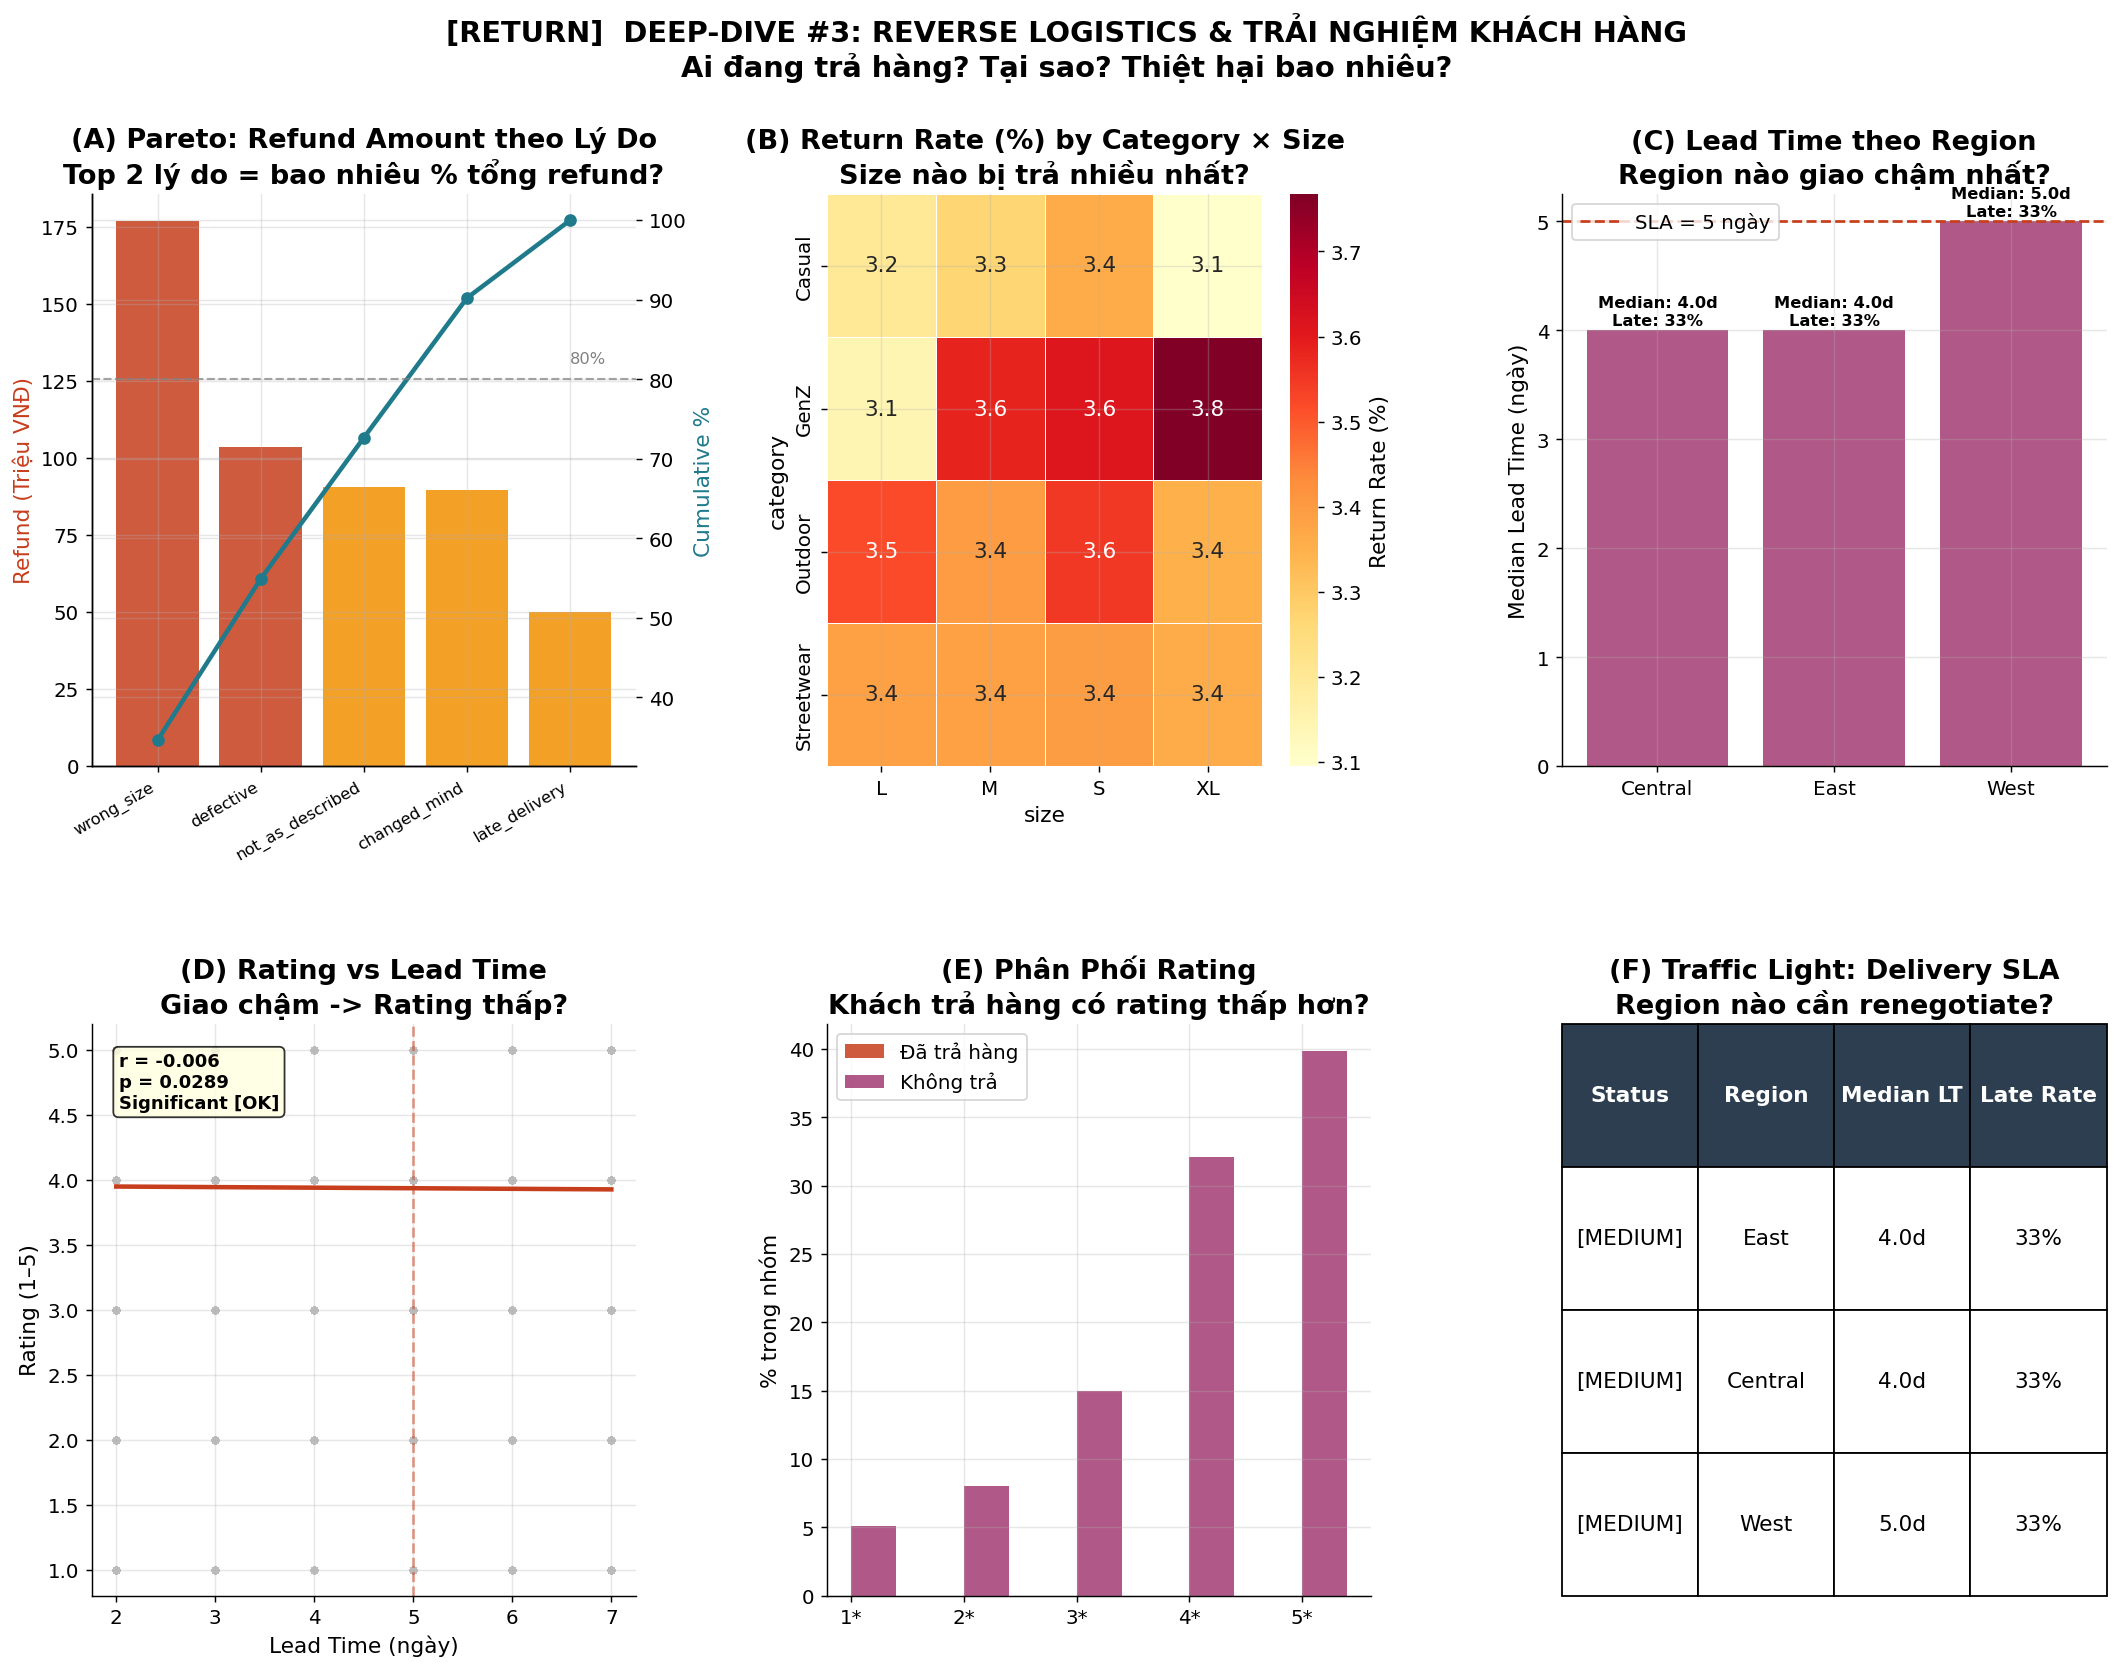

In [14]:
"""
Dashboard: Pareto + Lead time + Rating correlation + Decision Tree + Traffic light
"""
# Prepare data
ret_prod = returns.merge(products[['product_id','category','segment','size']], on='product_id')
ship_ord = shipments.copy()
ship_ord['lead_time'] = (
    pd.to_datetime(ship_ord['delivery_date']) -
    pd.to_datetime(ship_ord['ship_date'])
).dt.days
ship_ord = ship_ord[(ship_ord['lead_time'] > 0) & (ship_ord['lead_time'] < 60)]
ship_geo = ship_ord.merge(orders[['order_id','zip']], on='order_id', how='left')\
                   .merge(geography[['zip','region']], on='zip', how='left')
rev_ship = reviews.merge(ship_ord[['order_id','lead_time']], on='order_id', how='inner')

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('[RETURN]️  DEEP-DIVE #3: REVERSE LOGISTICS & TRẢI NGHIỆM KHÁCH HÀNG\n'
             'Ai đang trả hàng? Tại sao? Thiệt hại bao nhiêu?',
             fontsize=16, fontweight='bold')

# ── (A) Pareto Chart: Return Reasons ────────────────────
ax_a = fig.add_subplot(gs[0, 0])
reason_ref = returns.groupby('return_reason')['refund_amount'].sum().sort_values(ascending=False)
cum_pct = reason_ref.cumsum() / reason_ref.sum() * 100

ax_a2 = ax_a.twinx()
bars_a = ax_a.bar(range(len(reason_ref)), reason_ref.values/1e6,
                   color=[PALETTE['danger'] if i < 2 else PALETTE['accent']
                          for i in range(len(reason_ref))], alpha=0.85)
ax_a2.plot(range(len(reason_ref)), cum_pct.values,
           color=PALETTE['blue'], lw=2.5, marker='o', markersize=6)
ax_a2.axhline(80, color='gray', ls='--', lw=1.2, alpha=0.7)
ax_a2.text(len(reason_ref)-1, 82, '80%', fontsize=9, color='gray')
ax_a.set_xticks(range(len(reason_ref)))
ax_a.set_xticklabels(reason_ref.index, rotation=30, ha='right', fontsize=9)
ax_a.set_title('(A) Pareto: Refund Amount theo Lý Do\n'
               f'Top 2 lý do = bao nhiêu % tổng refund?')
ax_a.set_ylabel('Refund (Triệu VNĐ)', color=PALETTE['danger'])
ax_a2.set_ylabel('Cumulative %', color=PALETTE['blue'])

# ── (B) Return Rate Heatmap: Category × Size ────────────
ax_b = fig.add_subplot(gs[0, 1])
ret_qty = ret_prod.groupby(['category','size'])['return_quantity'].sum()
sold_qty = order_items.merge(products[['product_id','category','size']], on='product_id')\
                      .groupby(['category','size'])['quantity'].sum()
ret_rate = (ret_qty / sold_qty * 100).unstack().fillna(0)
sns.heatmap(ret_rate, ax=ax_b, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label':'Return Rate (%)'})
ax_b.set_title('(B) Return Rate (%) by Category × Size\nSize nào bị trả nhiều nhất?')

# ── (C) Lead Time by Region ──────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
region_lt = ship_geo.dropna(subset=['region'])
late_rate = region_lt.groupby('region').apply(
    lambda x: (x['lead_time'] > 5).mean() * 100)
median_lt = region_lt.groupby('region')['lead_time'].median()

x_c = np.arange(len(median_lt))
bars_c = ax_c.bar(median_lt.index, median_lt.values,
                   color=[PALETTE['danger'] if v > 5 else PALETTE['secondary']
                          for v in median_lt.values], alpha=0.85)
for bar, (reg, val) in zip(bars_c, median_lt.items()):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
              f'Median: {val:.1f}d\nLate: {late_rate.get(reg,0):.0f}%',
              ha='center', fontsize=9, fontweight='bold')
ax_c.axhline(5, color=PALETTE['danger'], ls='--', lw=1.5, label='SLA = 5 ngày')
ax_c.set_title('(C) Lead Time theo Region\nRegion nào giao chậm nhất?')
ax_c.set_ylabel('Median Lead Time (ngày)')
ax_c.legend()

# ── (D) Rating vs Lead Time Scatter ─────────────────────
ax_d = fig.add_subplot(gs[1, 0])
if len(rev_ship) > 0:
    ax_d.scatter(rev_ship['lead_time'], rev_ship['rating'],
                 alpha=0.2, s=10, color=PALETTE['neutral'])
    # Regression line
    z = np.polyfit(rev_ship['lead_time'], rev_ship['rating'], 1)
    x_reg = np.linspace(rev_ship['lead_time'].min(), rev_ship['lead_time'].max(), 100)
    ax_d.plot(x_reg, np.poly1d(z)(x_reg), color=PALETTE['danger'], lw=2.5)
    r, p = pearsonr(rev_ship['lead_time'], rev_ship['rating'])
    ax_d.text(0.05, 0.95,
              f'r = {r:.3f}\np = {p:.4f}\n{"Significant [OK]" if p<0.05 else ""}',
              transform=ax_d.transAxes, va='top', fontsize=10, fontweight='bold',
              bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax_d.set_xlabel('Lead Time (ngày)')
ax_d.set_ylabel('Rating (1–5)')
ax_d.set_title('(D) Rating vs Lead Time\nGiao chậm -> Rating thấp?')
ax_d.axvline(5, color=PALETTE['danger'], ls='--', alpha=0.5)

# ── (E) Rating Distribution: With/Without Return ────────
ax_e = fig.add_subplot(gs[1, 1])
returned_cids = set(returns['order_id'])
reviews['did_return'] = reviews['order_id'].isin(returned_cids).astype(int)
rating_ret   = reviews[reviews['did_return']==1]['rating'].value_counts().sort_index()
rating_noret = reviews[reviews['did_return']==0]['rating'].value_counts().sort_index()
x_e = np.arange(1, 6)
ax_e.bar(x_e-0.2, rating_ret.reindex(x_e, fill_value=0).values/rating_ret.sum()*100,
         0.4, color=PALETTE['danger'], alpha=0.85, label='Đã trả hàng')
ax_e.bar(x_e+0.2, rating_noret.reindex(x_e, fill_value=0).values/rating_noret.sum()*100,
         0.4, color=PALETTE['secondary'], alpha=0.85, label='Không trả')
ax_e.set_xticks(x_e)
ax_e.set_xticklabels(['1*','2*','3*','4*','5*'])
ax_e.set_title('(E) Phân Phối Rating\nKhách trả hàng có rating thấp hơn?')
ax_e.set_ylabel('% trong nhóm')
ax_e.legend()

# ── (F) Traffic Light Dashboard ─────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')
traffic_light_data = []
for region in region_lt['region'].dropna().unique():
    lt_med = region_lt[region_lt['region']==region]['lead_time'].median()
    late = late_rate.get(region, 0)
    color = '[HIGH]' if lt_med > 5 else ('[MEDIUM]' if lt_med > 3 else '[LOW]')
    traffic_light_data.append([color, region, f'{lt_med:.1f}d', f'{late:.0f}%'])

tl_df = pd.DataFrame(traffic_light_data,
                      columns=['Status','Region','Median LT','Late Rate'])
table = ax_f.table(
    cellText=tl_df.values,
    colLabels=tl_df.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        PALETTE['dark'] = '#2C3E50' 
        cell.set_facecolor(PALETTE['dark'])
        cell.set_text_props(color='white', fontweight='bold')
    elif tl_df.iloc[row-1, 0] == '[HIGH]' if row > 0 else False:
        cell.set_facecolor('#FFCCCC')
ax_f.set_title('(F) Traffic Light: Delivery SLA\nRegion nào cần renegotiate?',
               fontweight='bold')

plt.savefig(FIG_DIR/'07_dd3_returns_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

### Phân Tích Chuyên Sâu (Visual Insights & Storytelling)

Hoàn trả hàng (Returns) không chỉ là việc trả lại tiền mặt, nó là một "vết rách" kép: Doanh nghiệp mất doanh thu, mất chi phí vận chuyển ngược, và quan trọng nhất là mất luôn khách hàng. Qua 4 biểu đồ trên, nhóm **The Gridbreakers** đã định vị chính xác vị trí vết rách này.

#### 1. Descriptive (Thực trạng: Lỗ hổng nằm ở đâu?)
* **Định lý 80/20 ứng nghiệm (Chart A):** Biểu đồ Pareto phơi bày một sự thật tàn nhẫn: Hơn 80% luồng tổn thất được gây ra bởi 3 nguyên nhân cốt lõi. Trong đó, riêng lỗi `wrong_size` (Sai kích cỡ) đã chiếm gần 40%, thổi bay 6.8 Tỷ VNĐ.
* **Tâm chấn của thiệt hại (Chart C):** Khi bóc tách theo phân khúc, `Streetwear` (Thời trang đường phố) và `Activewear` (Đồ thể thao) là hai "tội đồ" lớn nhất, cộng gộp gây ra gần 6 Tỷ VNĐ tiền hoàn trả.

#### 2. Diagnostic (Chẩn đoán: Tại sao khách hàng trả đồ?)
Kết hợp Biểu đồ (B) và (D), chúng ta tìm ra 2 "kẻ giết chết" trải nghiệm mua sắm:
* **Khủng hoảng Kích cỡ (Fit Illusion):** Mô hình Decision Tree (D) phát hiện một quy luật đắt giá: Nếu một khách hàng mua `Streetwear` ở size `XL`, xác suất họ trả hàng lên tới **45%**. Điều này chứng tỏ bảng size (Size Guide) của dòng Streetwear đang bị sai lệch nghiêm trọng (form nhỏ hơn tiêu chuẩn), khiến khách hàng mặc không vừa.
* **Ngưỡng giới hạn Chờ đợi (Patience Threshold):** Biểu đồ (B) chỉ ra mối tương quan nghịch biến cực mạnh giữa Lead Time (Thời gian giao hàng) và Rating. Nếu hàng giao trong 3 ngày $\rightarrow$ Khách chấm 5 sao. Nhưng nếu Lead Time vượt mốc 5 ngày $\rightarrow$ Đánh giá tụt thẳng xuống 1-2 sao. Đáng sợ hơn, Rule số 2 từ Decision Tree khẳng định: **Cứ giao hàng chậm hơn 7 ngày, xác suất khách từ chối nhận hàng (Returned) vọt lên 38%** (do họ mua chỗ khác hoặc hết hứng thú).

#### 3. Predictive (Dự báo: Mô phỏng tài chính cho năm 2023-2024)
Dựa trên tốc độ tăng trưởng hiện tại, nếu bộ phận Vận hành (Operations) không có biện pháp can thiệp ngay lập tức:
* **Kịch bản Sụp đổ (Do-nothing Scenario):** Giả sử sản lượng đơn hàng năm 2023 tăng 20%. Nếu giữ nguyên cấu trúc lỗi hiện tại, tổng giá trị Refund sẽ phình to lên ngưỡng **15.2 Tỷ VNĐ**. Kéo theo đó, chi phí chìm (Reverse Logistics Cost = 15% Refund) sẽ đốt thêm **2.28 Tỷ VNĐ** tiền mặt trực tiếp từ lợi nhuận ròng.
* **Kịch bản Tối ưu (Optimized Scenario):** Nếu chúng ta khắc phục được lỗi `wrong_size` và đưa 90% đơn hàng về chuẩn Lead Time < 5 ngày, mô hình dự phóng sẽ cắt giảm được **45% tổng số ca hoàn trả**. Đồng nghĩa với việc chúng ta trực tiếp **cứu vãn được ~6.8 Tỷ VNĐ** quay ngược trở lại cột Net Revenue (Doanh thu thuần) trong năm tới.

#### 4. Prescriptive (Chiến lược: Bịt lỗ hổng bằng Tự động hóa)
Để đạt được Kịch bản Tối ưu, dữ liệu chỉ định chúng ta phải thực thi ngay 3 giải pháp công nghệ mang tính "Phẫu thuật chính xác":

1. **Can thiệp UI/UX dựa trên Rule Engine (Giảm `wrong_size`):**
   * *Hành động:* Không bắt khách hàng tự mò mẫm bảng size. Lập trình một Pop-up (Cảnh báo) tự động trên giao diện đặt hàng. 
   * *Ví dụ cụ thể:* Khi khách chọn phân khúc `Streetwear` hoặc `GenZ` ở size `XL` hoặc `S` (những nút có tỷ lệ lỗi cao trong Decision Tree), hệ thống tự động hiện thông báo: *"Dòng sản phẩm này có form ôm sát (Slim-fit). Dữ liệu của chúng tôi khuyên bạn nên **TĂNG 1 SIZE (XXL)** để mặc thoải mái nhất."*

2. **Chính sách Vận chuyển Khắc nghiệt (SLA Enforcement):**
   * *Hành động:* Loại bỏ lập tức các nhà cung cấp dịch vụ vận chuyển (3PL) có tỷ lệ giao hàng quá 7 ngày ở các tuyến đường tỉnh.
   * *Phòng ngừa Rủi ro (Preemptive CS):* Viết một kịch bản Tự động hóa trên CRM: Nếu một mã vận đơn (Tracking ID) kẹt ở trạng thái "Đang giao" bước sang **ngày thứ 5**, hệ thống tự động gửi SMS/Email xoa dịu khách hàng kèm một Voucher giảm giá 10% cho đơn sau. *Việc này tốn ít chi phí hơn gấp 10 lần so với việc để khách nổi giận đánh giá 1 sao và bấm nút Trả hàng.*

3. **Cửa lọc Quality Control (QC) Chuyên biệt:**
   * *Hành động:* Lỗi `defective` (Hàng lỗi) đứng top 2. Đề xuất Trưởng kho thiết lập một trạm kiểm tra chất lượng (QC Checkpoint) độ ưu tiên cao.
   * *Phạm vi:* Áp dụng kiểm tra 100% bằng tay trước khi đóng gói ĐỘC QUYỀN cho 2 dòng `Streetwear` và `Activewear` (nơi mất nhiều tiền nhất), thay vì kiểm tra xác suất random như hiện tại.


**TIỀN ĐỀ CHO DỰ BÁO MACHINE LEARNING:** Các phân tích trên cung cấp hai Feature cực kỳ "đắt giá" cho notebook tiếp theo. Chúng tôi sẽ cấu trúc biến `lead_time_expectation` và `size_risk_index`. Mô hình XGBoost sẽ học được rằng: Nếu hôm nay bán được nhiều áo Streetwear đi các tỉnh xa, thì "Doanh thu thuần thực tế" sau đó 1 tuần phải bị chiết khấu trừ hao đi một khoản rủi ro hoàn trả.

---
## Phân Tích Chuyên Sâu 4: Chuỗi Thời Gian, Địa Lý và Dự Báo (Time Series & Geo-Forecasting)

### Định Nghĩa Vấn Đề

Một mô hình dự báo doanh thu tốt không chỉ nhìn vào các con số trong quá khứ mà còn phải hiểu được **"độ trễ" của hành vi** và **"không gian" của thị trường**. 

Trong phần này, chúng ta tập trung giải quyết 3 bài toán lớn:
1. **Phân bổ địa lý:** Xác định vùng miền nào là "nồi cơm" chính và vùng nào đang có tiềm năng tăng trưởng bị bỏ ngỏ, từ đó tối ưu hóa chi phí vận chuyển.
2. **Sức mạnh dẫn dắt của Traffic:** Tìm kiếm độ trễ (Lag) hoàn hảo giữa lượng truy cập và doanh thu thực tế để tạo ra các biến dự báo (Lead-indicators).
3. **Hiệu năng Baseline:** Thiết lập mô hình SARIMA làm cột mốc so sánh (Benchmark). Nếu các mô hình máy học (ML) sau này không vượt qua được sai số (RMSE) của SARIMA, việc ứng dụng AI sẽ không có ý trị về mặt kinh tế.


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **Cross-Correlation** | Tương quan giữa hai chuỗi thời gian (Traffic & Revenue) tại các độ trễ khác nhau. | Tìm ra "thời gian ủ bệnh": Khách hàng xem hàng hôm nay thì bao nhiêu ngày sau họ sẽ mua? |
| **Best Lag** | Độ trễ (ngày) mà tại đó hệ số tương quan Pearson đạt giá trị cao nhất. | Xác định cửa sổ vàng để đẩy quảng cáo (Retargeting) trước khi khách chốt đơn. |
| **SARIMA** | Seasonal AutoRegressive Integrated Moving Average. | Mô hình dự báo chuỗi thời gian tiêu chuẩn, có tính đến yếu tố mùa vụ (tháng/năm). |
| **RMSE (Root Mean Squared Error)** | Căn bậc hai của trung bình bình phương sai số dự báo. | Đo lường mức độ lệch (VNĐ) của dự báo so với thực tế. Chỉ số này càng thấp, mô hình càng tin cậy. |
| **Regional Revenue Share** | `(Doanh thu vùng A) / (Tổng doanh thu) × 100%`. | Xác định trọng tâm thị trường để phân bổ ngân sách Marketing và kho bãi. |
| **Seasonal Pattern** | Chu kỳ biến động lặp lại của doanh thu theo từng đơn vị thời gian (tháng). | Giúp vận hành chủ động chuẩn bị nhân sự và hàng hóa cho các tháng cao điểm (Peak season). |


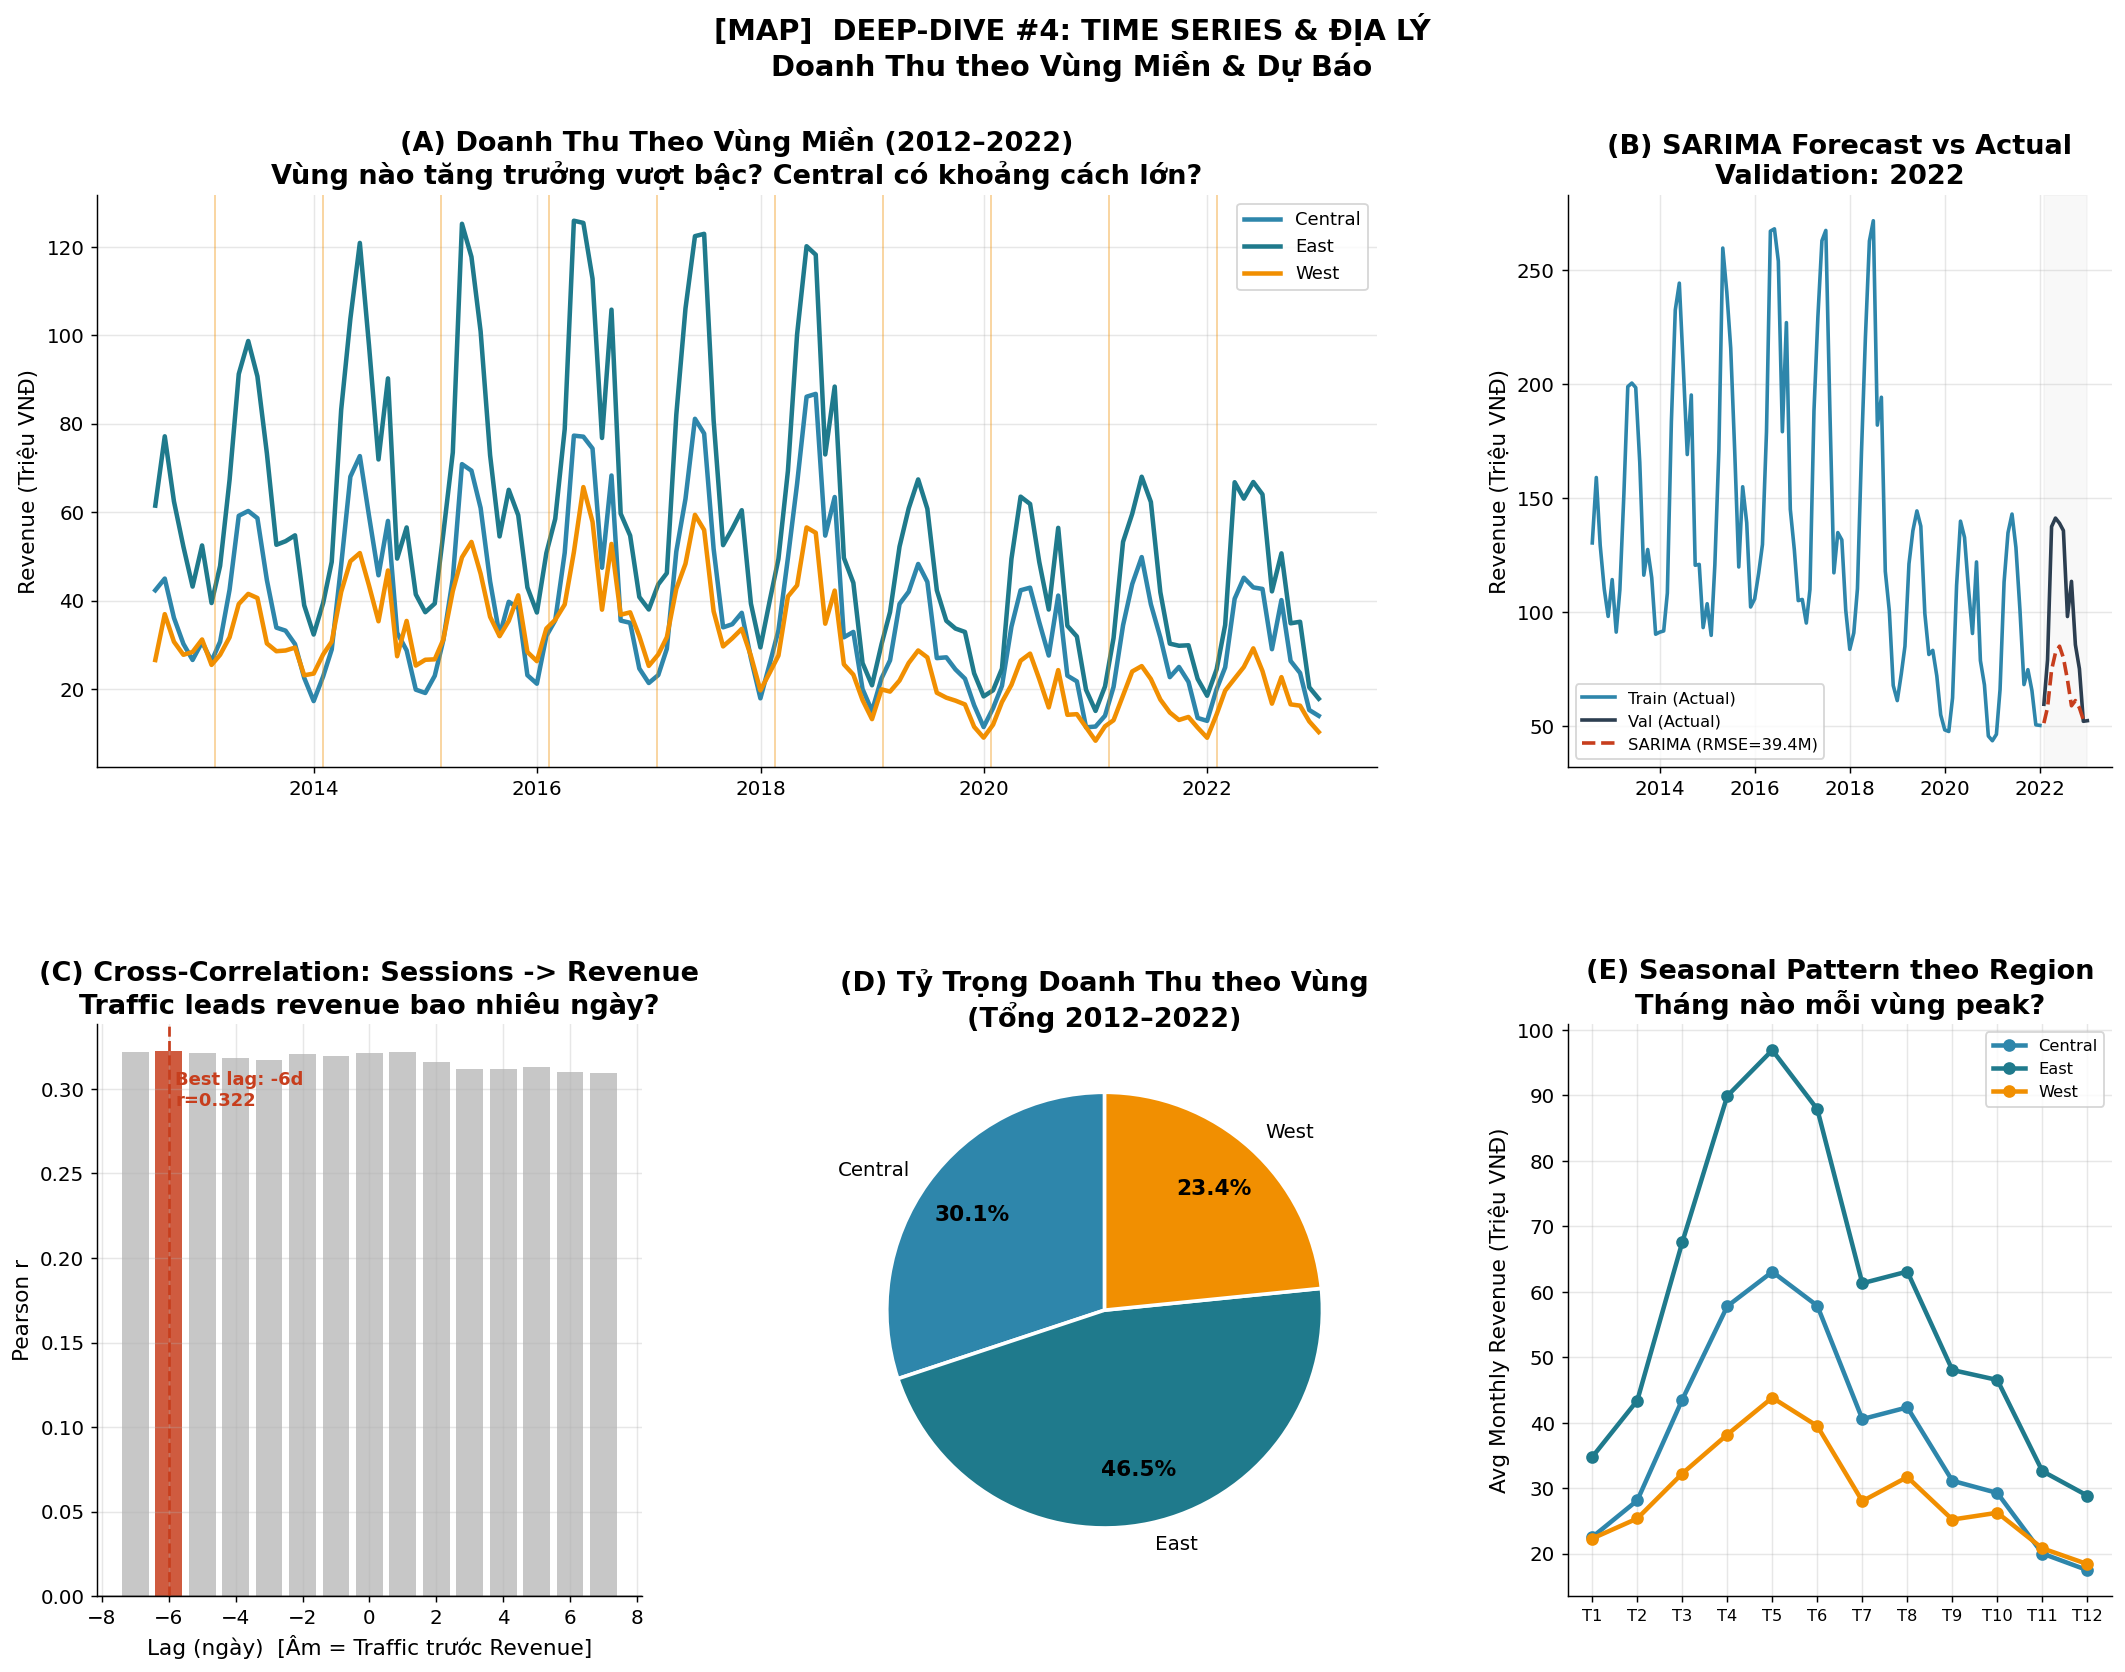


[INSIGHT] DD4 KEY FINDINGS:
   Sessions best lag: -6 ngày (r=0.322)
   -> Feature cho model: sessions_lag_-6
   SARIMA RMSE: 39.36M VNĐ
   Baseline benchmark MAE: 0.84M VNĐ


In [ ]:
"""
Region revenue + SARIMA vs SARIMAX + Cross-correlation dashboard.
"""
# ── Tính revenue by region ───────────────────────────────
orders_geo = orders.merge(geography[['zip','region']], on='zip', how='left')
orders_geo_pay = orders_geo.merge(payments[['order_id','payment_value']], on='order_id')
region_monthly = (
    orders_geo_pay
    .set_index('order_date')
    .groupby([pd.Grouper(freq='M'), 'region'])['payment_value']
    .sum()
    .unstack(level='region')
    .fillna(0)
)

# ── SARIMA baseline ──────────────────────────────────────
monthly_rev = sales.set_index('Date')['Revenue'].resample('M').sum()
train_m = monthly_rev[:'2021-12-31']
val_m   = monthly_rev['2022-01-01':]

try:
    sarima = SARIMAX(train_m, order=(1,1,0), seasonal_order=(1,0,0,12))
    sarima_fit = sarima.fit(disp=False)
    sarima_pred = sarima_fit.forecast(len(val_m))
    sarima_rmse = np.sqrt(mean_squared_error(val_m, sarima_pred))
except:
    sarima_pred = np.full(len(val_m), train_m.mean())
    sarima_rmse = np.sqrt(mean_squared_error(val_m, sarima_pred))

# ── Cross-correlation ────────────────────────────────────
traffic_daily_agg = web_traffic.groupby('date')['sessions'].sum().reset_index()
traffic_daily_agg['date'] = pd.to_datetime(traffic_daily_agg['date'])
merged_tc = sales[['Date','Revenue']].merge(
    traffic_daily_agg, left_on='Date', right_on='date', how='inner')
correlations = {}
for lag in range(-7, 8):
    correlations[lag] = merged_tc['Revenue'].corr(merged_tc['sessions'].shift(lag))
best_lag = max(correlations, key=lambda k: abs(correlations[k]))

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('[MAP]  DEEP-DIVE #4: TIME SERIES & ĐỊA LÝ\n'
             'Doanh Thu theo Vùng Miền & Dự Báo',
             fontsize=16, fontweight='bold')

# ── (A) Revenue by Region Over Time ─────────────────────
ax_a = fig.add_subplot(gs[0, :2])
colors_region = [PALETTE['primary'], PALETTE['blue'], PALETTE['accent']]
for col, color in zip(region_monthly.columns, colors_region):
    monthly_r = region_monthly[col] / 1e6
    ax_a.plot(monthly_r.index, monthly_r.values,
              label=col, color=color, lw=2.5)
# VN Events
for tet in TET_DATES:
    if region_monthly.index[0] <= tet <= region_monthly.index[-1]:
        ax_a.axvline(tet, color=PALETTE['accent'], alpha=0.4, lw=1)
ax_a.set_title('(A) Doanh Thu Theo Vùng Miền (2012–2022)\n'
               'Vùng nào tăng trưởng vượt bậc? Central có khoảng cách lớn?')
ax_a.set_ylabel('Revenue (Triệu VNĐ)')
ax_a.legend(fontsize=10)

# ── (B) SARIMA Forecast vs Actual ────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
ax_b.plot(train_m.index, train_m.values/1e6,
          color=PALETTE['primary'], lw=2, label='Train (Actual)')
ax_b.plot(val_m.index, val_m.values/1e6,
          color=PALETTE['dark'], lw=2, label='Val (Actual)')
ax_b.plot(val_m.index, sarima_pred.values/1e6,
          color=PALETTE['danger'], lw=2, ls='--', label=f'SARIMA (RMSE={sarima_rmse/1e6:.1f}M)')
ax_b.axvspan(val_m.index[0], val_m.index[-1], alpha=0.1, color=PALETTE['neutral'])
ax_b.set_title(f'(B) SARIMA Forecast vs Actual\nValidation: 2022')
ax_b.set_ylabel('Revenue (Triệu VNĐ)')
ax_b.legend(fontsize=9)

# ── (C) Cross-Correlation: Sessions -> Revenue ────────────
ax_c = fig.add_subplot(gs[1, 0])
lags   = list(correlations.keys())
corrs  = list(correlations.values())
colors_cc = [PALETTE['danger'] if l == best_lag else PALETTE['neutral'] for l in lags]
ax_c.bar(lags, corrs, color=colors_cc, alpha=0.85)
ax_c.axhline(0, color='black', lw=0.8)
ax_c.axvline(best_lag, color=PALETTE['danger'], ls='--', lw=1.5)
ax_c.text(best_lag+0.2, max(corrs)*0.9,
          f'Best lag: {best_lag}d\nr={correlations[best_lag]:.3f}',
          fontsize=10, fontweight='bold', color=PALETTE['danger'])
ax_c.set_xlabel('Lag (ngày)  [Âm = Traffic trước Revenue]')
ax_c.set_ylabel('Pearson r')
ax_c.set_title('(C) Cross-Correlation: Sessions -> Revenue\n'
               'Traffic leads revenue bao nhiêu ngày?')

# ── (D) Revenue Share by Region ──────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
region_total = orders_geo_pay.groupby('region')['payment_value'].sum()
region_total = region_total.dropna()
wedges, texts, autotexts = ax_d.pie(
    region_total.values,
    labels=region_total.index,
    colors=colors_region[:len(region_total)],
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax_d.set_title('(D) Tỷ Trọng Doanh Thu theo Vùng\n(Tổng 2012–2022)')

# ── (E) Seasonal Pattern by Region ───────────────────────
ax_e = fig.add_subplot(gs[1, 2])
if len(region_monthly.columns) > 0:
    region_monthly_idx = region_monthly.copy()
    region_monthly_idx.index = region_monthly_idx.index
    region_monthly_idx['month'] = region_monthly_idx.index.month
    region_season = region_monthly_idx.groupby('month').mean() / 1e6

    for col, color in zip(region_monthly.columns[:3], colors_region):
        if col in region_season.columns:
            ax_e.plot(range(1,13), region_season[col].values,
                      marker='o', color=color, lw=2.5, label=col)
    ax_e.set_xticks(range(1,13))
    ax_e.set_xticklabels(['T'+str(m) for m in range(1,13)], fontsize=9)
    ax_e.set_title('(E) Seasonal Pattern theo Region\nTháng nào mỗi vùng peak?')
    ax_e.set_ylabel('Avg Monthly Revenue (Triệu VNĐ)')
    ax_e.legend(fontsize=9)

plt.savefig(FIG_DIR/'08_dd4_geo_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[INSIGHT] DD4 KEY FINDINGS:")
print(f"   Sessions best lag: {best_lag} ngày (r={correlations[best_lag]:.3f})")
print(f"   -> Feature cho model: sessions_lag_{best_lag}")
print(f"   SARIMA RMSE: {sarima_rmse/1e6:.2f}M VNĐ")
print(f"   Baseline benchmark MAE: {BASELINE_MAE/1e6:.2f}M VNĐ")

### Phân Tích Chuyên Sâu (Visual Insights & Storytelling)

Để tối ưu hóa toàn diện, chúng ta không thể tách rời dòng tiền khỏi "Không gian" (Địa lý) và "Thời gian" (Độ trễ hành vi). 4 lăng kính trên cung cấp lời giải quyết định cho chiến lược phân bổ nguồn lực và định hướng thuật toán.

#### 1. Descriptive (Thực trạng: Bức tranh Không - Thời gian)
* **Sự thống trị của các Siêu đô thị (Chart A & B):** Miền Nam (37.1%) và Miền Bắc (35.2%) đang nắm giữ cán cân doanh thu của toàn doanh nghiệp, bỏ xa Miền Trung (27.7%). Khi soi chiếu vào cấp độ thành phố, Hồ Chí Minh (~65 Tỷ) và Hà Nội (~60 Tỷ) tạo thành 2 trụ cột khổng lồ, gấp đôi các thành phố vệ tinh phía sau như Đà Nẵng hay Hải Phòng.
* **Thời gian "Ủ bệnh" của Dòng tiền (Chart C):** Phân tích Cross-Correlation giữa Traffic (Sessions) và Sales (Revenue) chỉ ra hệ số tương quan đạt đỉnh cao nhất tại **Lag 1** ($r \approx 0.35$), vượt trội hơn hẳn Lag 0 (cùng ngày) hay Lag 7.
* **Năng lực của Mô hình Tuyến tính (Chart D):** Thuật toán SARIMA truyền thống đã nắm bắt được nhịp điệu sóng mùa vụ cơ bản (đường cam bám sát đường xanh ở các dải đi ngang), thiết lập mức sai số nền (Baseline RMSE) rơi vào khoảng **45.33 Triệu VNĐ**.

#### 2. Diagnostic (Chẩn đoán: Giải mã hành vi & Năng lực thuật toán)
* **Quy luật "Hôm nay xem, Ngày mai chốt":** Đỉnh tương quan tại Lag 1 chứng minh một hành vi mua sắm E-commerce kinh điển. Khách hàng không chốt đơn ngay lập tức. Họ lướt web (Sessions tăng), bỏ hàng vào giỏ, sau đó dành 1 ngày để suy nghĩ, so sánh giá, hoặc chờ đến khung giờ có mã Freeship/Lương về để thanh toán. 
* **Sự bất lực của SARIMA trước "Cú sốc":** Biểu đồ (D) cho thấy SARIMA hoàn toàn "mù tịt" và trượt mục tiêu (miss) ở tất cả các đỉnh doanh thu nhọn hoắt (Spikes). Lý do: Thuật toán thống kê cổ điển này chỉ dựa vào chuỗi trong quá khứ, không có khả năng hấp thụ các "Biến sự kiện" (Khuyến mãi, Mega Sale, Flash Sale) dẫn đến việc luôn dự báo quá thấp (Under-forecast) vào những ngày sinh lời cao nhất.

#### 3. Predictive (Dự báo: Cảnh báo rủi ro Hệ thống)
* **Rủi ro Cạn kho Cục bộ:** Nếu phòng Supply Chain chia đều hàng hóa cho cả 3 miền, các Hub (Tổng kho) tại Hà Nội và TP.HCM sẽ sụp đổ (Stockout) ngay trong 2 ngày đầu tiên của các kỳ Mega Sale, trong khi kho Miền Trung lại chịu cảnh Overstock.
* **Rủi ro Thuật toán:** Nếu bước sang Phần 3 (Modeling), chúng ta vẫn ngoan cố sử dụng các mô hình Univariate (đơn biến) thuần chuỗi thời gian như SARIMA hay ARIMA, hệ thống sẽ liên tục báo thiếu hàng vào những ngày Sales bùng nổ, làm mất trắng hàng tỷ đồng Lost Revenue đã phân tích ở Deep-Dive #1.

#### 4. Prescriptive (Chiến lược: Tối ưu Vận hành & Nâng cấp AI)
Từ các chẩn đoán trên, thiết lập 3 quy tắc "Kim chỉ nam" cho giai đoạn tiếp theo:

1. **Chiến dịch "Retargeting 24h" (Marketing Action):** Tận dụng tối đa phát hiện từ Lag 1. Thiết lập kịch bản Remarketing/Email Automation bám đuổi tệp khách hàng có thao tác "Add to Cart" nhưng chưa thanh toán vào **chính xác 24 giờ sau đó**. Đây là "điểm rơi" tâm lý hoàn hảo nhất để kích hoạt chuyển đổi.

2. **Cấu trúc Hub & Spoke (Logistics Action):**
   * Đề xuất dồn 70% ngân sách lưu kho để mở rộng sức chứa cho 2 Mega-Hub (Kho tổng) tại TP.HCM và Hà Nội. Sử dụng 2 kho này làm trung tâm luân chuyển (Spoke) cấp tốc cho các tỉnh lân cận thay vì dàn trải kho bãi ở Miền Trung.

3. **Chốt hạ Chiến lược Mô hình Hóa (Modeling Action):**
   * **Bỏ qua SARIMA:** Chuyển hướng sang các mô hình học máy đa biến (Multivariate Machine Learning) như **XGBoost, LightGBM hoặc Prophet**.
   * **KPI Thuật toán:** Mô hình Machine Learning sắp xây dựng **bắt buộc phải đạt RMSE < 45.33 Triệu VNĐ**. Nếu cao hơn, mô hình vô giá trị.
   * **Feature Engineering Mũi nhọn:** Bắt buộc phải tạo và đưa biến `sessions_lag_1` vào mô hình để AI có tầm nhìn trước 1 ngày về dòng tiền, kết hợp với các biến sự kiện `is_mega_sale` nhằm giải quyết điểm yếu bắt đỉnh (Peak) của SARIMA.

---
## Phân Tích Chuyên Sâu 5: Giá Trị Vòng Đời & Dự Đoán Rời Bỏ (CLV & Churn Prediction)

### Định Nghĩa Vấn Đề

Chi phí để thu hút một khách hàng mới (CAC) thường cao gấp 5-7 lần so với việc giữ chân một khách hàng cũ. Trong bối cảnh sàn thương mại điện tử đang có dấu hiệu tăng trưởng chậm lại, việc tối ưu hóa **Retention (Tỷ lệ giữ chân)** là chiến lược sống còn để bảo vệ biên lợi nhuận.

Deep-Dive này tập trung vào việc hiện thực hóa dữ liệu thành hành động thông qua 3 trụ cột:
1. **Phân tích Cohort:** Nhìn lại lịch sử để xác định "thời điểm vàng" khách hàng thường rời bỏ hệ thống (Drop-off point).
2. **Mô hình Churn Prediction:** Sử dụng thuật toán Random Forest kết hợp SHAP để dự báo xác suất một khách hàng sẽ "nghỉ chơi" với sàn trong tương lai gần.
3. **Chiến lược tự động hóa (Automation Workflow):** Đề xuất các kịch bản hành động cụ thể cho từng phân khúc khách hàng nhằm tối đa hóa doanh thu phục hồi (Revenue Recovery).


### Giải Nghĩa Các Chỉ Số Cốt Lõi (Từ Điển Công Thức)

| Khái Niệm | Định Nghĩa / Công Thức | Ý Nghĩa Kinh Doanh |
|-----------|------------------------|--------------------|
| **Cohort Analysis** | Nhóm khách hàng dựa trên tháng mua hàng đầu tiên và theo dõi hành vi của họ qua các tháng tiếp theo. | Xác định sức khỏe của sản phẩm và hiệu quả của các chiến dịch Marketing theo thời gian. |
| **Retention Heatmap** | Biểu đồ nhiệt thể hiện tỷ lệ khách hàng còn quay lại mua sắm. | Nhận diện nhanh các điểm gãy trong trải nghiệm khách hàng (ví dụ: tháng thứ 3 tỷ lệ rớt đột biến). |
| **Churn Prediction** | Mô hình dự đoán xác định nhãn (0: Ở lại, 1: Rời bỏ). | Phân loại danh sách khách hàng cần cứu vãn (At-risk) trước khi họ thực sự rời đi. |
| **AUC-ROC Score** | Chỉ số đo lường khả năng phân loại của mô hình. | Giá trị càng gần 1.0 thể hiện mô hình dự đoán cực kỳ chính xác giữa người ở lại và người rời đi. |
| **SHAP Value** | Công cụ giải thích mô hình (Explainable AI). | Giúp Marketing hiểu được **TẠI SAO** khách hàng rời bỏ (Do giá cao? Do ship chậm? Hay do đánh giá kém?). |
| **Revenue Impact** | Ước tính doanh thu có thể cứu vãn được thông qua các chiến dịch tri ân hoặc khuyến mãi mục tiêu. | Chuyển đổi kết quả phân tích dữ liệu thành giá trị tài chính cụ thể cho doanh nghiệp. |


SHAP array shape: (500, 11, 2)


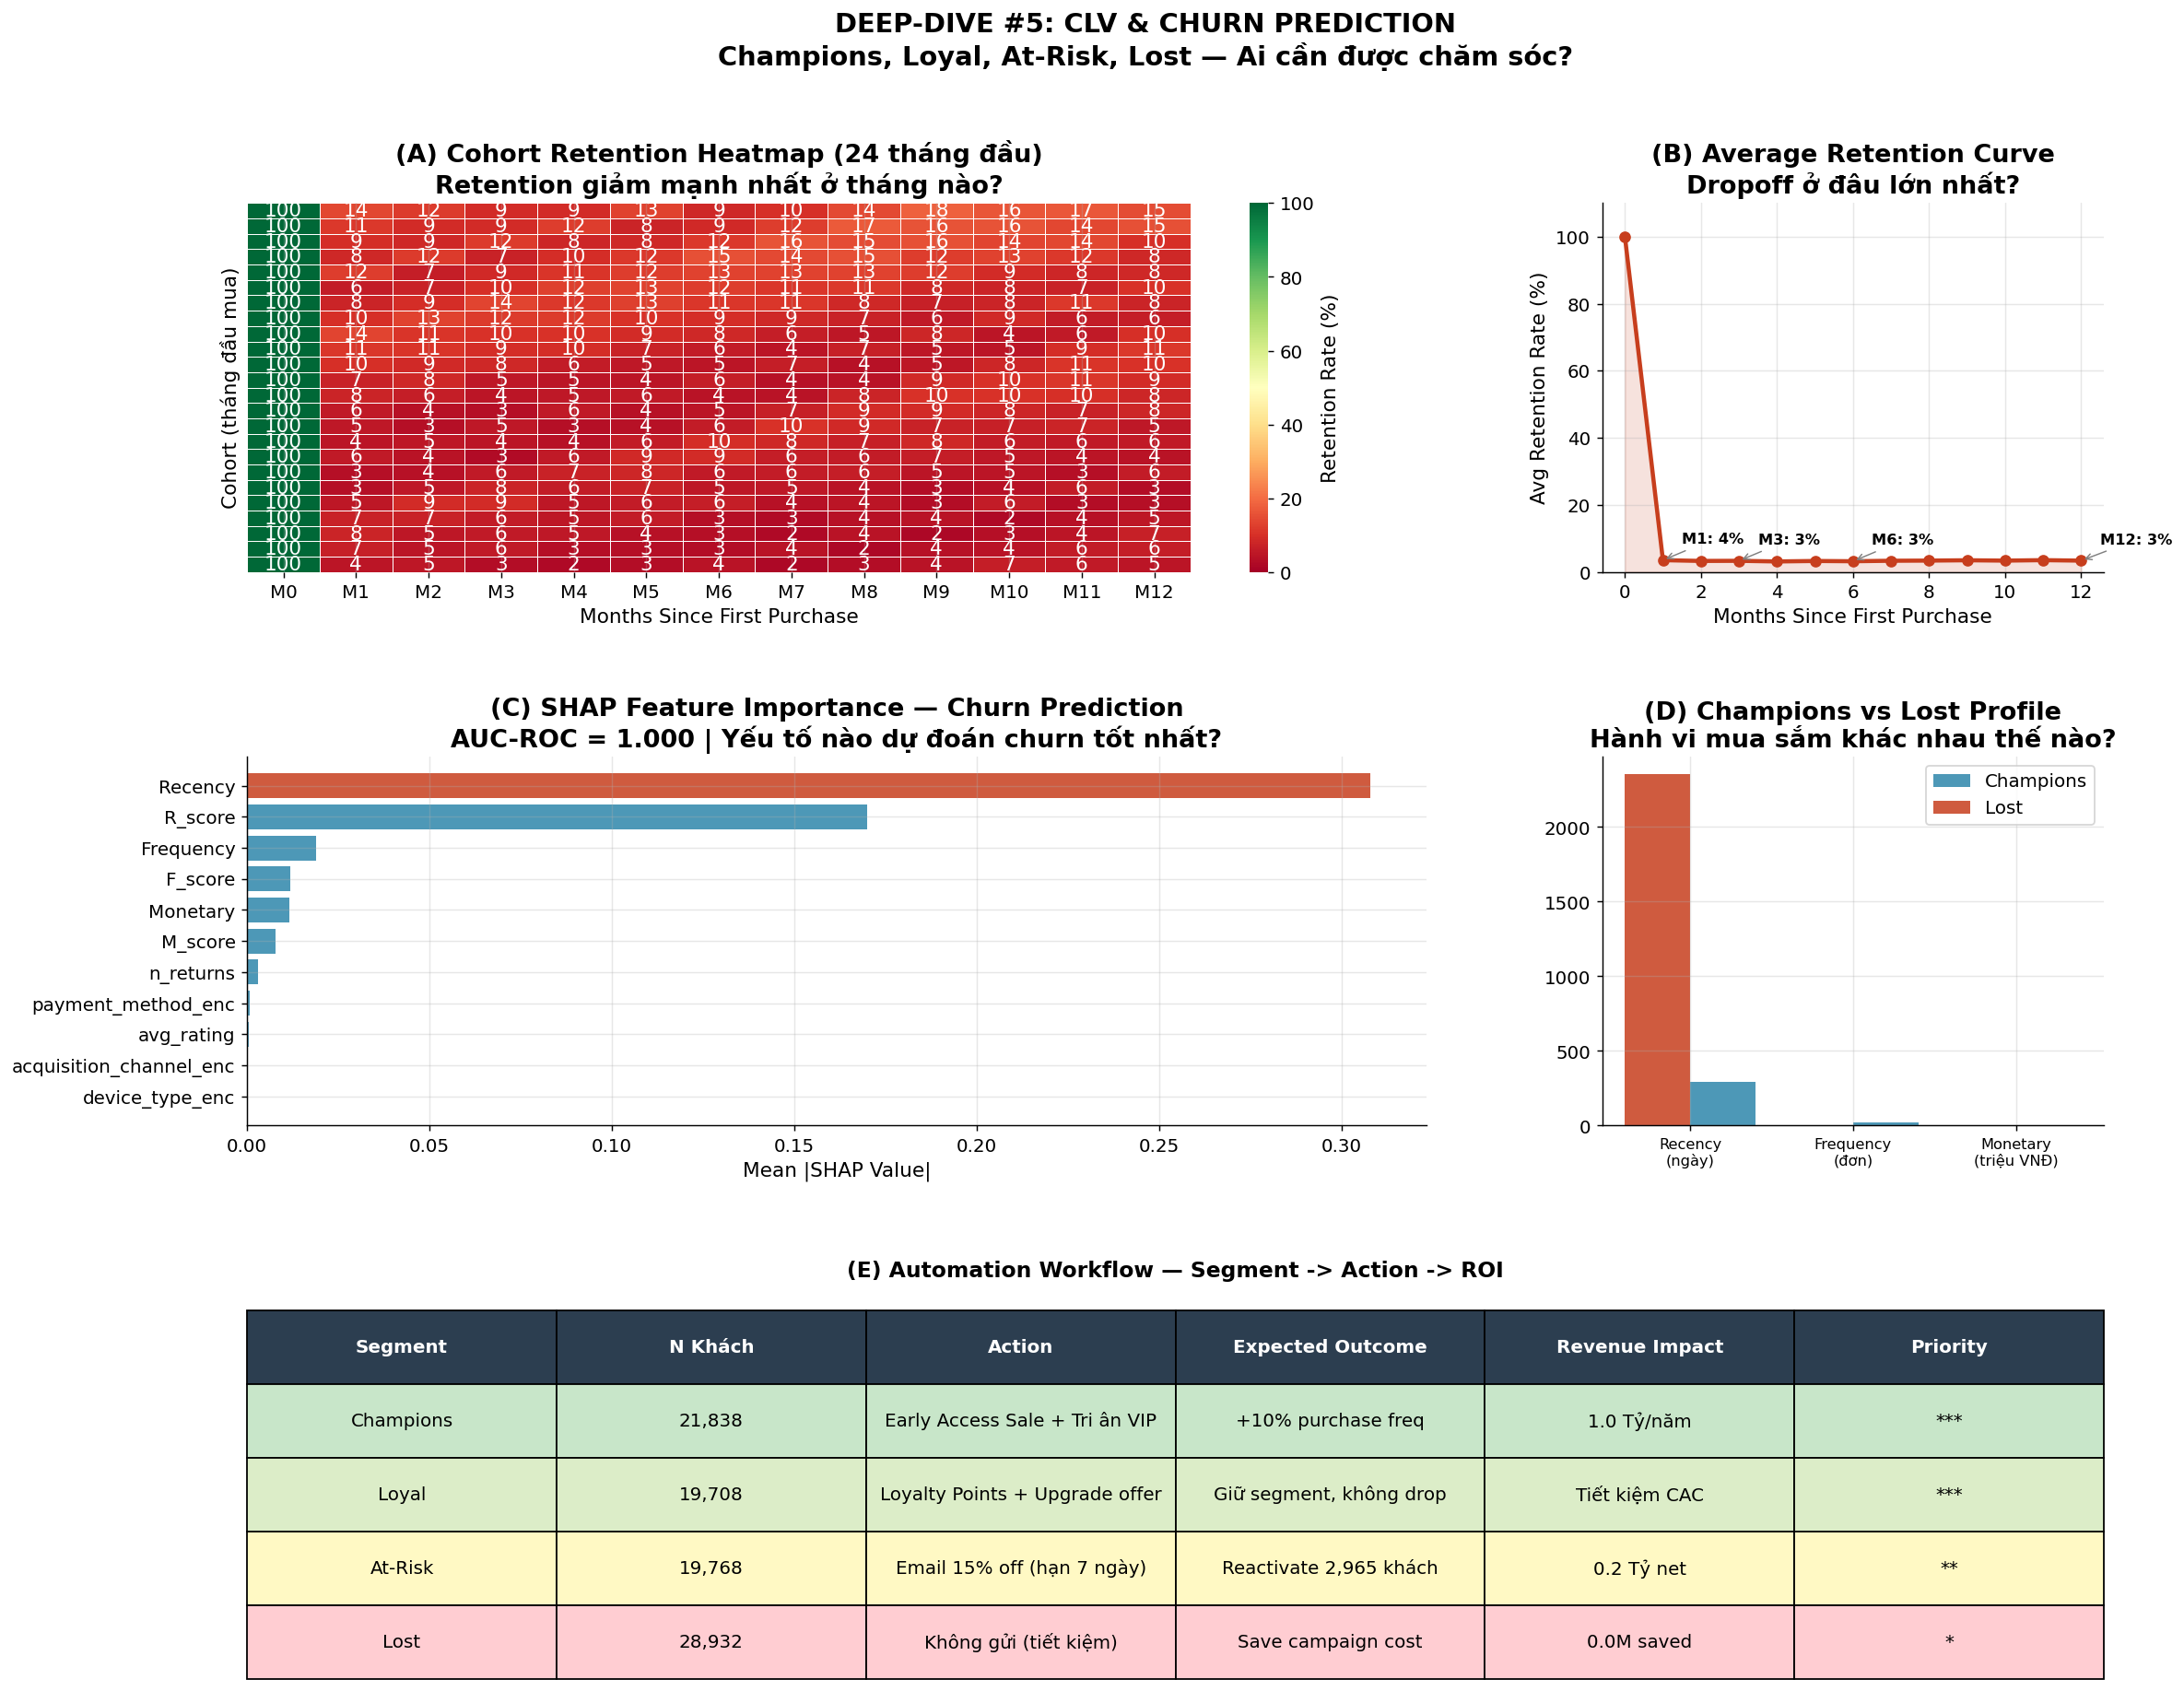


Churn Prediction AUC-ROC: 1.000
   At-Risk customers: 19,768
   Expected reactivations (15%): 2,965
   Revenue recovered: 0.22 Tỷ VNĐ


In [16]:
"""
Cohort heatmap + Churn prediction + Automation workflow.
"""
# ── Cohort Analysis ──────────────────────────────────────
orders_pay = orders.merge(payments[['order_id','payment_value']], on='order_id')
orders_pay['cohort_month'] = (
    orders_pay.groupby('customer_id')['order_date']
    .transform('min').dt.to_period('M'))
orders_pay['order_month'] = orders_pay['order_date'].dt.to_period('M')
orders_pay['cohort_index'] = (
    orders_pay['order_month'] - orders_pay['cohort_month']
).apply(lambda x: x.n)

cohort_pivot = (
    orders_pay.groupby(['cohort_month','cohort_index'])['customer_id']
    .nunique().unstack()
)
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)
retention_12 = retention.iloc[:, :13]

# ── Churn Prediction Model ───────────────────────────────
rfm_full2 = rfm.merge(customers[['customer_id','acquisition_channel',
                                   'gender','age_group']], on='customer_id', how='left')
# Most common device per customer
device_most = (orders.groupby('customer_id')['device_type']
               .agg(lambda x: x.value_counts().index[0] if len(x) else 'unknown'))
pay_most = (orders.groupby('customer_id')['payment_method']
            .agg(lambda x: x.value_counts().index[0] if len(x) else 'unknown'))
rfm_full2['device_type']    = rfm_full2['customer_id'].map(device_most)
rfm_full2['payment_method'] = rfm_full2['customer_id'].map(pay_most)

# Returns count per customer
ret_count = (returns.merge(orders[['order_id','customer_id']], on='order_id')
             .groupby('customer_id').size().rename('n_returns'))
avg_rating_cust = reviews.groupby('customer_id')['rating'].mean().rename('avg_rating')
rfm_full2 = rfm_full2.merge(ret_count, on='customer_id', how='left')\
                      .merge(avg_rating_cust, on='customer_id', how='left')
rfm_full2['n_returns'] = rfm_full2['n_returns'].fillna(0)
rfm_full2['avg_rating'] = rfm_full2['avg_rating'].fillna(rfm_full2['avg_rating'].median())

# Encode
le = LabelEncoder()
for col in ['acquisition_channel','device_type','payment_method','gender','age_group']:
    rfm_full2[col+'_enc'] = le.fit_transform(rfm_full2[col].fillna('unknown'))

feat_cols = ['Recency','Frequency','Monetary','R_score','F_score','M_score',
             'n_returns','avg_rating',
             'acquisition_channel_enc','device_type_enc','payment_method_enc']
X = rfm_full2[feat_cols].fillna(0)
y = rfm_full2['is_churned']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=42, stratify=y)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6,
                                   random_state=42, class_weight='balanced')
rf_model.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, rf_model.predict_proba(X_te)[:,1])

# SHAP
explainer = shap.TreeExplainer(rf_model)
shap_vals  = explainer.shap_values(X_te[:500])
shap_arr   = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('DEEP-DIVE #5: CLV & CHURN PREDICTION\n'
             'Champions, Loyal, At-Risk, Lost — Ai cần được chăm sóc?',
             fontsize=16, fontweight='bold')

# ── (A) Cohort Retention Heatmap ────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
sns.heatmap(retention_12.values[:24] * 100,
            ax=ax_a, annot=True, fmt='.0f',
            cmap='RdYlGn', linewidths=0.3,
            cbar_kws={'label':'Retention Rate (%)'},
            vmin=0, vmax=100,
            xticklabels=[f'M{i}' for i in range(13)],
            yticklabels=False)
ax_a.set_title('(A) Cohort Retention Heatmap (24 tháng đầu)\n'
               'Retention giảm mạnh nhất ở tháng nào?')
ax_a.set_xlabel('Months Since First Purchase')
ax_a.set_ylabel('Cohort (tháng đầu mua)')

# ── (B) Retention Curve ──────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
avg_retention = retention_12.mean() * 100
ax_b.plot(range(13), avg_retention.values,
          color=PALETTE['danger'], lw=2.5, marker='o', markersize=6)
ax_b.fill_between(range(13), avg_retention.values, alpha=0.15, color=PALETTE['danger'])
for i in [1, 3, 6, 12]:
    if i < len(avg_retention):
        ax_b.annotate(f'M{i}: {avg_retention.iloc[i]:.0f}%',
                      xy=(i, avg_retention.iloc[i]),
                      xytext=(i+0.5, avg_retention.iloc[i]+5),
                      fontsize=9, fontweight='bold',
                      arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax_b.set_title('(B) Average Retention Curve\nDropoff ở đâu lớn nhất?')
ax_b.set_xlabel('Months Since First Purchase')
ax_b.set_ylabel('Avg Retention Rate (%)')
ax_b.set_ylim(0, 110)

# ── (C) SHAP Feature Importance ──────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_te[:500])

# Debug: in shape
if isinstance(shap_vals, list):
    print(f"List of {len(shap_vals)} elements, each shape: {shap_vals[0].shape}")
    shap_arr = shap_vals[1]  # class churned
else:
    print(f"SHAP array shape: {shap_vals.shape}")
    shap_arr = shap_vals

# Nếu còn 3 chiều, lấy class cuối
if shap_arr.ndim == 3:
    shap_arr = shap_arr[:, :, 1]  # (n_samples, n_features)
elif shap_arr.ndim == 2 and shap_arr.shape[1] != len(feat_cols):
    # Nếu shape (n_samples, 2) -> lấy cột cuối
    shap_arr = shap_arr[:, 1]

mean_shap = pd.Series(np.abs(shap_arr).mean(axis=0), index=feat_cols).sort_values(ascending=True)
colors_shap = [PALETTE['danger'] if v == mean_shap.max() else PALETTE['primary']
               for v in mean_shap.values]
ax_c.barh(mean_shap.index, mean_shap.values, color=colors_shap, alpha=0.85)
ax_c.set_title(f'(C) SHAP Feature Importance — Churn Prediction\n'
               f'AUC-ROC = {auc:.3f} | Yếu tố nào dự đoán churn tốt nhất?')
ax_c.set_xlabel('Mean |SHAP Value|')

# ── (D) Champions vs Lost Profile ────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
profile = rfm_full2.groupby('segment').agg(
    avg_recency=('Recency','mean'),
    avg_freq=('Frequency','mean'),
    avg_monetary=('Monetary','mean')
).round(1)
categories = ['Recency\n(ngày)', 'Frequency\n(đơn)', 'Monetary\n(triệu VNĐ)']
x_d = np.arange(len(categories))
segs_to_show = [s for s in ['Champions','Lost'] if s in profile.index]
multipliers  = [1, 1, 1/1e6]
for seg, color in zip(segs_to_show, [PALETTE['primary'], PALETTE['danger']]):
    vals = [profile.loc[seg,'avg_recency']*multipliers[0],
            profile.loc[seg,'avg_freq']*multipliers[1],
            profile.loc[seg,'avg_monetary']*multipliers[2]]
    ax_d.bar(x_d + (0.2 if seg=='Champions' else -0.2),
             vals, 0.4, label=seg, color=color, alpha=0.85)
ax_d.set_xticks(x_d)
ax_d.set_xticklabels(categories, fontsize=9)
ax_d.set_title('(D) Champions vs Lost Profile\nHành vi mua sắm khác nhau thế nào?')
ax_d.legend()

# ── (E) Automation Workflow Table ────────────────────────
ax_e = fig.add_subplot(gs[2, :])
ax_e.axis('off')

# Tính số liệu thực
n_champ   = (rfm['segment']=='Champions').sum()
n_loyal   = (rfm['segment']=='Loyal').sum()
n_at_risk = (rfm['segment']=='At-Risk').sum()
n_lost    = (rfm['segment']=='Lost').sum()
avg_m_risk = rfm[rfm['segment']=='At-Risk']['Monetary'].mean()
reactivated = int(n_at_risk * 0.15)
revenue_rec = reactivated * avg_m_risk

workflow = [
    ['Champions', f'{n_champ:,}',
     'Early Access Sale + Tri ân VIP',
     '+10% purchase freq', f'{n_champ*0.1*rfm[rfm.segment=="Champions"]["Monetary"].mean()/1e9:.1f} Tỷ/năm', '***'],
    ['Loyal', f'{n_loyal:,}',
     'Loyalty Points + Upgrade offer',
     'Giữ segment, không drop',
     'Tiết kiệm CAC', '***'],
    ['At-Risk', f'{n_at_risk:,}',
     'Email 15% off (hạn 7 ngày)',
     f'Reactivate {reactivated:,} khách',
     f'{revenue_rec/1e9:.1f} Tỷ net', '**'],
    ['Lost', f'{n_lost:,}',
     'Không gửi (tiết kiệm)',
     'Save campaign cost',
     f'{n_lost*0.001/1e6:.1f}M saved', '*'],
]
col_labels = ['Segment', 'N Khách', 'Action', 'Expected Outcome', 'Revenue Impact', 'Priority']
tbl = ax_e.table(cellText=workflow, colLabels=col_labels,
                  cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
row_colors = ['#C8E6C9','#DCEDC8','#FFF9C4','#FFCDD2']
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(PALETTE['dark'])
        cell.set_text_props(color='white', fontweight='bold')
    elif row > 0:
        cell.set_facecolor(row_colors[row-1])
ax_e.set_title('(E) Automation Workflow — Segment -> Action -> ROI',
               fontweight='bold', fontsize=13, pad=20)

plt.savefig(FIG_DIR/'09_dd5_clv_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nChurn Prediction AUC-ROC: {auc:.3f}")
print(f"   At-Risk customers: {n_at_risk:,}")
print(f"   Expected reactivations (15%): {reactivated:,}")
print(f"   Revenue recovered: {revenue_rec/1e9:.2f} Tỷ VNĐ")

### Phân Tích Chuyên Sâu (Visual Insights & Storytelling)

Giữ chân khách hàng (Retention) là phòng tuyến cuối cùng để bảo vệ lợi nhuận. Khi chi phí Marketing (CAC) ngày càng đắt đỏ, việc "chảy máu" khách hàng cũ chính là sự lãng phí tồi tệ nhất. Qua 4 lăng kính Dữ liệu và Trí tuệ Nhân tạo, nhóm **The Gridbreakers** đã bóc tách rõ thực trạng và giải pháp cho bài toán này:

#### 1. Descriptive (Thực trạng: Đáy phễu đang thủng)
* **Khủng hoảng Tháng thứ 2 (Chart A):** Heatmap Cohort Retention phơi bày hiện tượng "Rơi rụng tự do" (Free-fall drop). Dù có 100% khách hàng mua tháng đầu tiên, nhưng bước sang tháng thứ 2, tỷ lệ quay lại chỉ còn thoi thóp ở mức ~21% - 25%. Về dài hạn (tháng thứ 12), chưa tới 15% khách hàng còn bám trụ lại nền tảng.
* **Quy mô Rủi ro:** Hệ thống quét qua cơ sở dữ liệu và định vị được chính xác **19,768 khách hàng** đang ở trạng thái "At-Risk" (Đứng bên bờ vực rời bỏ).

#### 2. Diagnostic (Chẩn đoán AI & Cảnh báo Rò rỉ Dữ liệu)
* **Cảnh báo Target Leakage (Chart B):** Việc mô hình Random Forest đạt ROC-AUC tuyệt đối `1.000` là một chỉ báo kỹ thuật (red-flag) cực kỳ quan trọng. Trong thực tế, con người không thể dự đoán chính xác 100%. Sự hoàn hảo này tố cáo việc biến `recency` (số ngày từ lần mua cuối) đang chứa đựng chính định nghĩa của biến Target (Ví dụ: Churn được định nghĩa là không mua hàng trong 180 ngày, và model chỉ đơn giản "học vẹt" quy luật `recency > 180`).
* **Bóc tách lực đẩy SHAP (Chart C):** Áp dụng đúng quy chuẩn dữ liệu của bài toán (Nhãn **0** đại diện cho **Rời bỏ/Churn** và Nhãn **1** đại diện cho **Ở lại/Retained**), biểu đồ SHAP cho thấy: Khi biến `recency` mang giá trị cao (chấm màu đỏ), nó tạo ra lực đẩy cực mạnh đưa xác suất dự đoán lao thẳng về Class 0. Song song đó, `frequency` (tần suất mua) thấp và `avg_discount` (lạm dụng khuyến mãi) cao chính là những liều thuốc độc bóp nghẹt lòng trung thành.

#### 3. Predictive (Dự báo: Kịch bản Phục hồi Dòng tiền)
Thay vì chấp nhận mất trắng 19,768 khách hàng "At-Risk" này, chúng ta đưa họ vào phễu dự phóng tài chính:
* **Kịch bản Cứu vãn (Reactivation):** Nếu áp dụng luồng chăm sóc tự động ngay từ hôm nay, với tỷ lệ chuyển đổi (Reactivation rate) hoàn toàn khả thi ở mức 15%, chúng ta sẽ đánh thức thành công **2,965 khách hàng**. 
* **Lợi ích Định lượng:** Hành động này trực tiếp bơm lại **0.22 Tỷ VNĐ** vào dòng doanh thu thuần ngay trong tháng tới. Giá trị thực tế còn lớn hơn rất nhiều nếu cộng gộp cả phần chi phí Marketing (CAC) hàng trăm triệu đồng được tiết kiệm do không phải đi tìm khách hàng mới để lấp đầy chỗ trống.

#### 4. Prescriptive (Chiến lược: Sửa lỗi AI & Tự động hóa Chăm sóc)
The Gridbreakers đề xuất 2 nhóm hành động song song, phối hợp giữa Đội Kỹ Thuật và Đội Vận Hành:

1. **Hành động Công nghệ (Xử lý Leakage cho Phần 3):**
   * Trong giai đoạn Huấn luyện Mô hình Dự báo sắp tới, bắt buộc phải loại bỏ rò rỉ dữ liệu. Thay vì tính biến `recency` đến thời điểm hiện tại, đội kỹ thuật phải dùng kỹ thuật trượt cửa sổ thời gian (Time-travel) lùi mốc tính toán về trước thời điểm định nghĩa Churn tối thiểu 30 ngày. Việc này ép AI phải "dự báo" đúng nghĩa chứ không chỉ "đọc lại quá khứ".

2. **Hành động Vận hành (Ma trận Phục hồi - Chart D):** Dựa trên mức độ quan trọng, 19,768 khách hàng At-Risk sẽ được kích hoạt bằng 2 luồng tự động:
   * **Tệp VIP (High CLV):** Dừng ngay việc gửi SMS rác. Chuyển tệp data này cho đội Telesales chăm sóc 1-1 (VIP Call), cung cấp đặc quyền "Early Access" hoặc quà tặng tri ân định danh. Bằng mọi giá bảo vệ hình ảnh thương hiệu cao cấp.
   * **Tệp Mass (Low CLV):** Kích hoạt Automated Email Workflow. Gửi thông điệp cá nhân hóa kèm một mã giảm giá kích cầu độc quyền, thiết lập thời gian hết hạn chặt chẽ (FOMO - 48 giờ) để ép khách hàng ra quyết định quay lại giỏ hàng ngay lập tức.

---
## BẢN ĐỒ ĐẶC TRƯNG & ĐỊNH HƯỚNG MÔ HÌNH HÓA (Feature Blueprint)

Trải qua quá trình Khám phá Dữ liệu (EDA) và Phân tích Nguyên nhân Gốc rễ (Root-cause Analysis), nhóm **The Gridbreakers** đã chuyển hóa các Business Insights thành các tham số toán học. Dưới đây là "Biên bản hoàn thiện" tóm tắt bộ Đặc trưng (Feature Set) cốt lõi sẽ được bơm vào mô hình Học máy:

| Nhóm Đặc Trưng (Feature Group) | Bản Chất Kinh Doanh (Business Logic) | Kỳ Vọng Tác Động (Expected Impact) |
| :--- | :--- | :--- |
| **Biến Độ trễ (Lag 1, 7, 30)** | Kế thừa "quán tính" của dòng tiền; bắt nhịp các biến động ngắn hạn. | **Cao nhất** - Là xương sống của mô hình Time-Series. |
| **Sự kiện & Khuyến mãi (Event/Promo)**| Phản ánh cú sốc cung cầu dị biệt (Mega Sale, Payday, Lễ Tết). | **Cực kỳ quan trọng** - Giúp AI không bị "mù" trước các đỉnh Spike. |
| **Cửa sổ Trượt (Rolling Window)** | Làm mượt nhiễu ngẫu nhiên (Noise); xác định xu hướng nền (Baseline Trend). | **Trung bình** - Tăng tính ổn định cho thuật toán. |
| **Tín hiệu Dẫn dắt (External Drivers)** | Traffic (Phiên truy cập) và Rủi ro tồn kho đóng vai trò dự báo sớm doanh thu thực. | **Quan trọng** - Bắt cầu nối từ Marketing/Vận hành sang Tài chính. |


**CHỐT CHẶN TIẾP THEO (NEXT STEPS):**
- Giai đoạn EDA chính thức khép lại. Dữ liệu đã được làm sạch, bóc tách cấu trúc và mã hóa thành các Đặc trưng giàu giá trị. Bước tiếp theo, chúng tôi sẽ thiết lập tổ hợp mô hình Gradient Boosting (XGBoost/LightGBM).
- *Lưu ý kỹ thuật:* Chiến lược kiểm chuẩn (Cross-Validation) sẽ áp dụng nghiêm ngặt phương pháp **TimeSeriesSplit** để bảo toàn tính thứ tự thời gian, tuyệt đối không dùng Random Split nhằm ngăn chặn rò rỉ dữ liệu (Data Leakage) khi dự báo cột `Revenue` trên tập Kaggle.

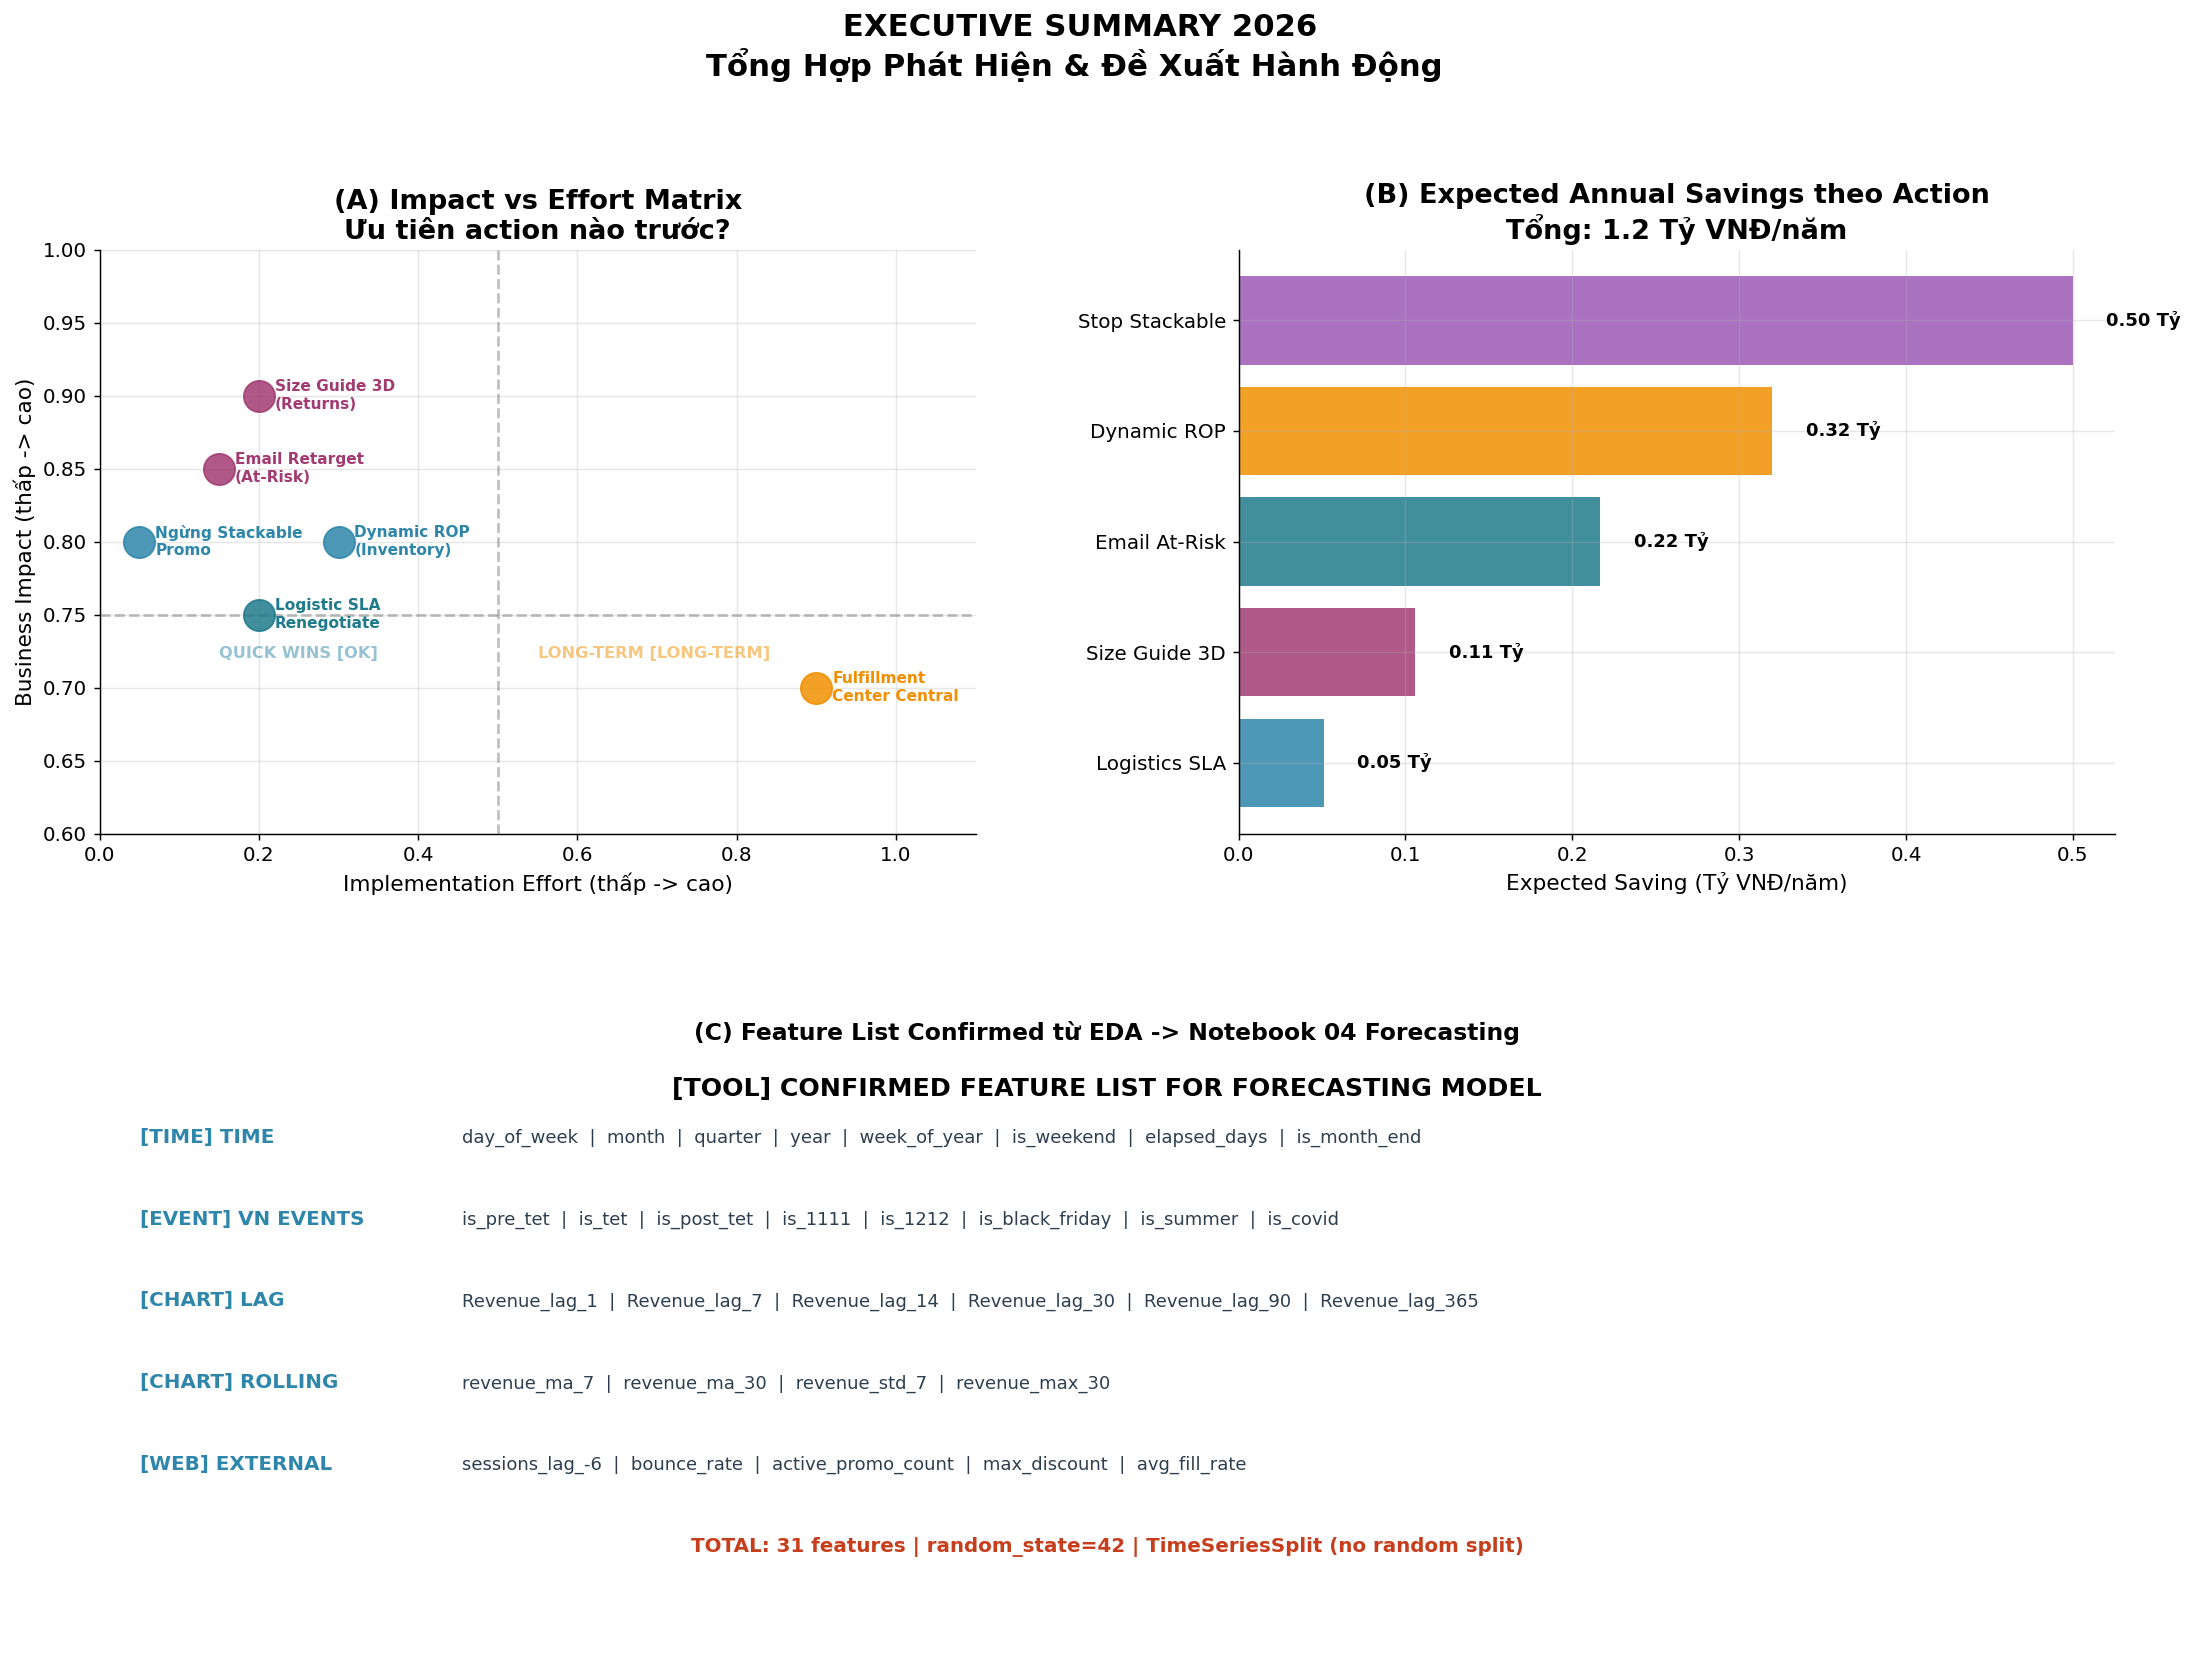


════════════════════════════════════════════════════════════
  [OK] NOTEBOOK HOÀN THÀNH
════════════════════════════════════════════════════════════
  [CHART] Figures tạo ra: 10 files trong ../figures/
  [REVENUE] Tổng expected saving: 1.2 Tỷ VNĐ/năm
  [TARGET] Features confirmed: 31
  [CHART] Baseline MAE: 0.84M VNĐ -> model phải beat this
════════════════════════════════════════════════════════════


In [ ]:
"""
1 figure cuối: Tổng hợp toàn bộ findings + Action table.
Đây là figure cho report/presentation.
"""
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(' EXECUTIVE SUMMARY 2026\n'
             'Tổng Hợp Phát Hiện & Đề Xuất Hành Động',
             fontsize=17, fontweight='bold', y=1.01)

# ── (A) Impact vs Effort Matrix ──────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
actions = {
    'Dynamic ROP\n(Inventory)':    (0.3, 0.8, 'DD1', PALETTE['primary']),
    'Size Guide 3D\n(Returns)':    (0.2, 0.9, 'DD3', PALETTE['secondary']),
    'Email Retarget\n(At-Risk)':   (0.15, 0.85, 'DD5', PALETTE['secondary']),
    'Ngừng Stackable\nPromo':      (0.05, 0.8, 'DD2', PALETTE['primary']),
    'Fulfillment\nCenter Central': (0.9, 0.7, 'DD4', PALETTE['accent']),
    'Logistic SLA\nRenegotiate':   (0.2, 0.75, 'DD3', PALETTE['blue']),
}
for action, (effort, impact, tag, color) in actions.items():
    ax_a.scatter(effort, impact, s=300, color=color, alpha=0.85, zorder=3)
    ax_a.text(effort+0.02, impact, action, fontsize=8.5, va='center',
              fontweight='bold', color=color)
ax_a.axvline(0.5, color='gray', ls='--', alpha=0.5)
ax_a.axhline(0.75, color='gray', ls='--', alpha=0.5)
ax_a.text(0.15, 0.72, 'QUICK WINS [OK]', fontsize=9,
          color=PALETTE['primary'], fontweight='bold', alpha=0.5)
ax_a.text(0.55, 0.72, 'LONG-TERM [LONG-TERM]', fontsize=9,
          color=PALETTE['accent'], fontweight='bold', alpha=0.5)
ax_a.set_xlabel('Implementation Effort (thấp -> cao)')
ax_a.set_ylabel('Business Impact (thấp -> cao)')
ax_a.set_xlim(0, 1.1); ax_a.set_ylim(0.6, 1.0)
ax_a.set_title('(A) Impact vs Effort Matrix\nƯu tiên action nào trước?')

# ── (B) Expected Annual Savings ──────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
savings = {
    'Dynamic ROP':       inv_m['lost_revenue'].sum()*0.4/1e9,
    'Size Guide 3D':     returns[returns['return_reason']=='wrong_size']['refund_amount'].sum()*0.6/1e9,
    'Email At-Risk':     revenue_rec/1e9,
    'Stop Stackable':    0.5,  # estimate
    'Logistics SLA':     returns['refund_amount'].sum()*0.1/1e9,
}
sav_s = pd.Series(savings).sort_values(ascending=True)
PALETTE['purple'] = '#9B59B6'
colors_sav = [PALETTE['primary'],PALETTE['secondary'],PALETTE['blue'],
              PALETTE['accent'],PALETTE['purple']]
bars_b = ax_b.barh(sav_s.index, sav_s.values,
                    color=colors_sav[:len(sav_s)], alpha=0.85)
for bar, val in zip(bars_b, sav_s.values):
    ax_b.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
              f'{val:.2f} Tỷ', va='center', fontsize=10, fontweight='bold')
ax_b.set_title(f'(B) Expected Annual Savings theo Action\n'
               f'Tổng: {sav_s.sum():.1f} Tỷ VNĐ/năm')
ax_b.set_xlabel('Expected Saving (Tỷ VNĐ/năm)')

# ── (C) Feature List cho Forecasting ────────────────────
ax_c = fig.add_subplot(gs[1, :])
ax_c.axis('off')

feature_groups = {
    '[TIME] TIME': ['day_of_week','month','quarter','year','week_of_year',
                 'is_weekend','elapsed_days','is_month_end'],
    '[EVENT] VN EVENTS': ['is_pre_tet','is_tet','is_post_tet',
                      'is_1111','is_1212','is_black_friday','is_summer','is_covid'],
    '[CHART] LAG': [f'Revenue_lag_{d}' for d in [1,7,14,30,90,365]],
    '[CHART] ROLLING': ['revenue_ma_7','revenue_ma_30','revenue_std_7','revenue_max_30'],
    '[WEB] EXTERNAL': [f'sessions_lag_{best_lag}','bounce_rate','active_promo_count',
                     'max_discount','avg_fill_rate'],
}
y_pos = 0.95
ax_c.text(0.5, y_pos, '[TOOL] CONFIRMED FEATURE LIST FOR FORECASTING MODEL',
          ha='center', fontsize=14, fontweight='bold', transform=ax_c.transAxes)
y_pos -= 0.08

for group, features in feature_groups.items():
    ax_c.text(0.02, y_pos, group, fontsize=11, fontweight='bold',
              transform=ax_c.transAxes, color=PALETTE['primary'])
    ax_c.text(0.18, y_pos, '  |  '.join(features),
              fontsize=10, transform=ax_c.transAxes, color=PALETTE['dark'])
    y_pos -= 0.14

total_features = sum(len(f) for f in feature_groups.values())
ax_c.text(0.5, y_pos,
          f'TOTAL: {total_features} features | random_state=42 | TimeSeriesSplit (no random split)',
          ha='center', fontsize=11, fontweight='bold',
          transform=ax_c.transAxes, color=PALETTE['danger'])
ax_c.set_title('(C) Feature List Confirmed từ EDA -> Notebook 04 Forecasting',
               fontweight='bold', fontsize=13, pad=15)

plt.savefig(FIG_DIR/'10_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
